# Accident Severity — Environment Setup




In [181]:
%pip install -U pip wheel setuptools
%pip install -U numpy pandas matplotlib seaborn scikit-learn
%pip install -U plotly ipywidgets
%pip install -U imbalanced-learn
%pip install xgboost==3.0.3
%pip install -U shap



Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [182]:


import os, time, math, warnings, random
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn import metrics
from sklearn.metrics import f1_score

from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE

from xgboost import XGBClassifier




In [183]:
import shap

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

import sys
print("Python:", sys.version.split()[0],
      "| pandas:", pd.__version__,
      "| numpy:", np.__version__,
      "| sklearn:", __import__("sklearn").__version__,
      "| imblearn:", __import__("imblearn").__version__,
      "| xgboost:", __import__("xgboost").__version__,
      "| shap:", shap.__version__)

Python: 3.10.19 | pandas: 2.3.3 | numpy: 2.2.6 | sklearn: 1.7.2 | imblearn: 0.14.0 | xgboost: 3.0.3 | shap: 0.49.1


## Fetching the dataset from Kaggle

We’ll pull the dataset via `kagglehub`, locate the main CSV inside the download, and load it with a few common “NA” tokens treated as missing.


In [184]:
from pathlib import Path
!pip install --quiet kagglehub
import kagglehub


In [185]:
root = Path(kagglehub.dataset_download("saurabhshahane/road-traffic-accidents"))
print("dataset directory:", root)

dataset directory: C:\Users\Sakif\.cache\kagglehub\datasets\saurabhshahane\road-traffic-accidents\versions\3


In [186]:
candidates = list(root.rglob("RTA_Dataset.csv"))
if not candidates:
    candidates = [p for p in root.rglob("*.csv") if "rta" in p.name.lower()]
if not candidates:
    raise FileNotFoundError("Could not find in download.")

In [187]:
csv_path = candidates[0]
print("Using file:", csv_path.relative_to(root))

Using file: RTA Dataset.csv


In [188]:
data = pd.read_csv(csv_path, na_values=["na", "NaN", "?", "-"], low_memory=False)
print("Shape:", data.shape)
display(data.head())

Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3.0,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [189]:
print(data.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


## Project Objective

This dataset records over 12,000 road traffic accidents that occurred in Addis Ababa between 2017 and 2020.  
It includes 31 descriptive variables about each incident — such as driver profile, vehicle type, and road conditions — along with a target column **`Accident_severity`** that can take one of three labels: **Slight**, **Serious**, or **Fatal**.

The main goal is to build machine learning models capable of predicting the level of accident severity using the provided attributes.

---

## Evaluation Metric

Model performance will be assessed using **Precision**, **Recall**, and their harmonic mean, the **F1-score**.  

- **Precision** focuses on how many of the predicted positive cases are actually positive.  
- **Recall** captures how many of the real positive cases are correctly identified.

\[
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}
\]

The **F1-score** balances these two by taking their harmonic mean:

\[
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
\]

Because our target variable has three severity levels, we treat each one as the “positive” class in turn and average the resulting F1-scores.  
This unweighted average — the **macro F1-score** — gives an overall picture of how well the model performs across all categories.


## Basic data scan

Quick pass to confirm the shape, column names and types, look for duplicates, and gauge missingness.  
We’ll also print compact summaries for numeric and categorical fields to spot any obvious quirks early.


In [190]:
import io

In [191]:
print(f"Shape of the data: {data.shape}")
print("\nColumns:")
print(pd.Index(data.columns))

print(f"\nTotal number of columns: {len(data.columns)}")


print("\nDtypes:")
print(data.dtypes)

Shape of the data: (12316, 32)

Columns:
Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle',
       'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement',
       'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident',
       'Accident_severity'],
      dtype='object')

Total number of columns: 32

Dtypes:
Time                            object
Day_of_week                     object
Age_band_of_driver              object
Sex_of_driver                   object
Educational_level        

In [192]:
dtype_counts = data.dtypes.value_counts()
print("\nColumn counts by dtype:")
for dt, cnt in dtype_counts.items():
    print(f"  {dt}: {cnt}")



Column counts by dtype:
  object: 29
  int64: 2
  float64: 1


In [193]:
dup_count = data.duplicated().sum()
print(f"\nNumber of duplicate rows: {dup_count}")


Number of duplicate rows: 0


In [194]:
na_per_col = data.isna().sum()
total_na = int(na_per_col.sum())
cols_with_na = int((na_per_col > 0).sum())
cols_without_na = len(data.columns) - cols_with_na

print("\nMissing values per column (descending):")
print(na_per_col.sort_values(ascending=False))

print(f"\nTotal number of missing values: {total_na}")
print(f"Number of columns with missing values: {cols_with_na}")
print(f"Number of columns without missing values: {cols_without_na}")


Missing values per column (descending):
Sex_of_casualty                4443
Age_band_of_casualty           4443
Casualty_severity              4443
Casualty_class                 4443
Defect_of_vehicle              4427
Service_year_of_vehicle        3928
Work_of_casuality              3198
Fitness_of_casuality           2635
Type_of_vehicle                 950
Types_of_Junction               887
Driving_experience              829
Educational_level               741
Vehicle_driver_relation         579
Owner_of_vehicle                482
Lanes_or_Medians                385
Vehicle_movement                308
Area_accident_occured           239
Road_surface_type               172
Type_of_collision               155
Road_allignment                 142
Sex_of_driver                     0
Age_band_of_driver                0
Day_of_week                       0
Time                              0
Number_of_vehicles_involved       0
Number_of_casualties              0
Light_conditions       

In [195]:
if cols_with_na:
    cols_na_list = na_per_col[na_per_col > 0].index.tolist()
    print("Columns with missing values:", ", ".join(cols_na_list))

Columns with missing values: Educational_level, Vehicle_driver_relation, Driving_experience, Type_of_vehicle, Owner_of_vehicle, Service_year_of_vehicle, Defect_of_vehicle, Area_accident_occured, Lanes_or_Medians, Road_allignment, Types_of_Junction, Road_surface_type, Type_of_collision, Vehicle_movement, Casualty_class, Sex_of_casualty, Age_band_of_casualty, Casualty_severity, Work_of_casuality, Fitness_of_casuality


In [196]:
buf = io.StringIO()
data.info(buf=buf)
print("\nSummary of the data:")
print(buf.getvalue())


Summary of the data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         12316 non-null  object 
 1   Day_of_week                  12316 non-null  object 
 2   Age_band_of_driver           12316 non-null  object 
 3   Sex_of_driver                12316 non-null  object 
 4   Educational_level            11575 non-null  object 
 5   Vehicle_driver_relation      11737 non-null  object 
 6   Driving_experience           11487 non-null  object 
 7   Type_of_vehicle              11366 non-null  object 
 8   Owner_of_vehicle             11834 non-null  object 
 9   Service_year_of_vehicle      8388 non-null   object 
 10  Defect_of_vehicle            7889 non-null   object 
 11  Area_accident_occured        12077 non-null  object 
 12  Lanes_or_Medians             11931 non-null  object 

In [197]:
print("Numeric summary:")
display(data.describe())

Numeric summary:


,Number_of_vehicles_involved,Number_of_casualties,Casualty_severity
count,12316.000000,12316.000000,7873.000000
mean,2.040679,1.548149,2.895466
std,0.688790,1.007179,0.316583
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,3.000000
50%,2.000000,1.000000,3.000000
75%,2.000000,2.000000,3.000000
max,7.000000,8.000000,3.000000


In [198]:
print("Categorical summary (first few rows of describe):")
display(data.describe(include='object').head(4).T)

Categorical summary (first few rows of describe):


,count,unique,top,freq
Time,12316,1074,15:30:00,120
Day_of_week,12316,7,Friday,2041
Age_band_of_driver,12316,5,18-30,4271
Sex_of_driver,12316,3,Male,11437
Educational_level,11575,7,Junior high school,7619
Vehicle_driver_relation,11737,4,Employee,9627
Driving_experience,11487,7,5-10yr,3363
Type_of_vehicle,11366,17,Automobile,3205
Owner_of_vehicle,11834,4,Owner,10459
Service_year_of_vehicle,8388,6,Unknown,2883


## Quick checks before plotting

Two notes from the first scan:
- The four casualty-related columns and `Casualty_severity` have many missing entries once we treat the string `"na"` as actual NA. We’ll keep that in mind so plots don’t mislead.
- The target we care about is **`Accident_severity`** (Slight/Serious/Fatal). `Casualty_severity` is a different field and happens to be numeric in this file.

Let’s first look at the severity class balance and a simple view of missingness.


In [199]:
target = "Accident_severity"
order = ["Slight Injury", "Serious Injury", "Fatal injury"]  # expected labels; will auto-drop any missing
vc = data[target].value_counts().reindex(order)


In [200]:
print("Accident_severity distribution:")
display(vc.to_frame("count").assign(pct=lambda d: (100*d["count"]/d["count"].sum()).round(2)))


Accident_severity distribution:


,count,pct
Accident_severity,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28


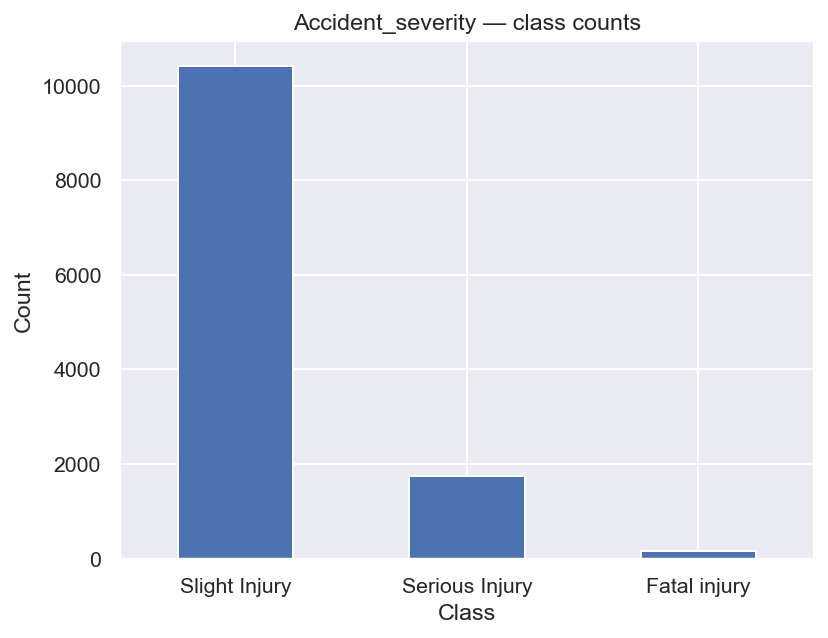

In [201]:
vc.dropna().plot(kind="bar")
plt.title("Accident_severity — class counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


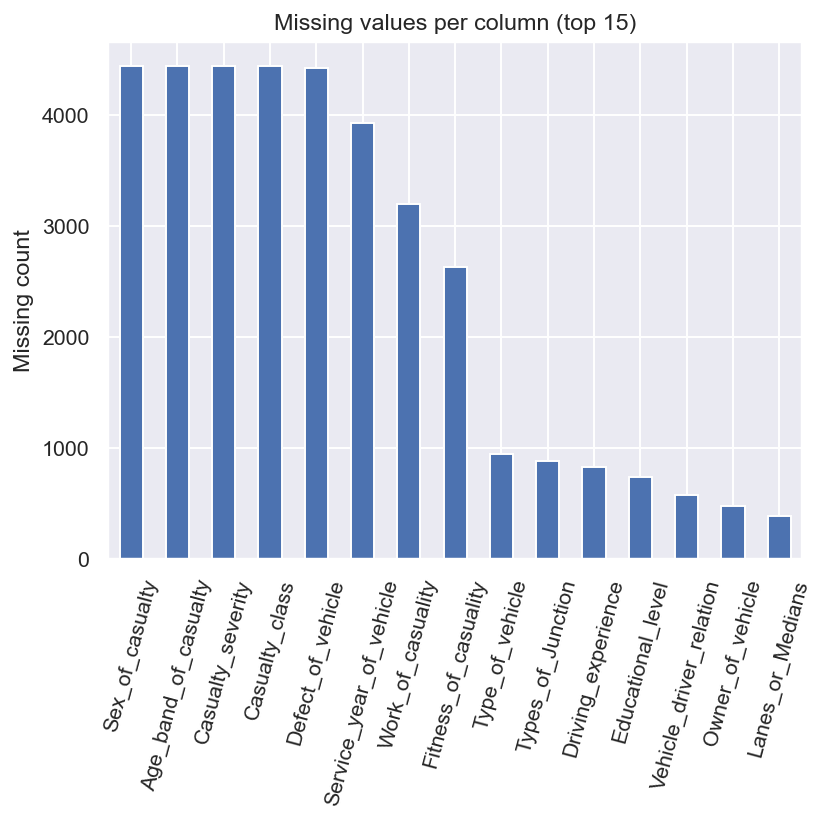

In [202]:
na_counts = data.isna().sum().sort_values(ascending=False)
na_counts = na_counts[na_counts > 0].head(15)
if not na_counts.empty:
    na_counts.plot(kind="bar")
    plt.title("Missing values per column (top 15)")
    plt.ylabel("Missing count")
    plt.xticks(rotation=75)
    plt.show()

## Target: `Accident_severity`

There are three labels: **Slight Injury**, **Serious Injury**, and **Fatal injury**.  
Counts in our file: 10,415 / 1,743 / 158, which corresponds to **84.56%**, **14.15%**, and **1.28%**.  
That’s a strong class imbalance, so we’ll keep stratified splits and class-imbalance handling in mind for modeling.


In [203]:
target = "Accident_severity"
order = ["Slight Injury", "Serious Injury", "Fatal injury"] 

In [204]:
vc = (
    data[target]
    .dropna()
    .astype(pd.CategoricalDtype(categories=order, ordered=True))
    .value_counts()
    .reindex(order)
)

In [205]:
summary = pd.DataFrame({"count": vc, "pct": (vc / vc.sum() * 100).round(2)})
display(summary)

,count,pct
Accident_severity,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28


In [206]:
def annotate_bar(ax, counts):
    total = counts.sum()
    for p, c in zip(ax.patches, counts):
        ax.annotate(f"{int(c)}\n({c/total*100:.2f}%)",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=11)


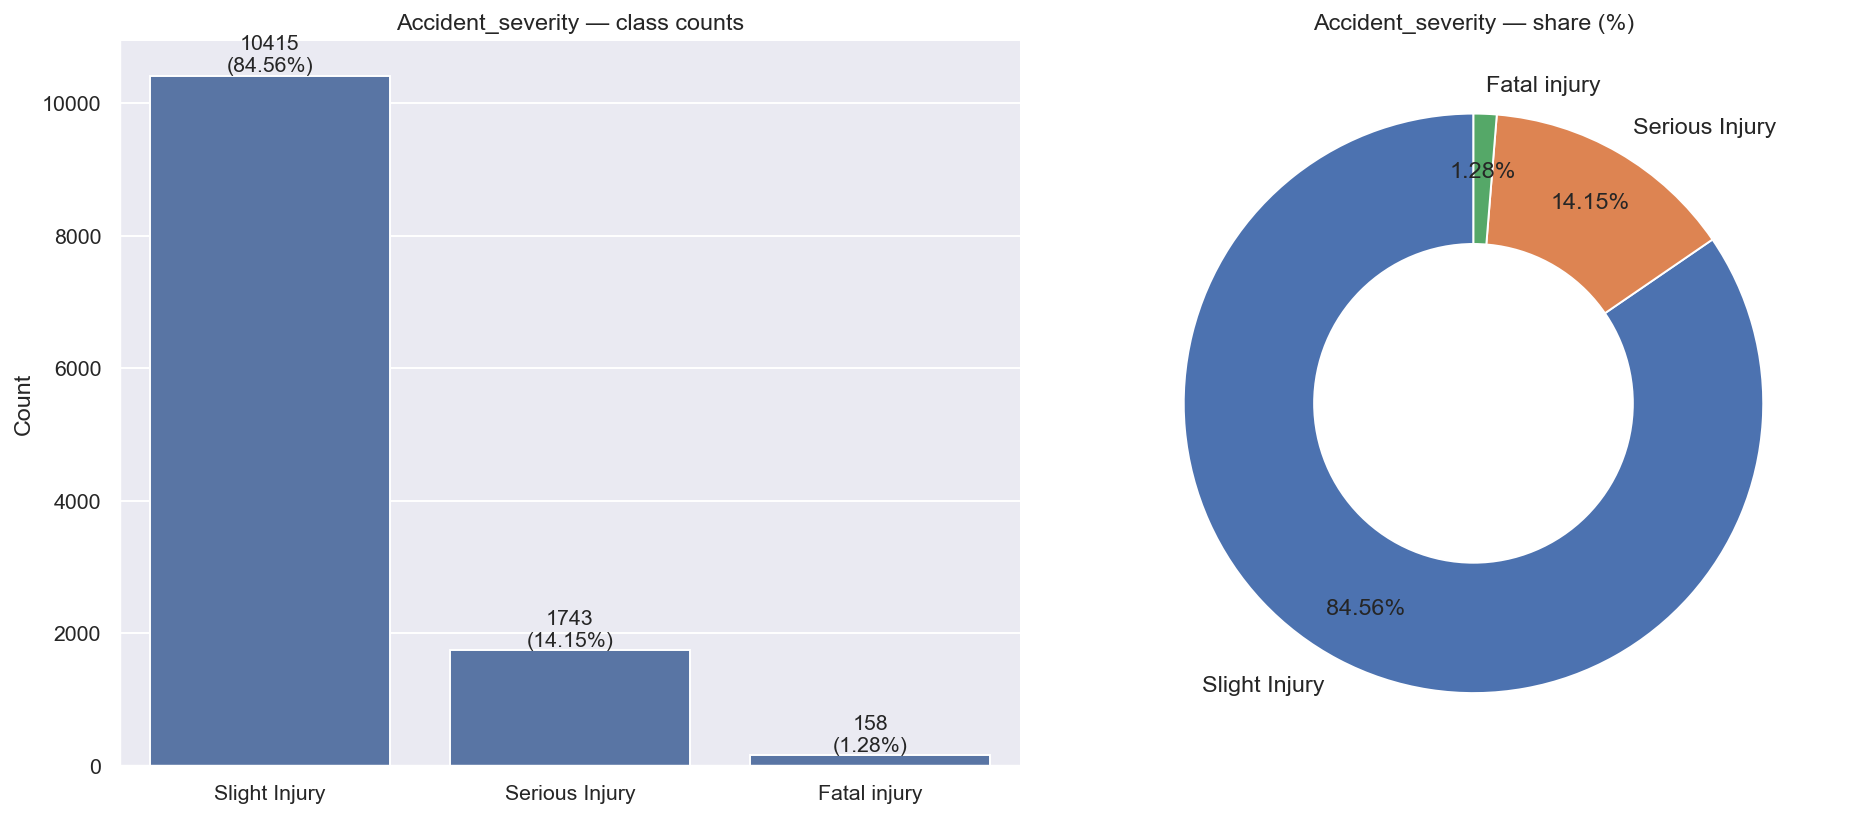

In [207]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


sns.countplot(x=data[target], order=order, ax=ax1)
ax1.set_xlabel("")
ax1.set_ylabel("Count")
ax1.set_title("Accident_severity — class counts")
annotate_bar(ax1, vc.fillna(0).values)
sns.despine(top=True, right=True, ax=ax1)

counts = vc.fillna(0).values
labels = [lbl for lbl, c in zip(order, counts) if c > 0]
counts = counts[counts > 0]

wedges, texts, autotexts = ax2.pie(
    counts,
    labels=labels,
    autopct="%1.2f%%",
    pctdistance=0.8,
    startangle=90,
    textprops={"fontsize": 12},
)

centre_circle = plt.Circle((0, 0), 0.55, fc="white")
ax2.add_artist(centre_circle)
ax2.set_title("Accident_severity — share (%)")

plt.tight_layout()
plt.show()

## Time → Day/Night + faceted counts

We’ll convert the `Time` strings into a simple **Day/Night** flag (Day = 06:00–18:00, inclusive).  
Then, for each remaining feature, we’ll plot its frequency split by the three severity classes.  
Missing entries are shown explicitly as “Missing” so we can see how much data we actually have per field.


In [208]:
t = pd.to_datetime(data["Time"], format="%H:%M:%S", errors="coerce")
data["Time"] = np.where(t.dt.hour.between(6, 18, inclusive="both"), "Day", "Night")
print(data["Time"].value_counts())

Time
Day      9317
Night    2999
Name: count, dtype: int64


In [209]:
TARGET = "Accident_severity"
TARGET_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]


In [210]:
def facet_countplot(df, feature, rotate_threshold=6):
    tmp = df[[feature, TARGET]].copy()
    tmp[feature] = tmp[feature].astype("object").fillna("Missing")

    g = sns.catplot(
        data=tmp,
        x=feature,
        col=TARGET,
        col_order=TARGET_ORDER,
        kind="count",
        sharey=False,
        height=3.5,
        aspect=1.2,
    )

    n_unique = tmp[feature].nunique(dropna=False)
    if n_unique >= rotate_threshold:
        g.set_xticklabels(rotation=90)

    g.set_xlabels("")
    g.set_ylabels("Count")
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.82)
    g.fig.suptitle(f"Frequency distribution of {feature} by target class")
    plt.show()

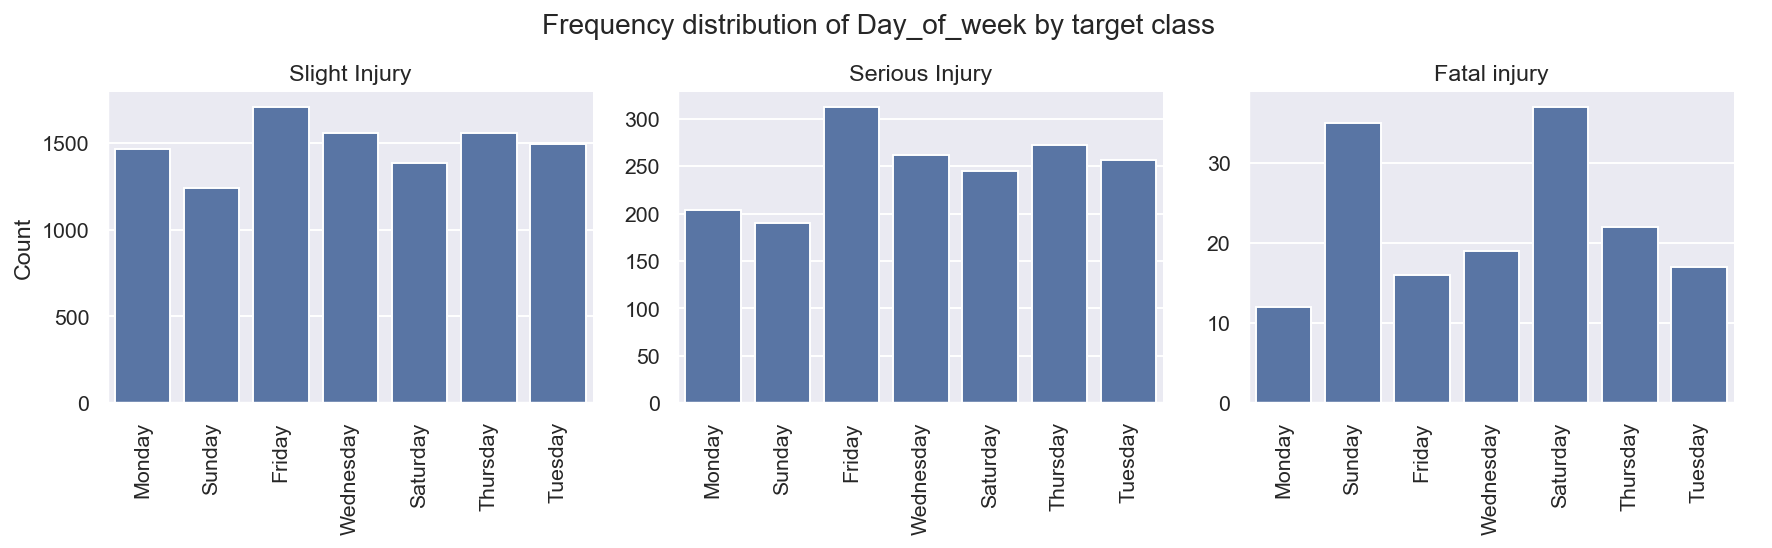

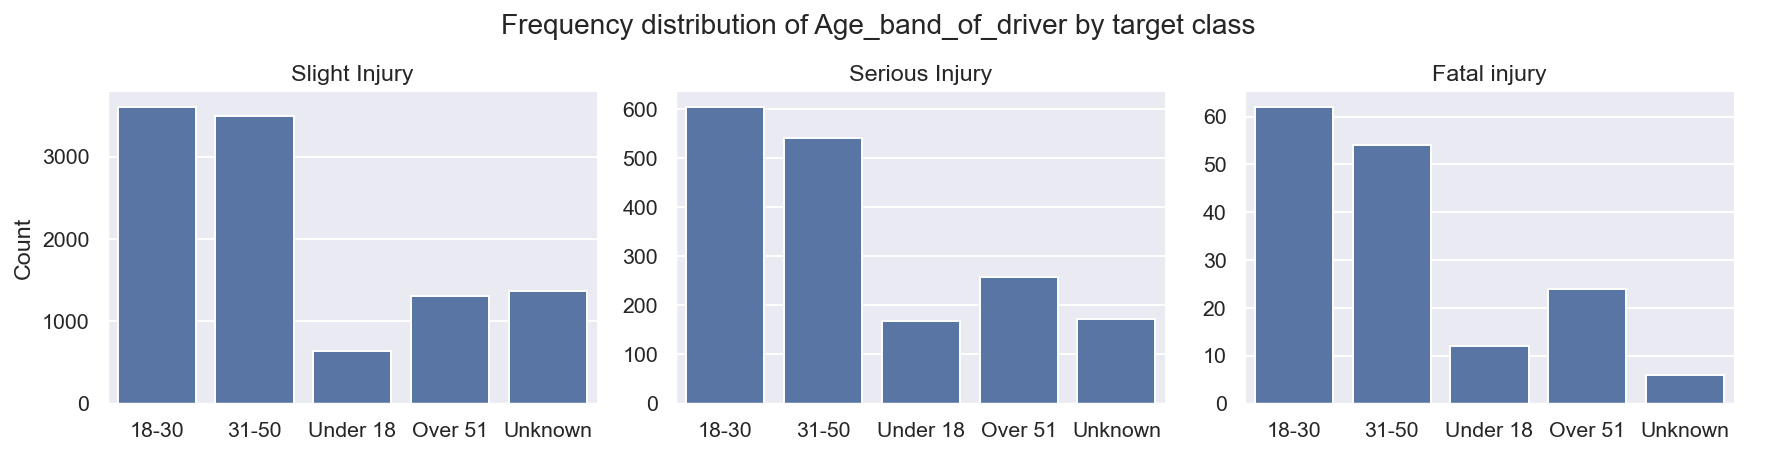

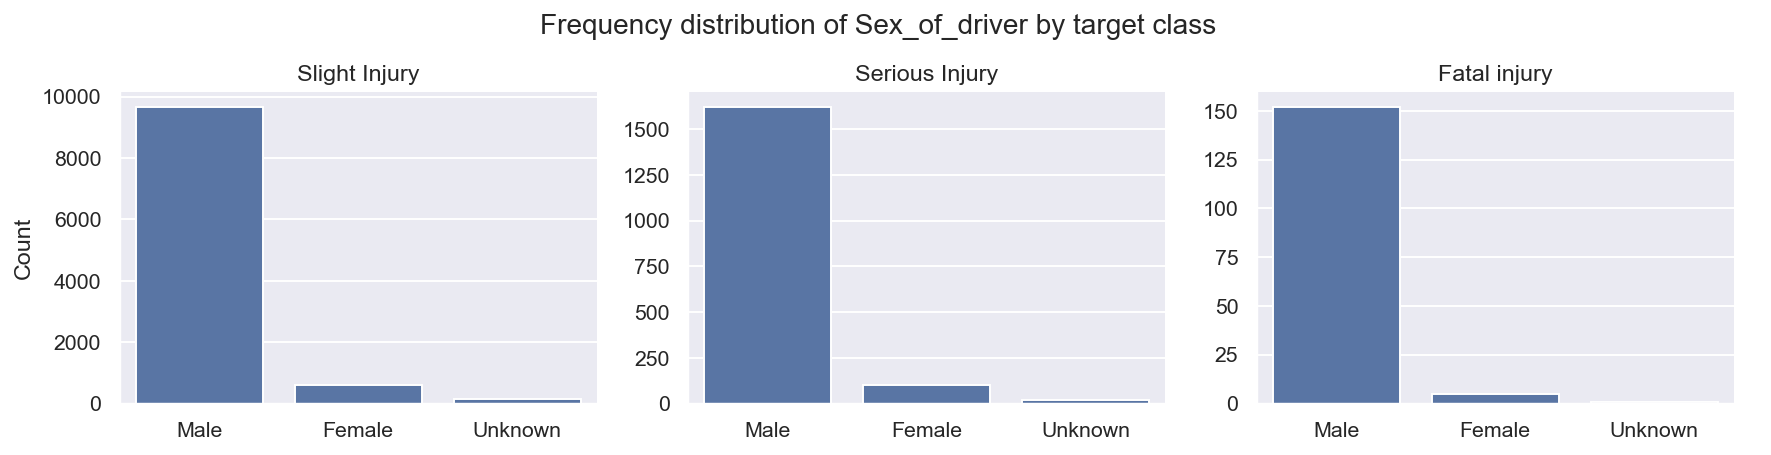

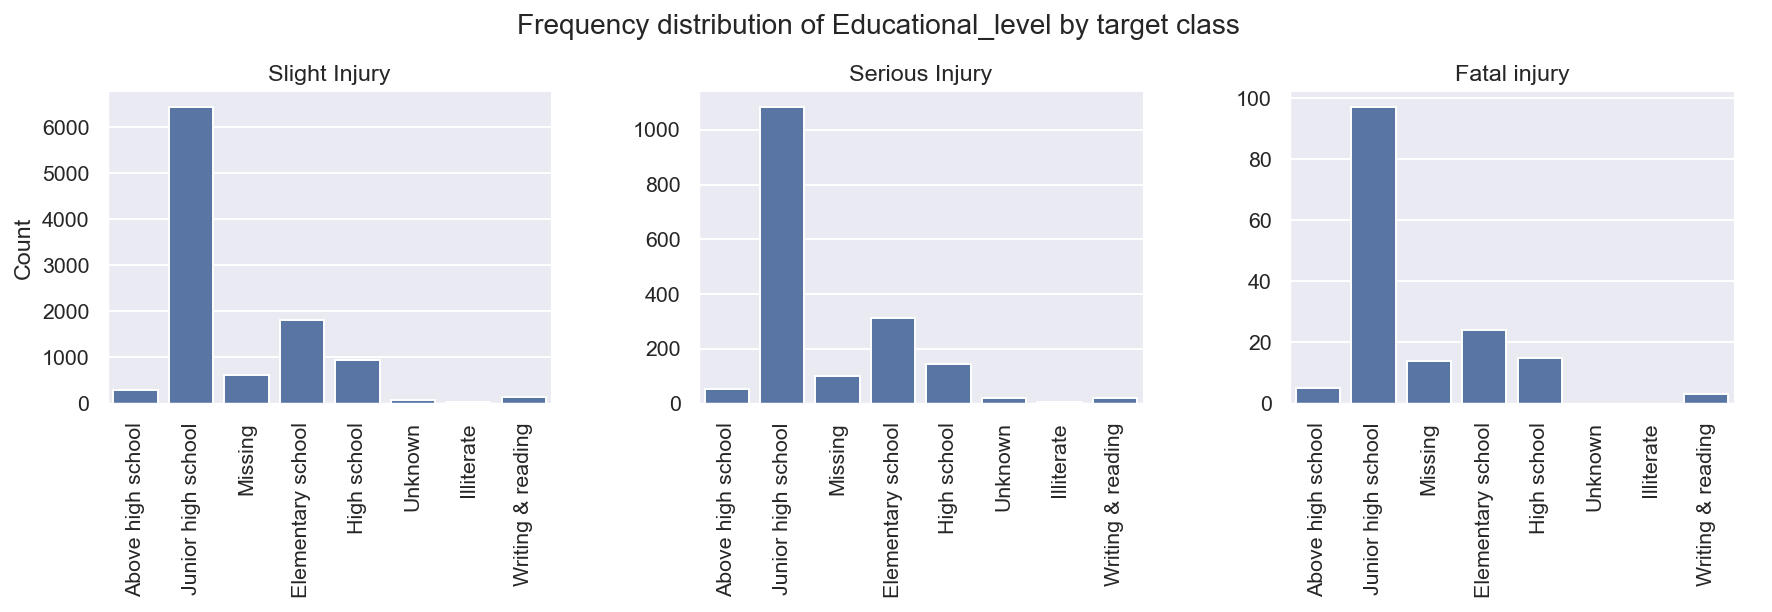

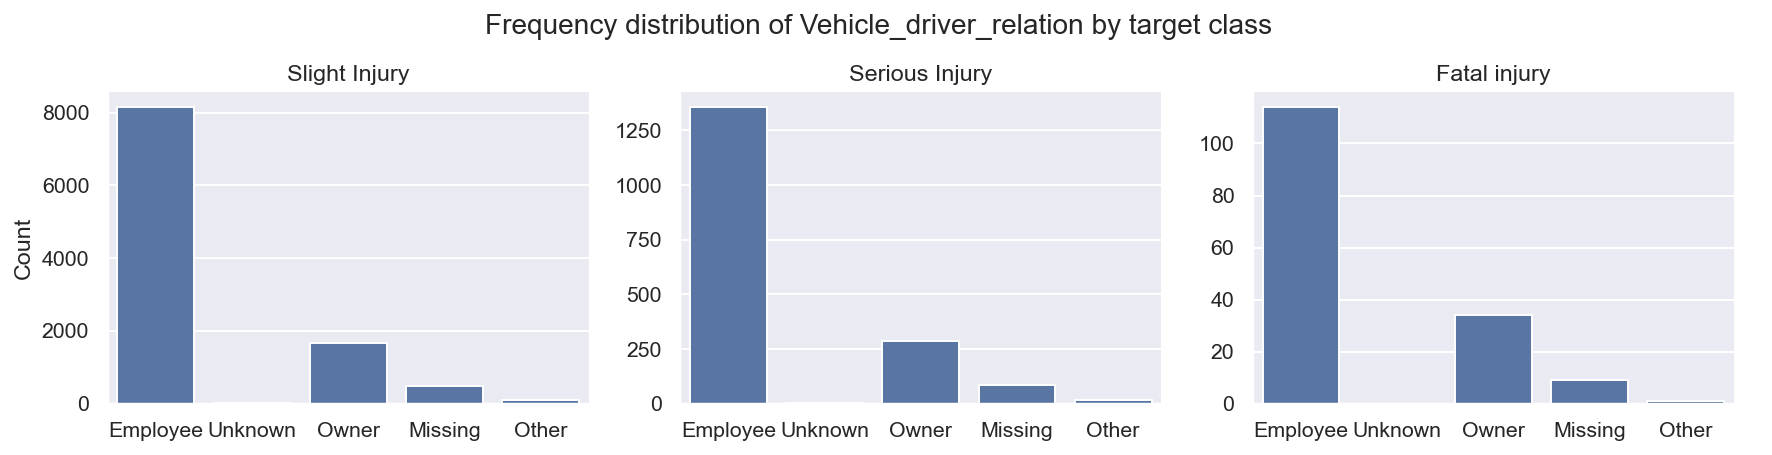

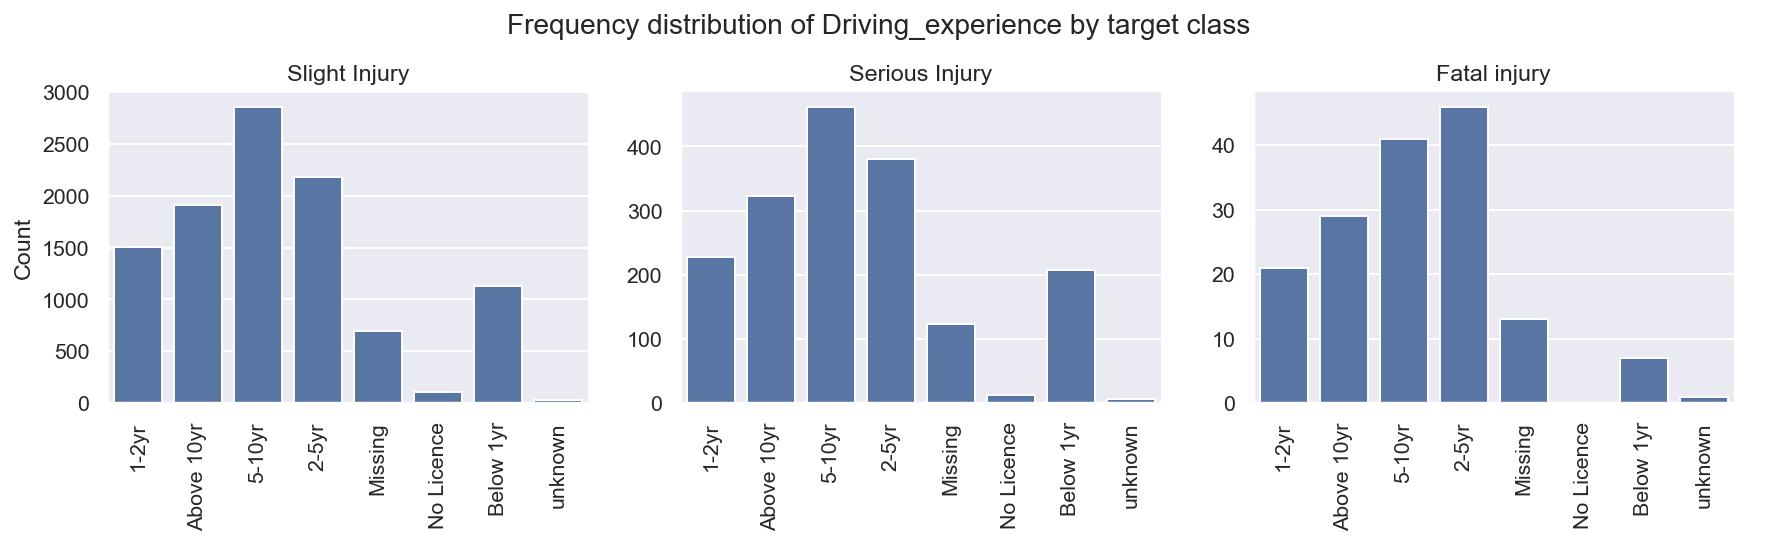

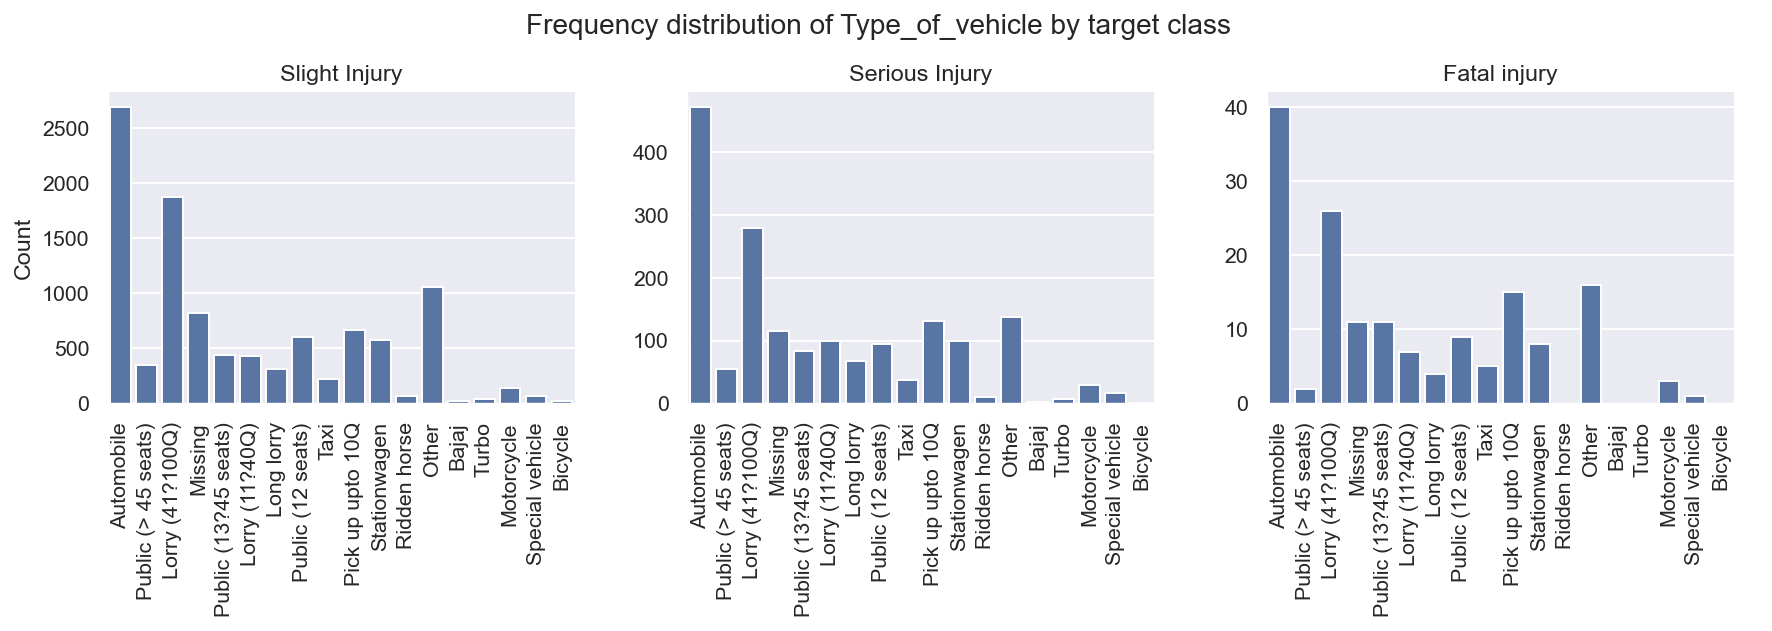

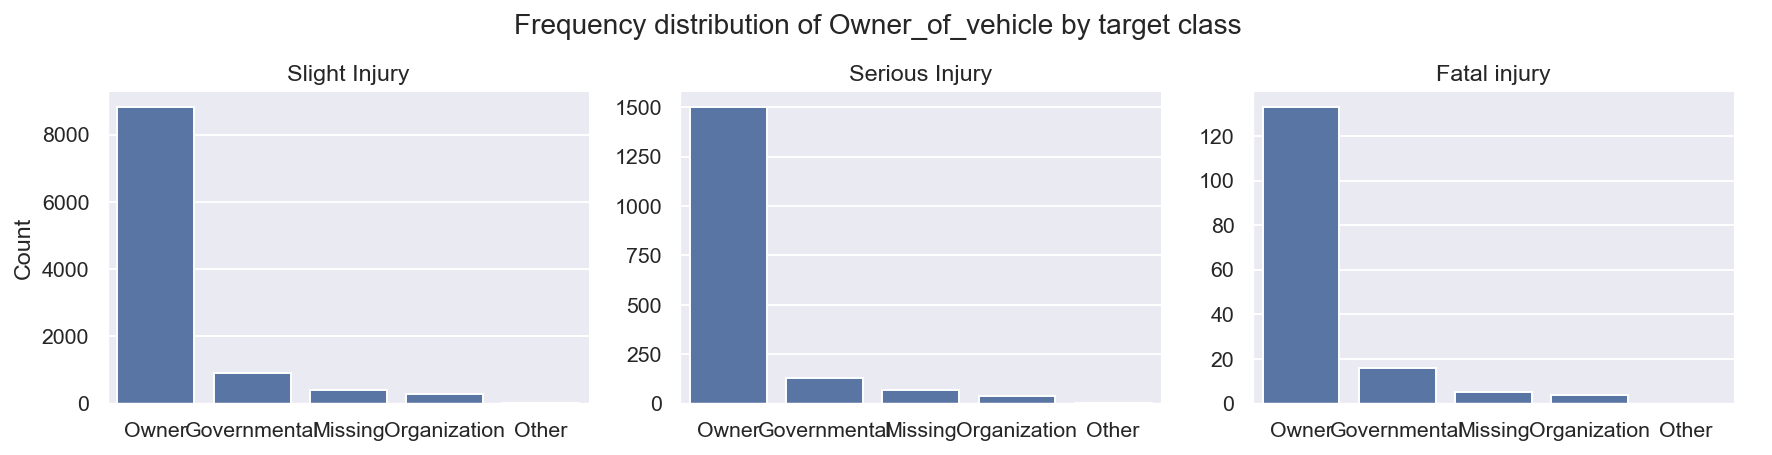

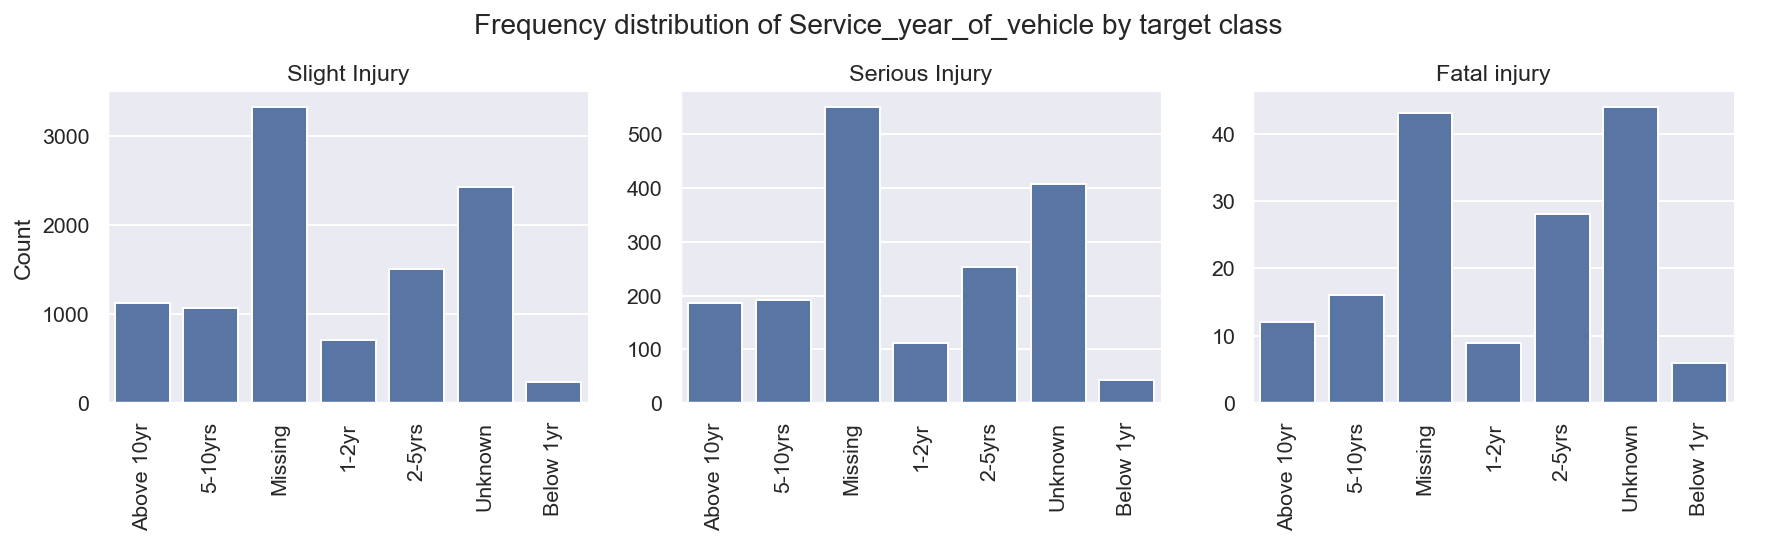

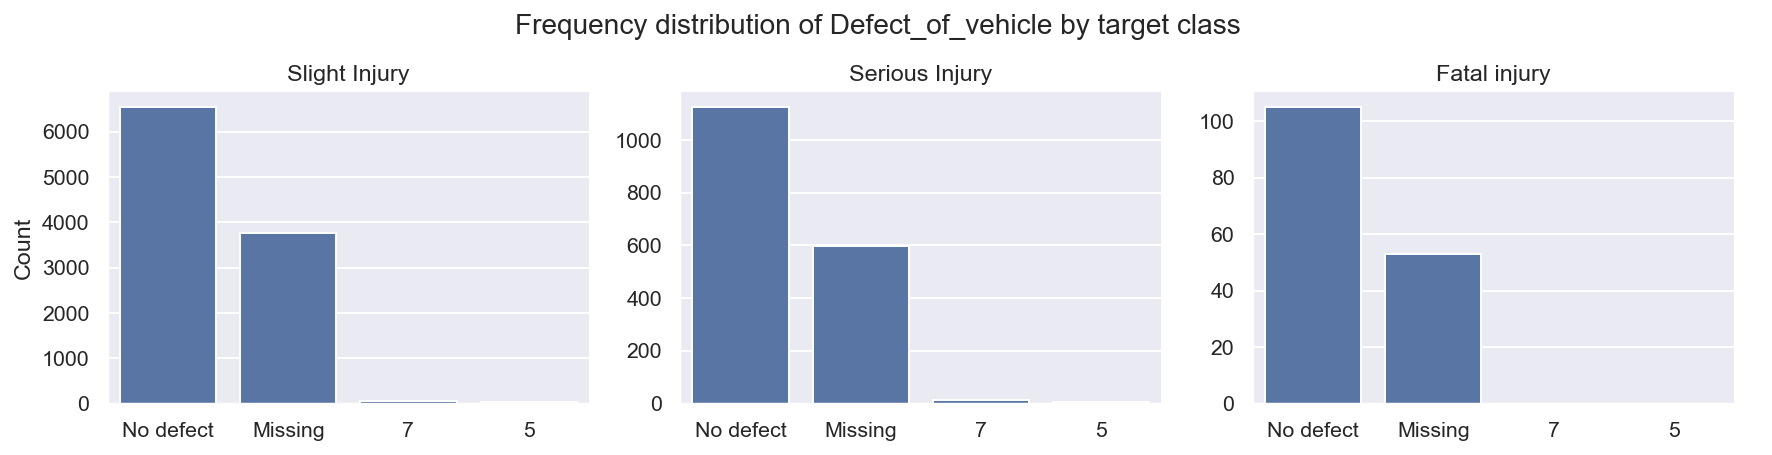

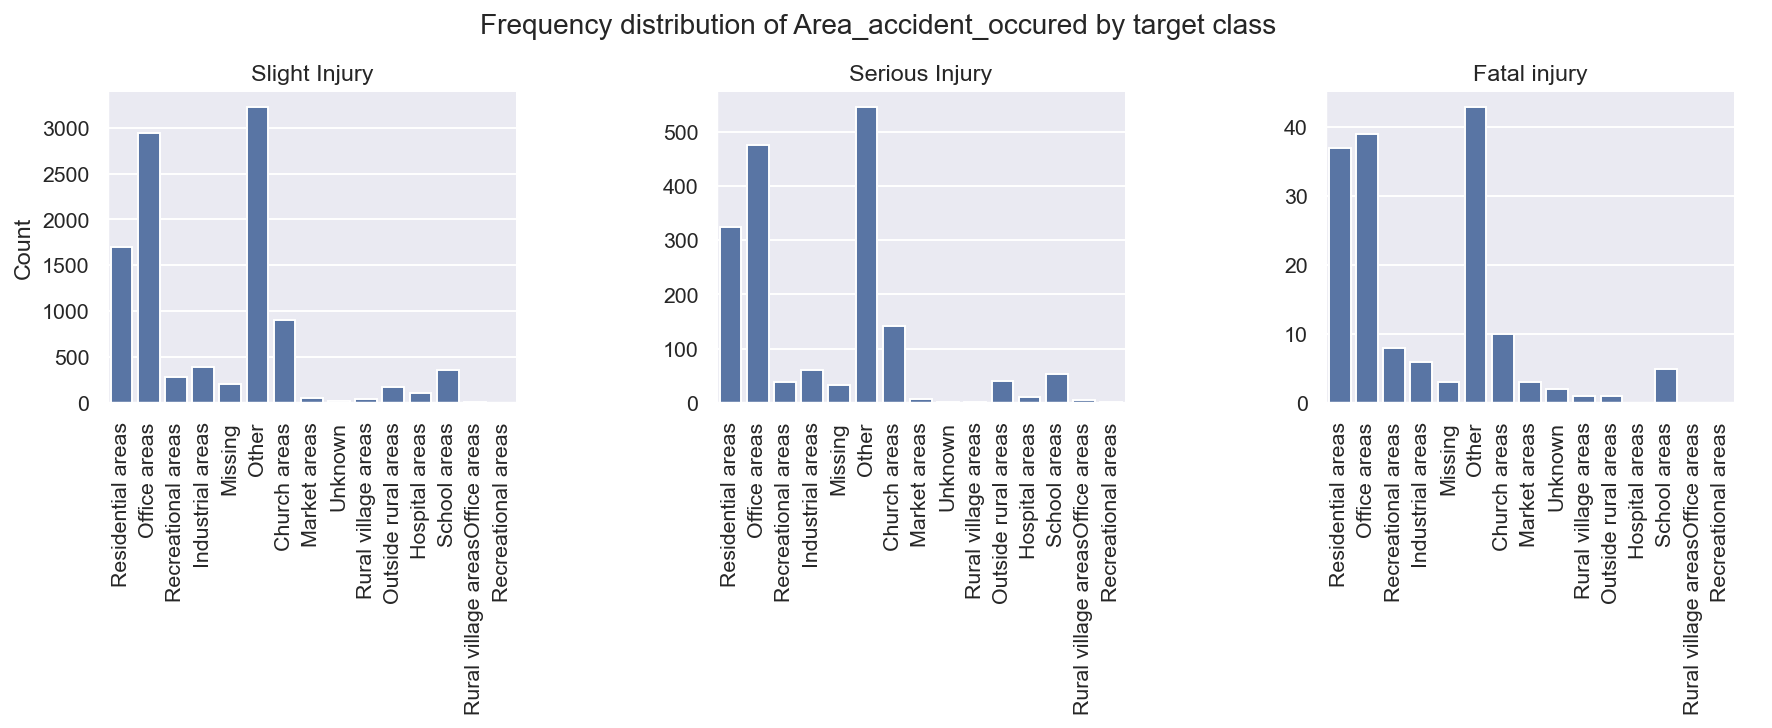

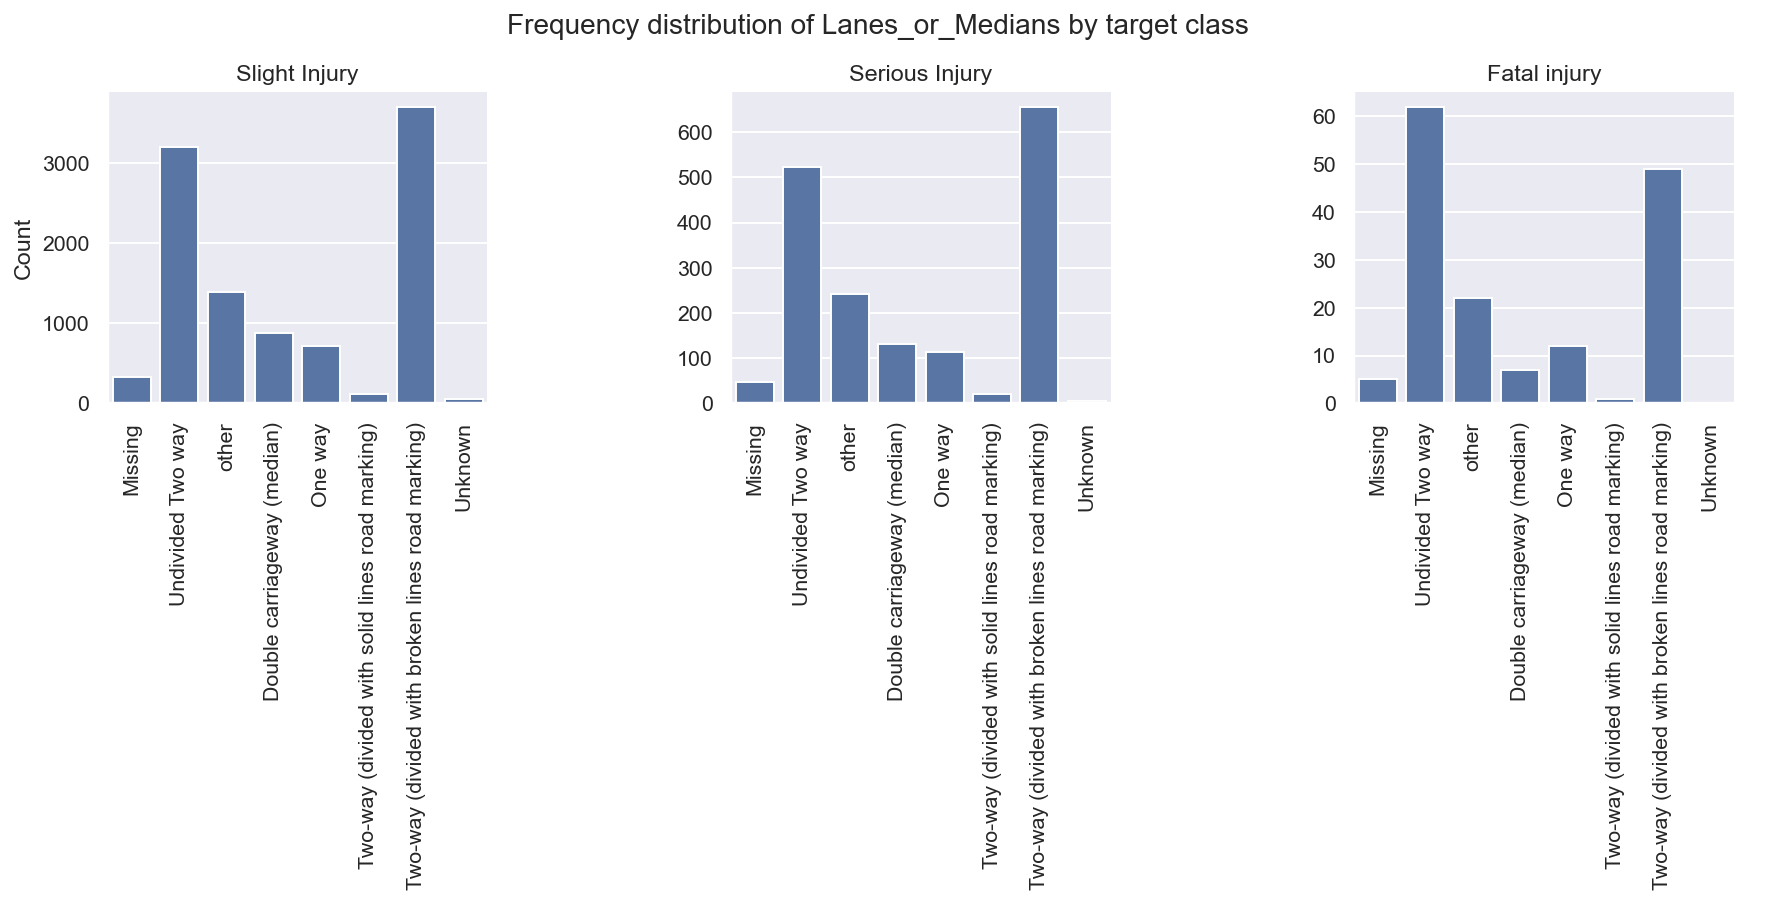

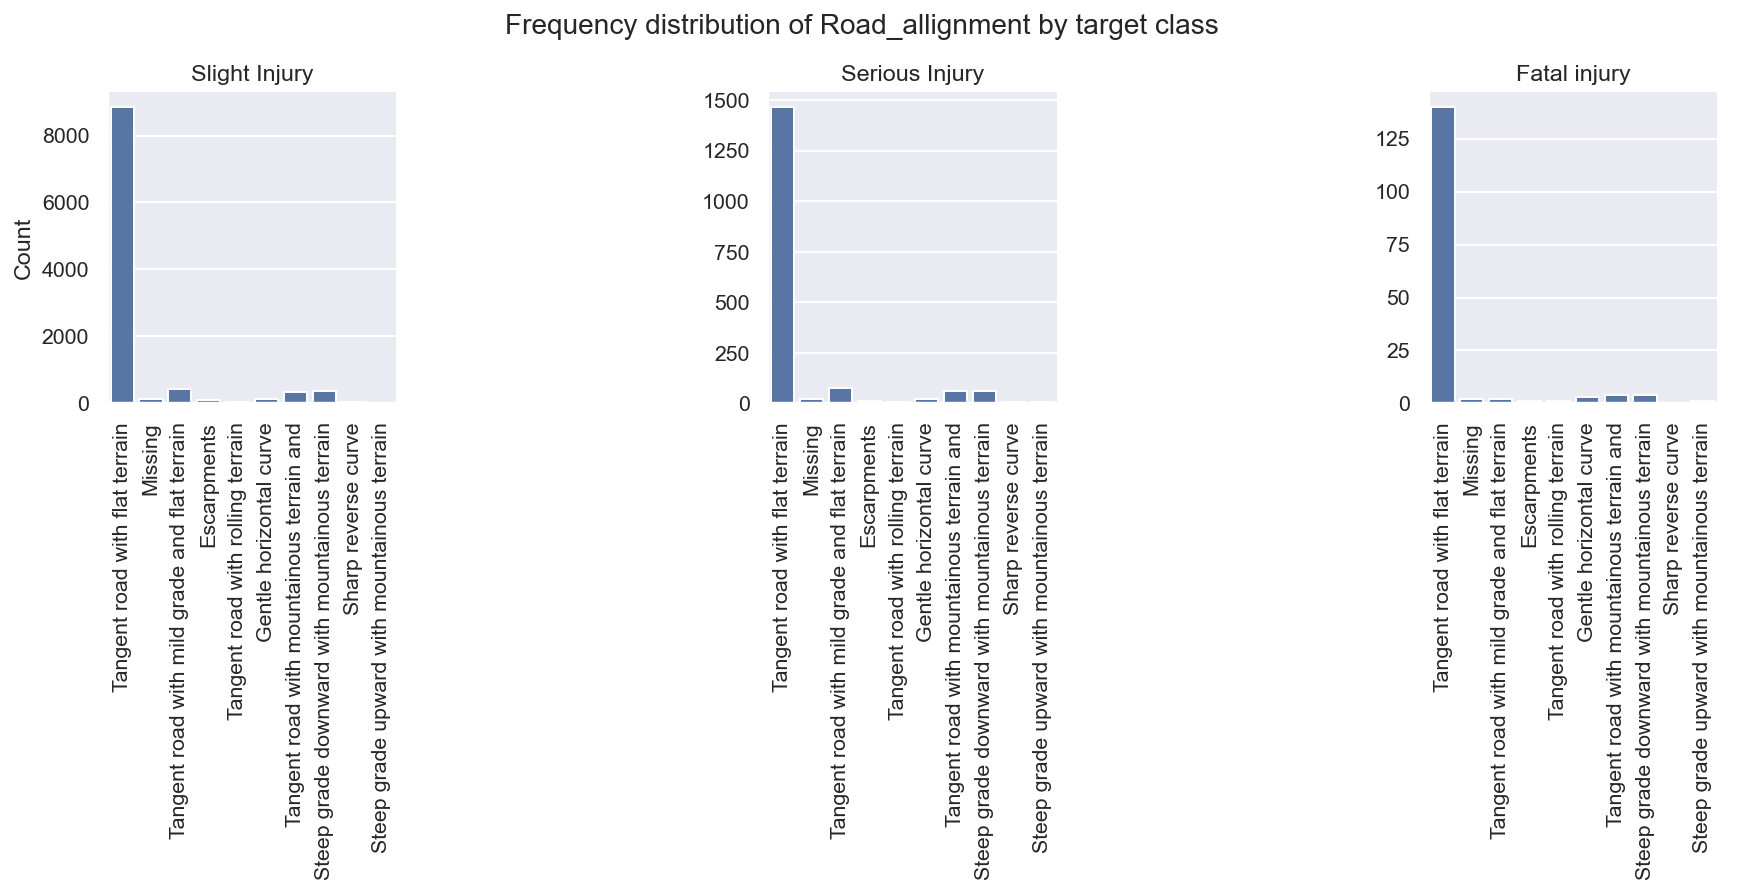

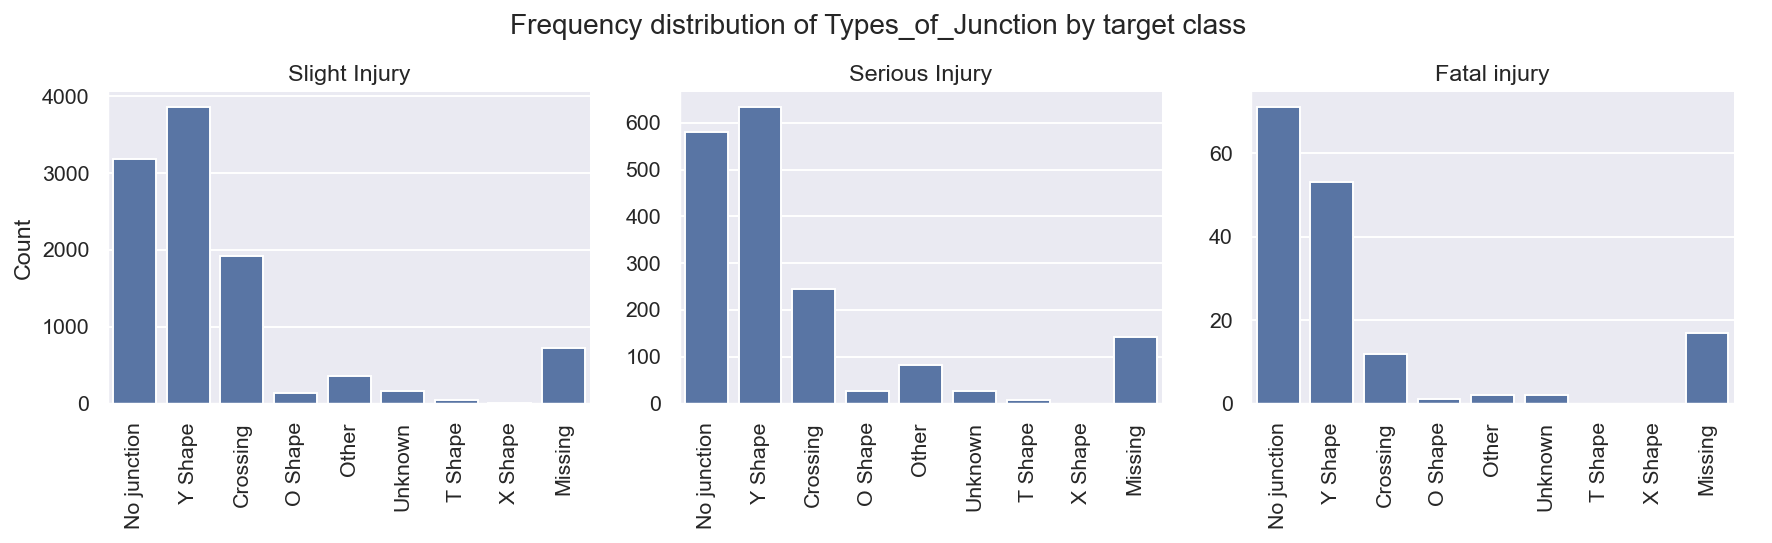

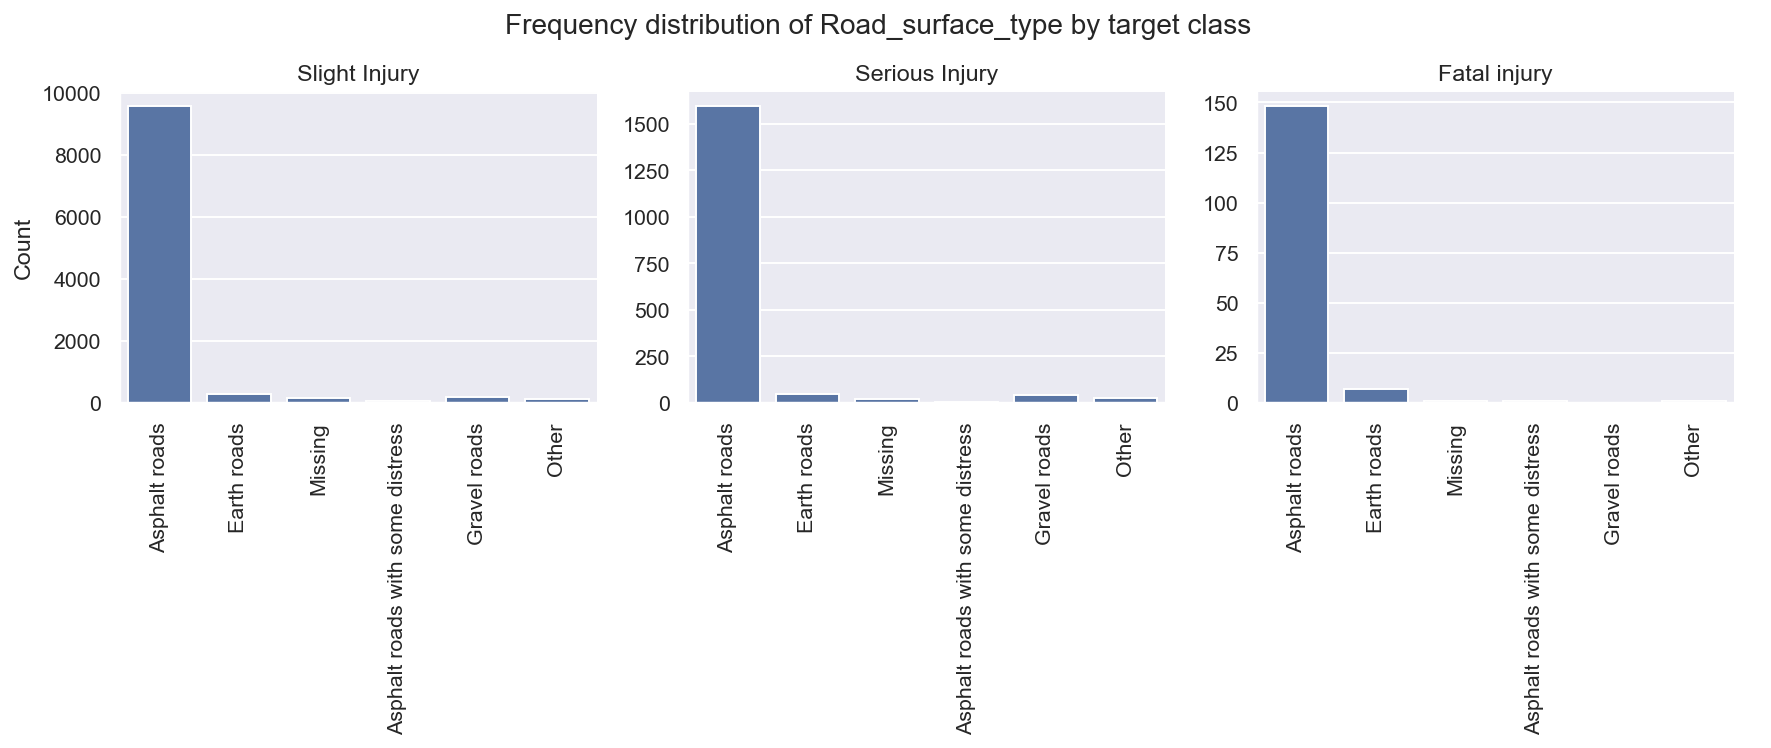

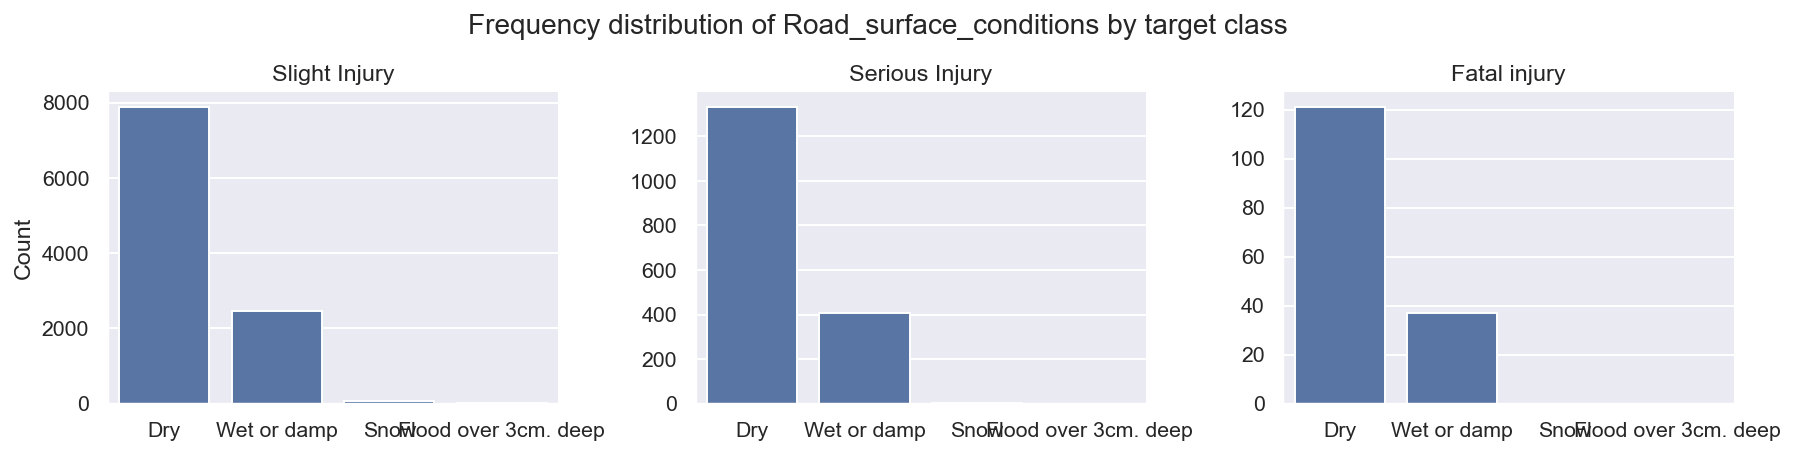

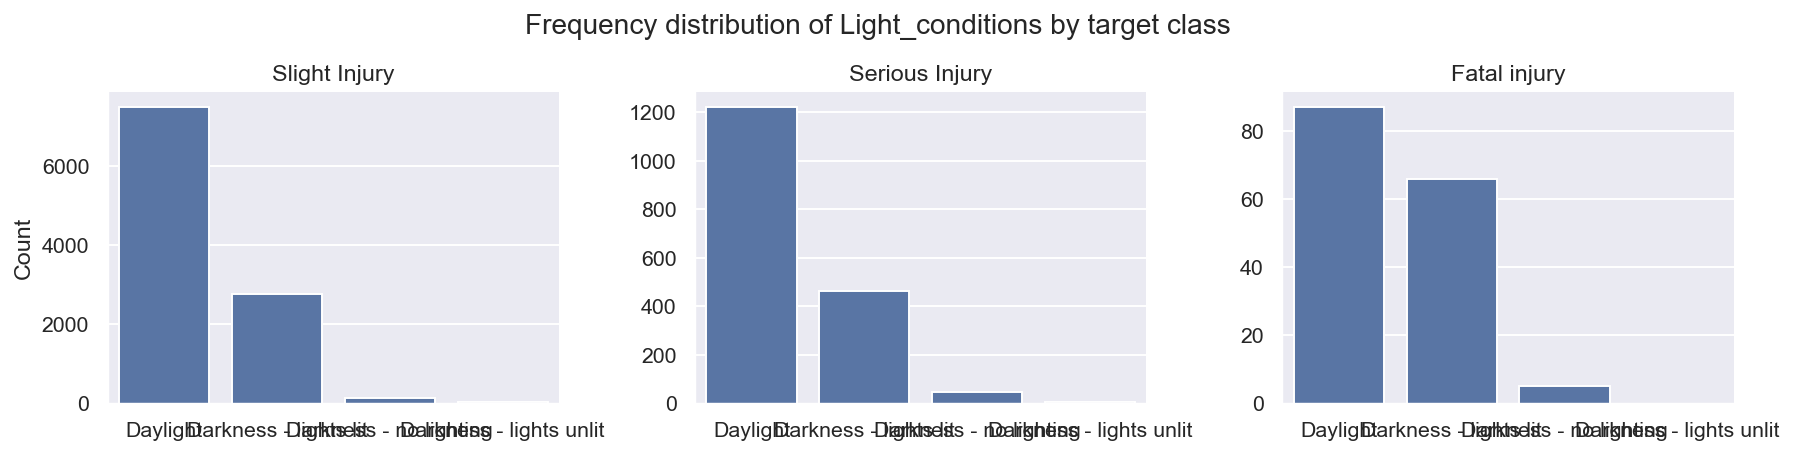

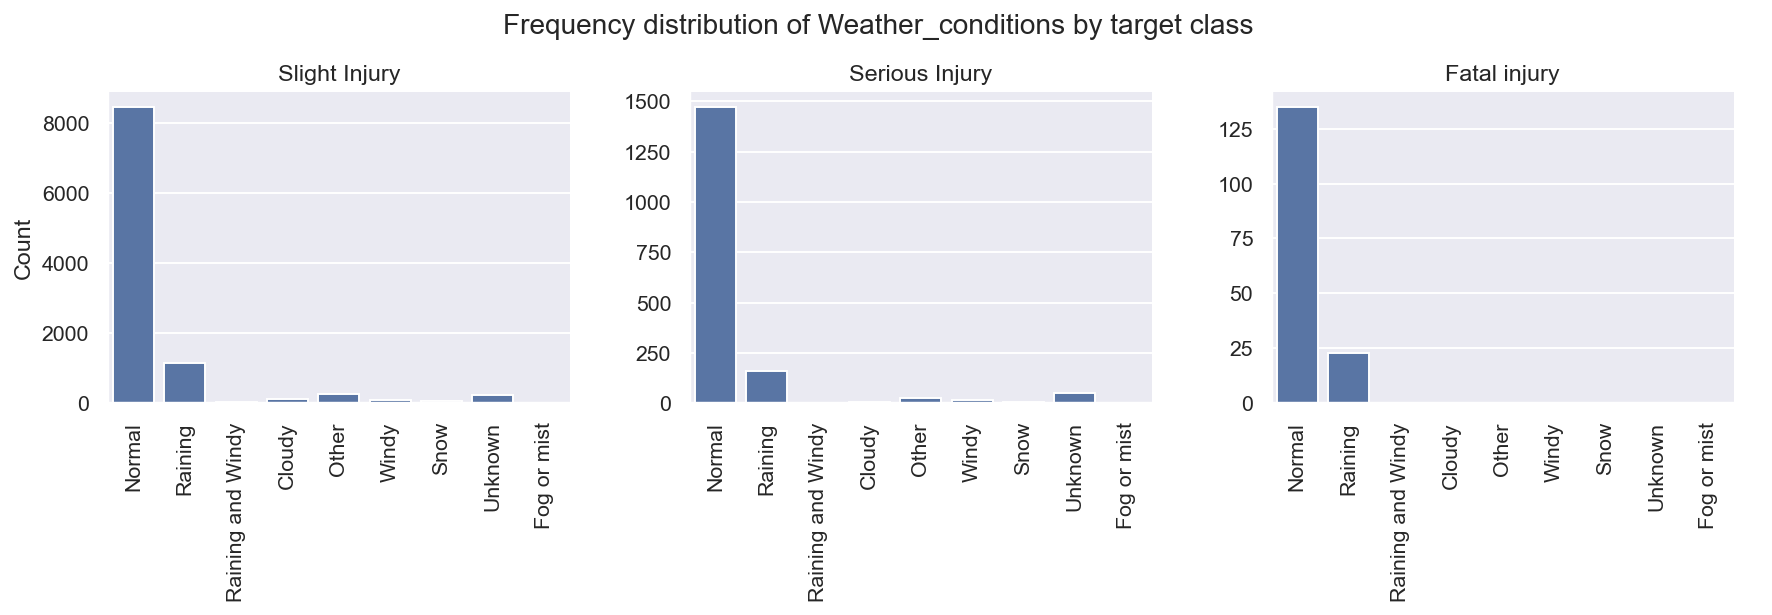

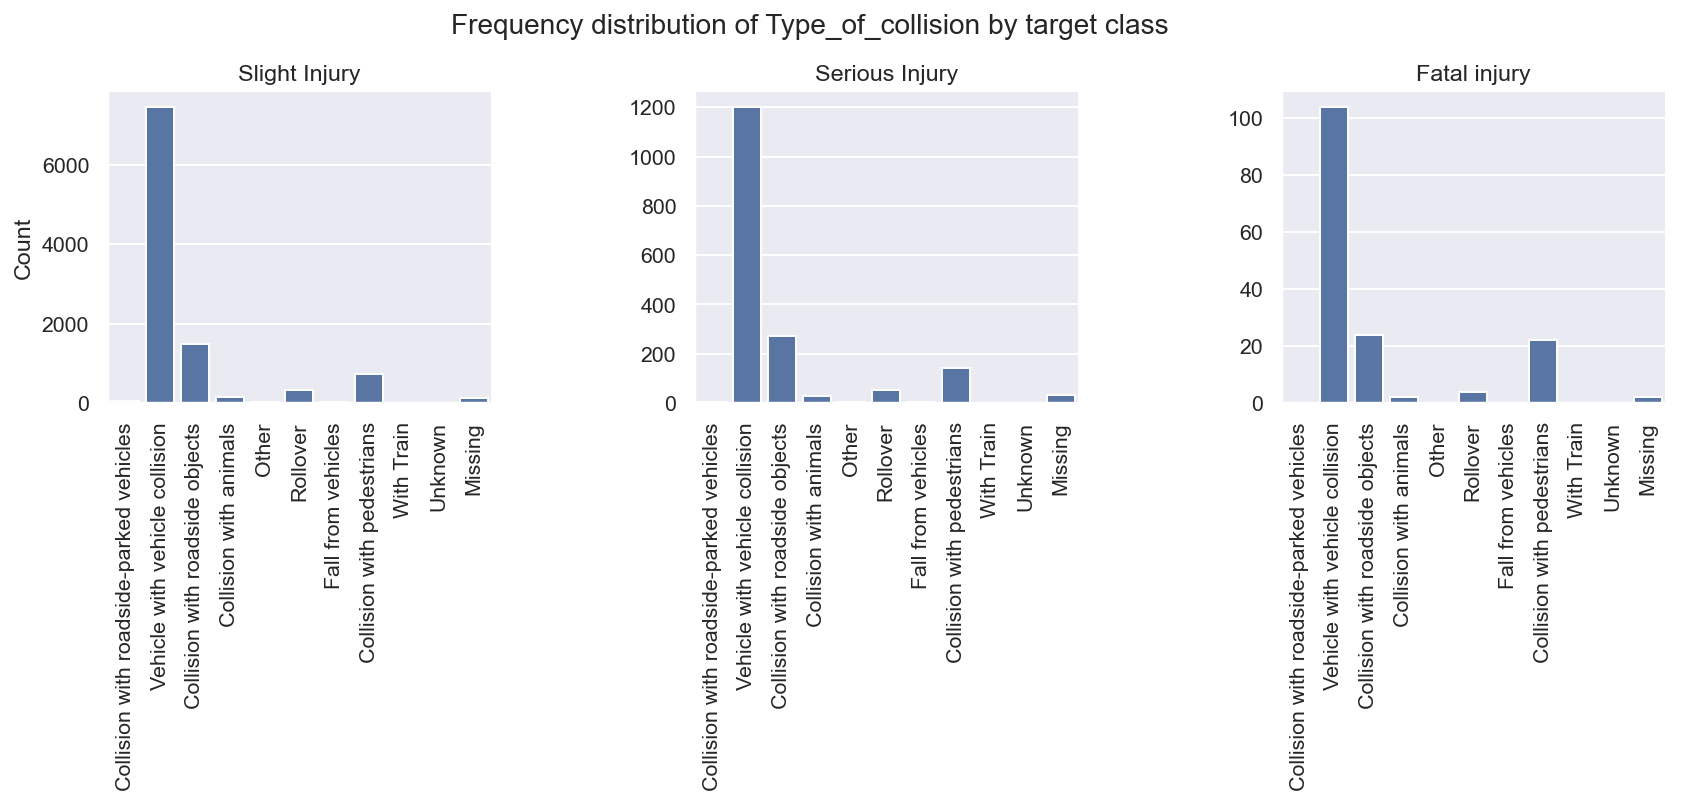

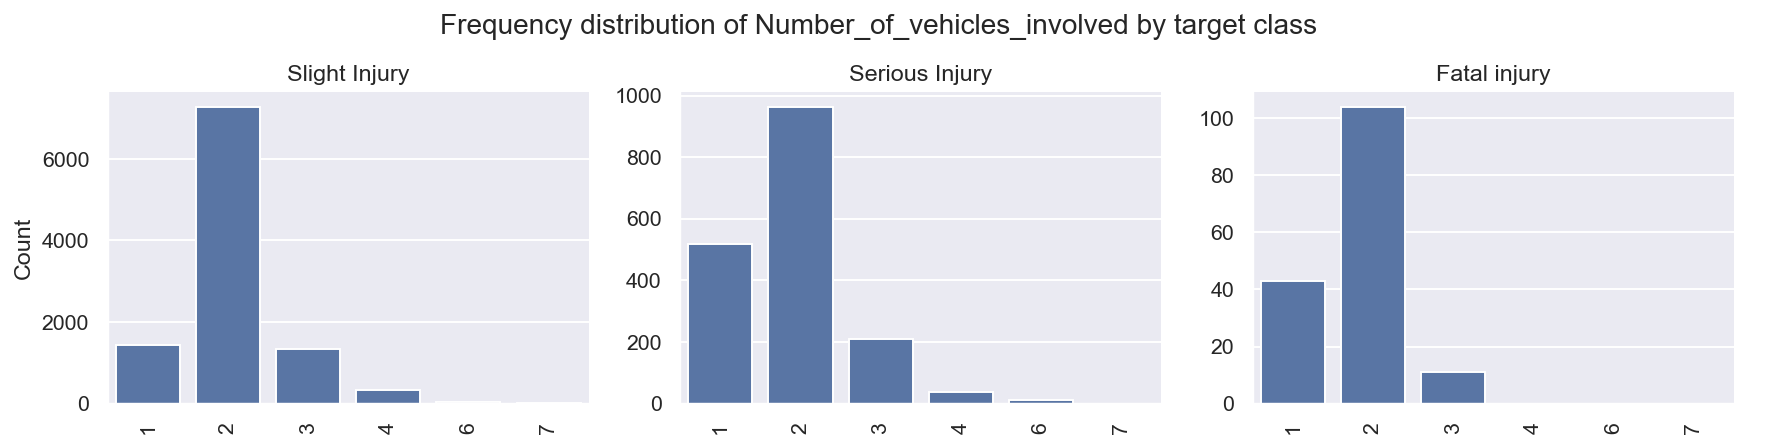

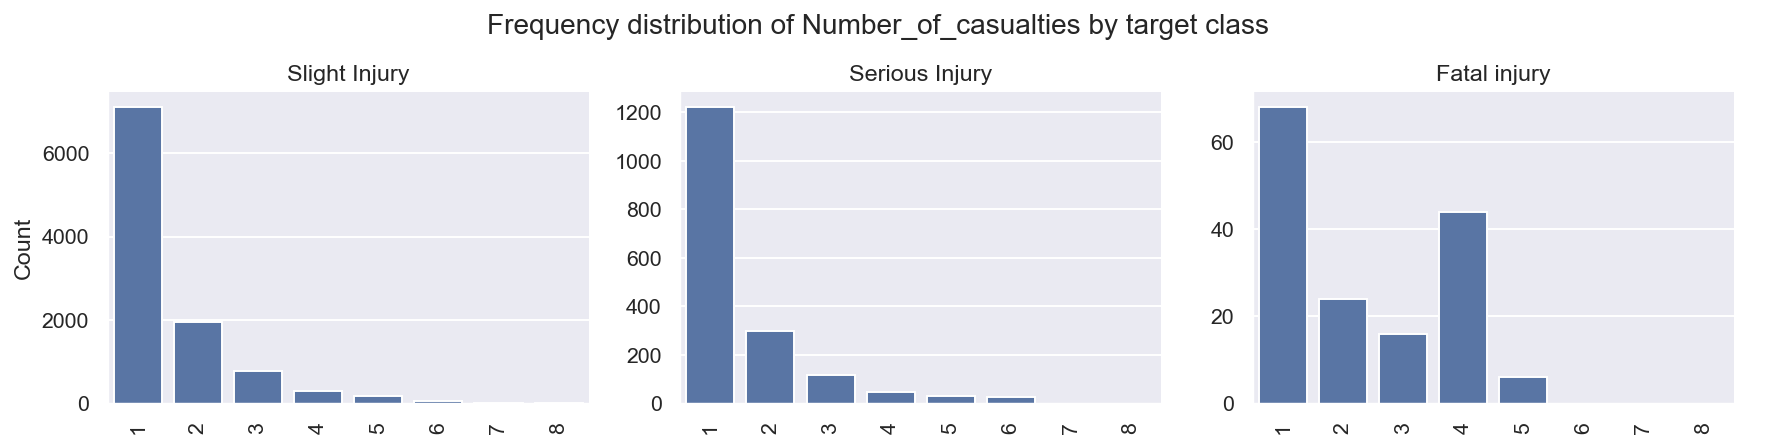

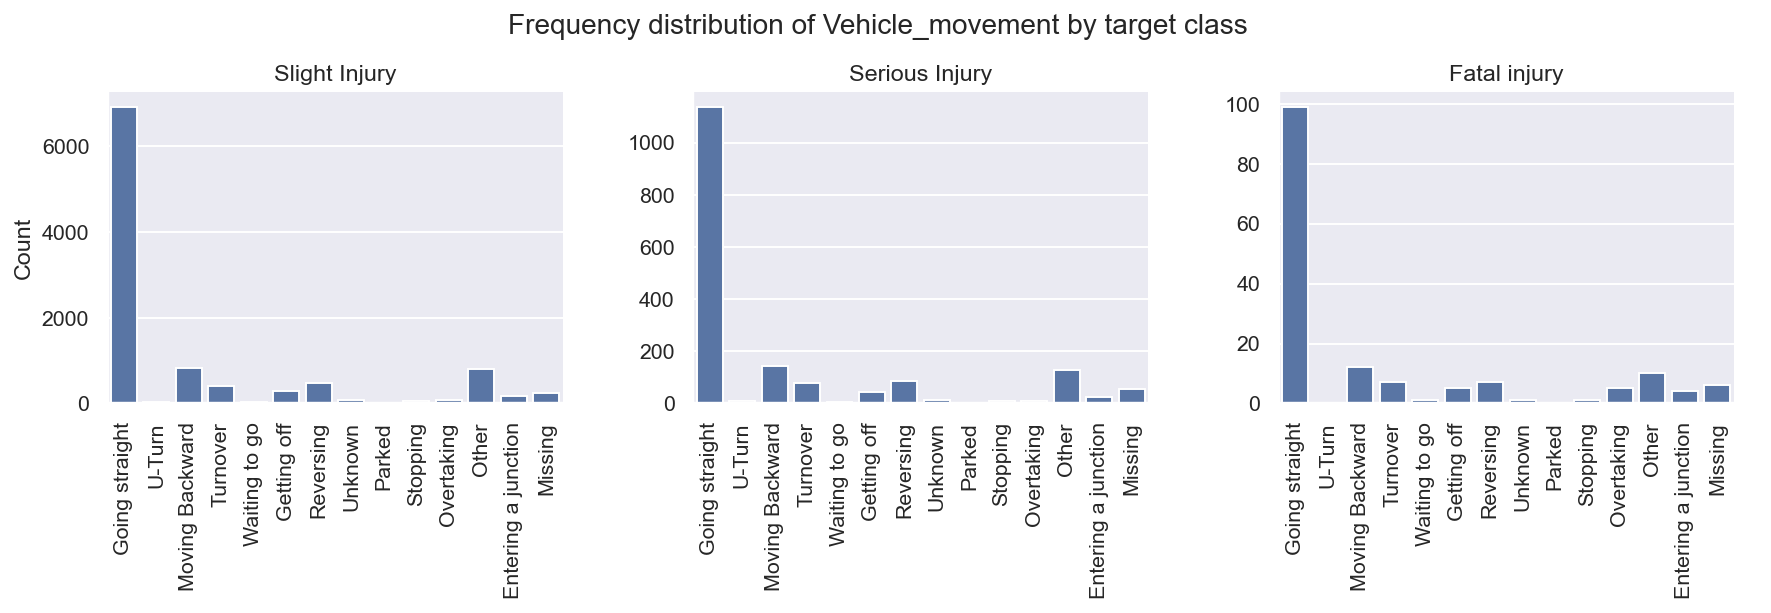

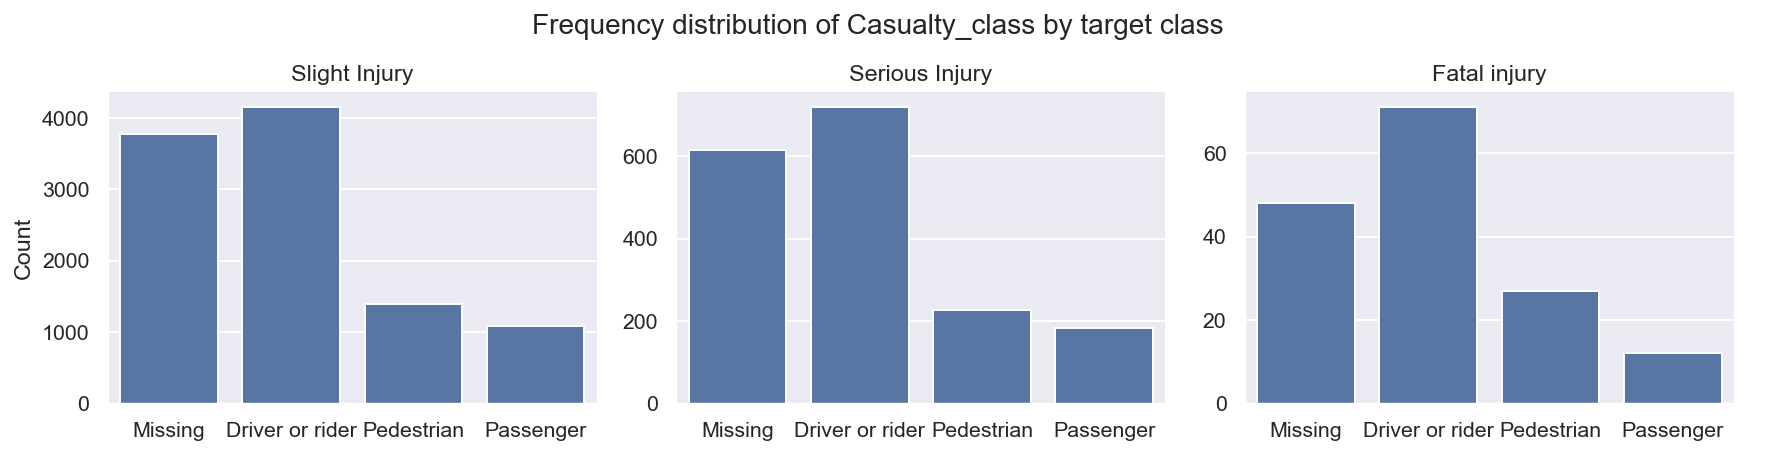

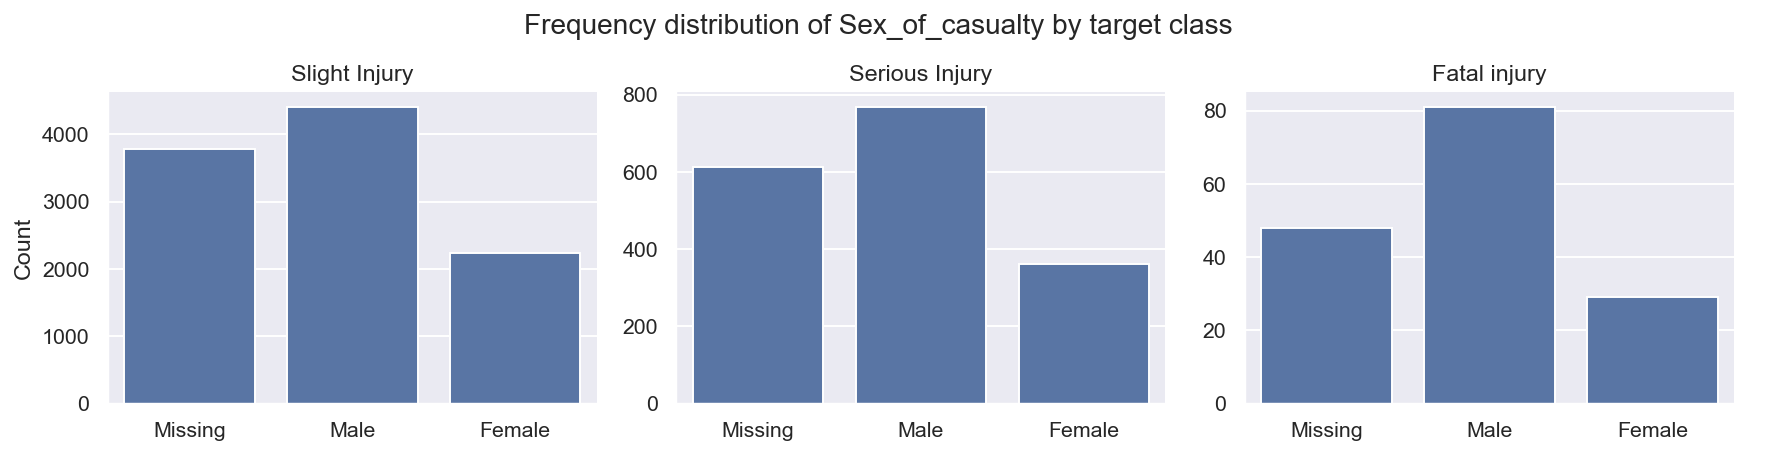

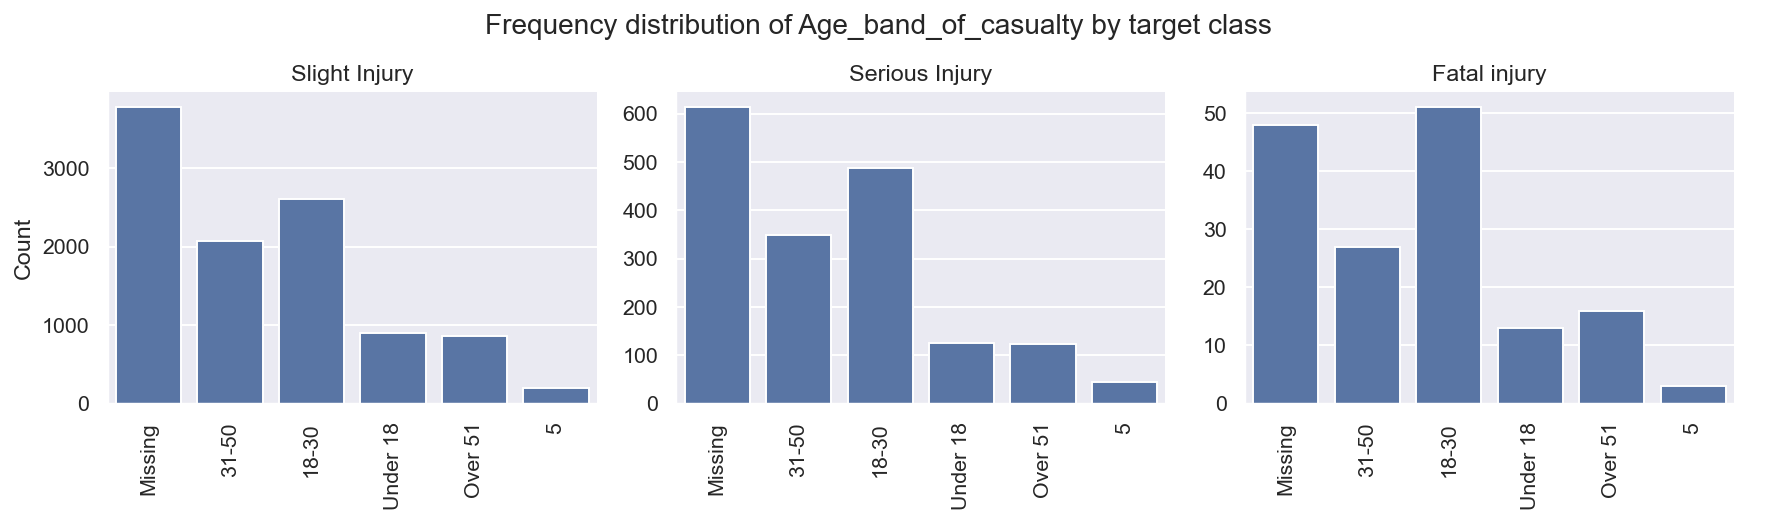

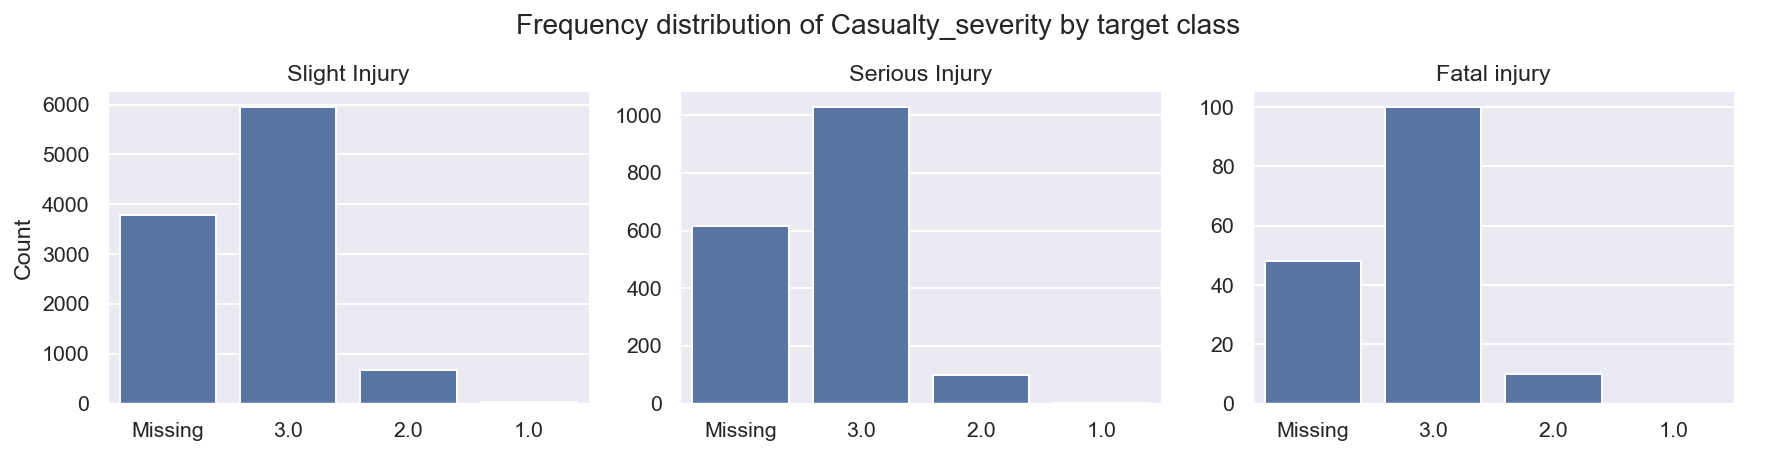

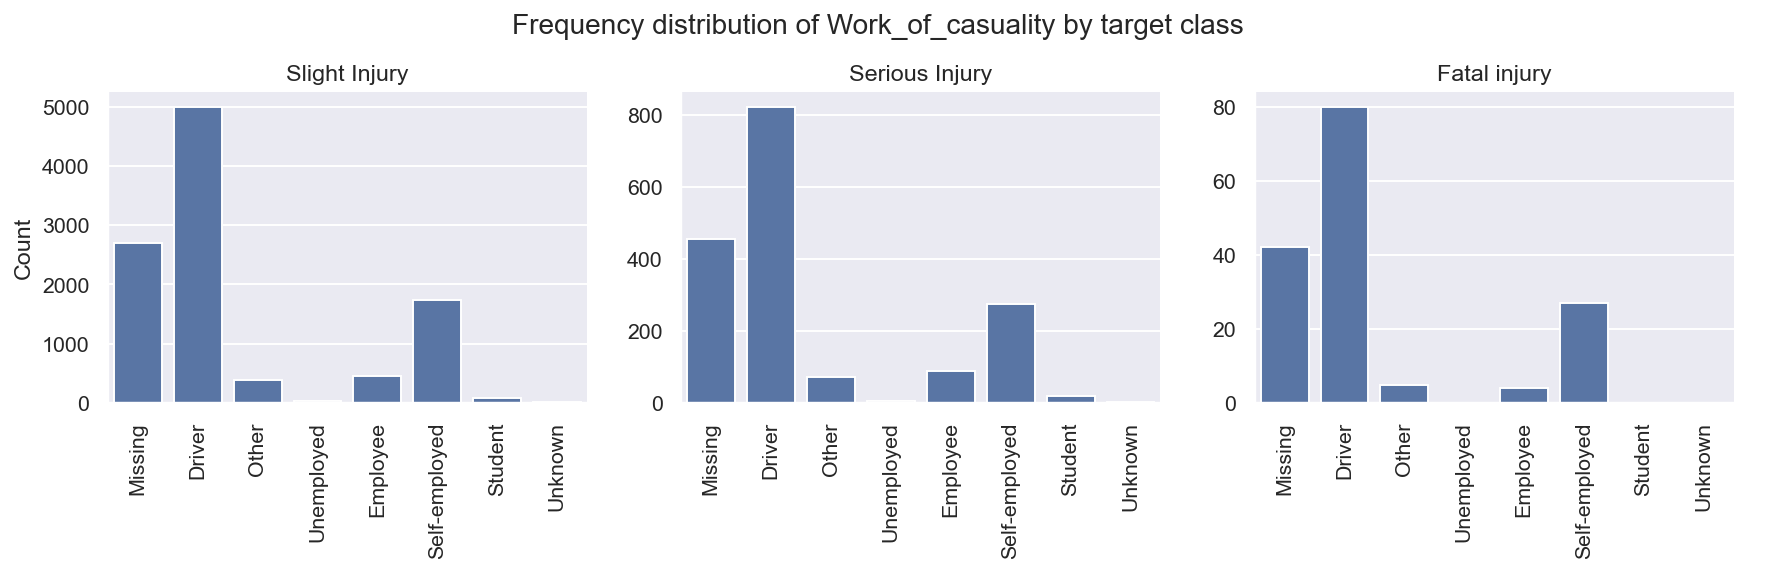

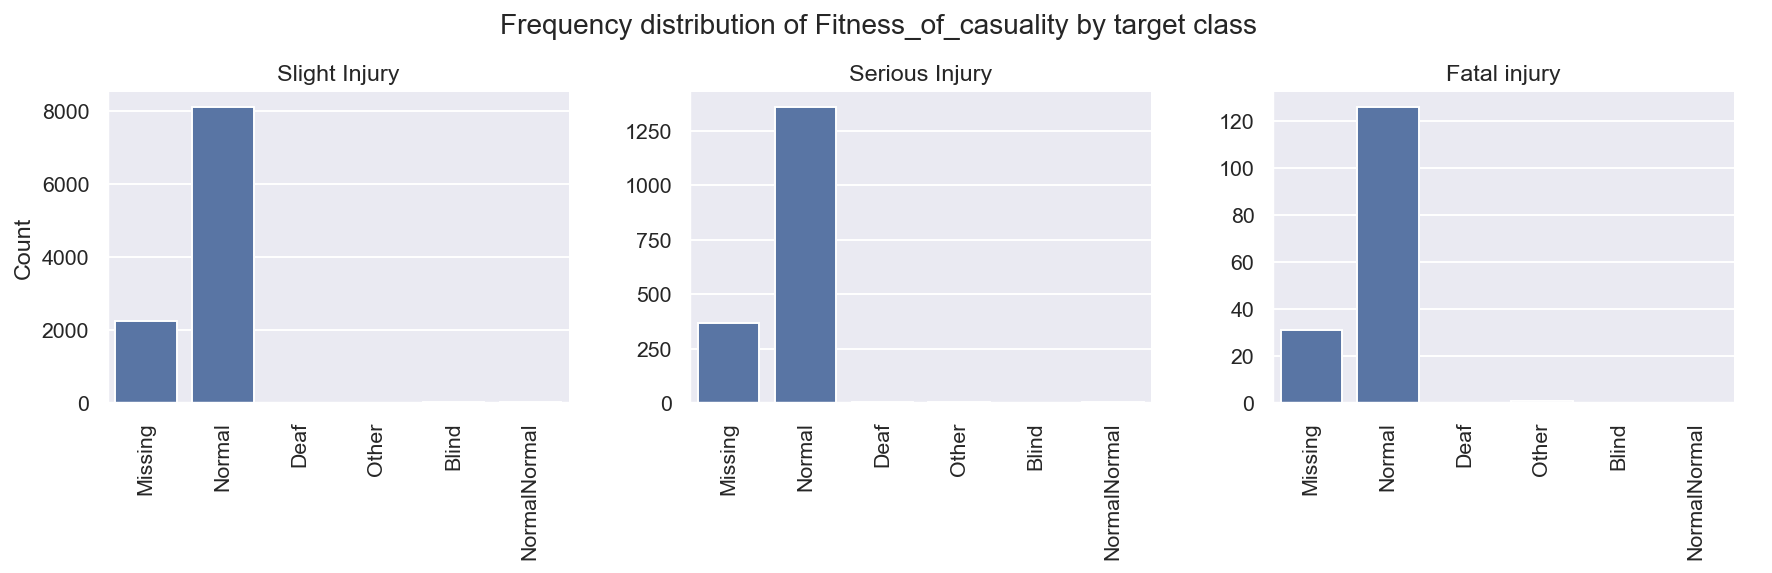

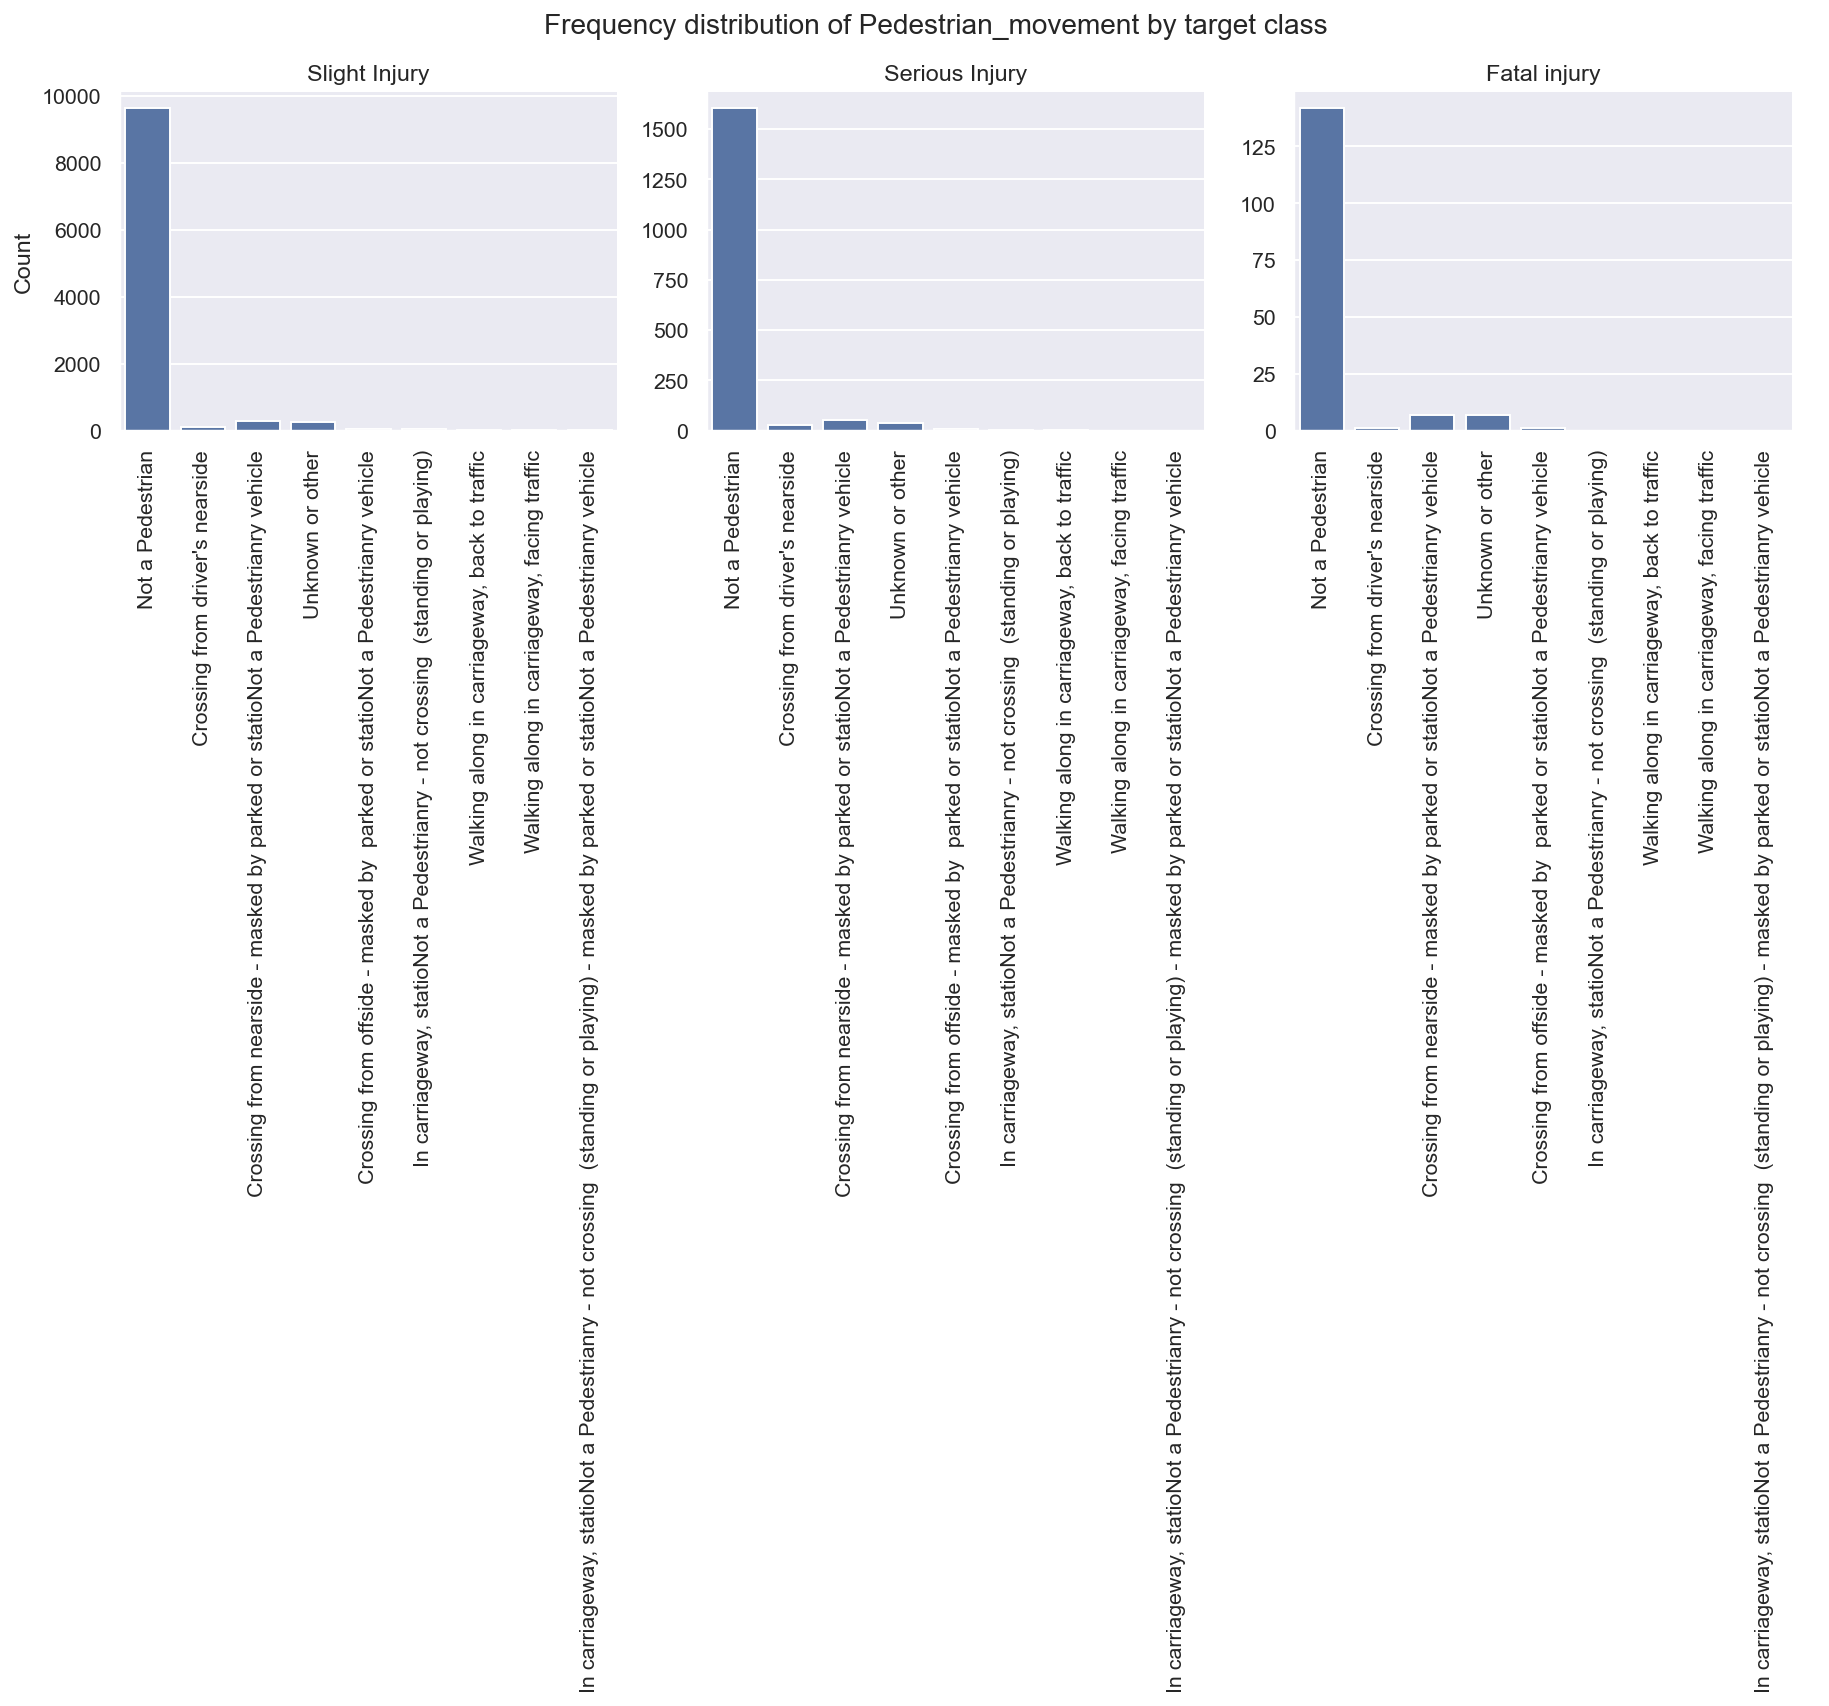

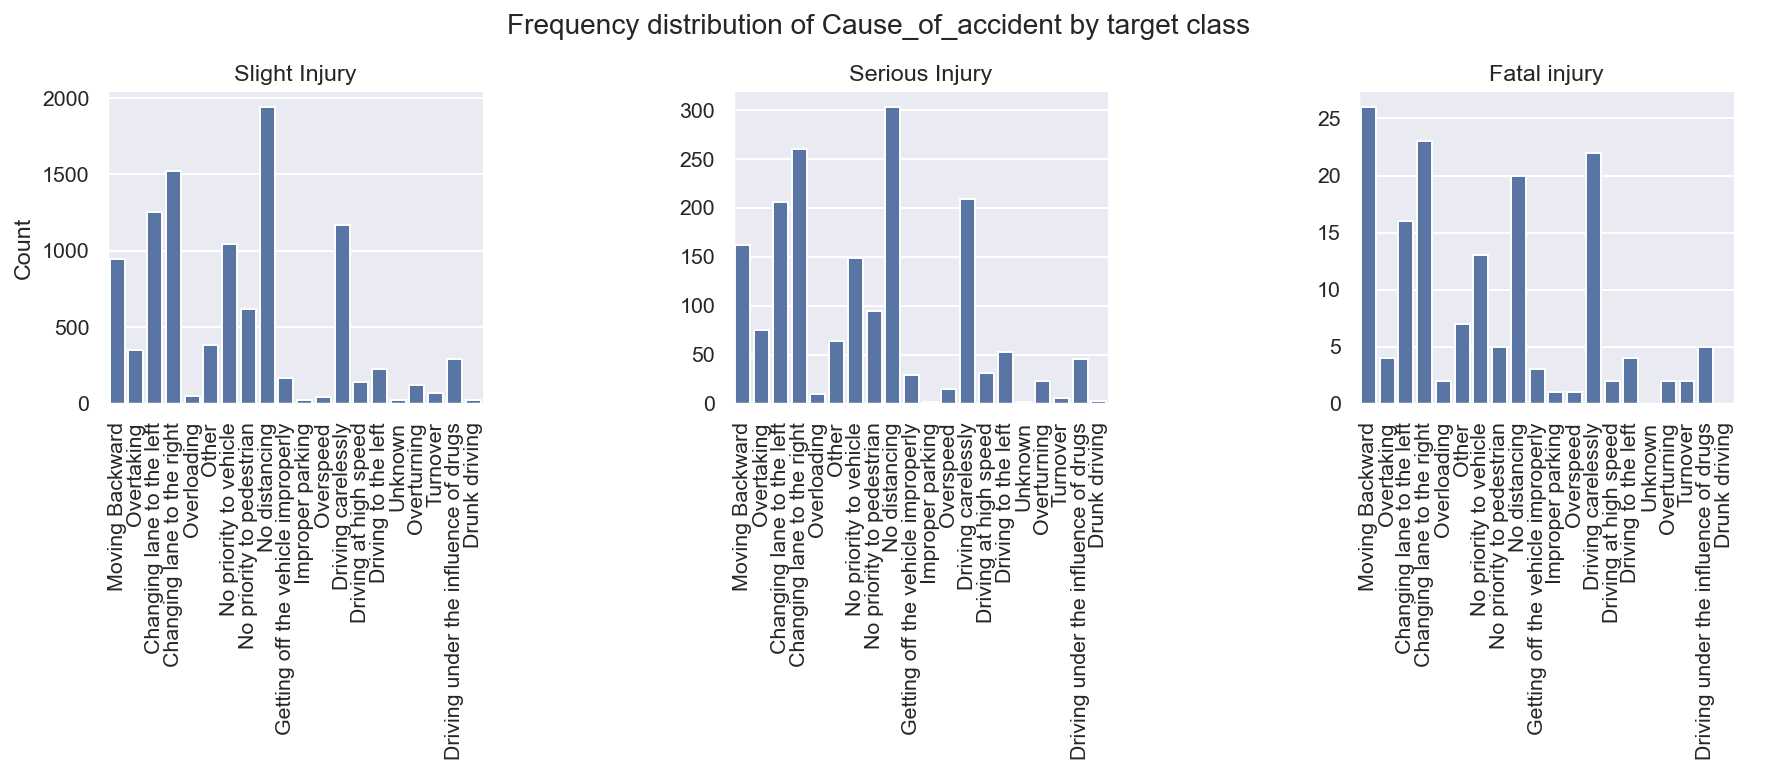

In [211]:
features_others = [c for c in data.columns if c not in [TARGET, "Time"]]
for feat in features_others:
    facet_countplot(data, feat)

## 3. Data Preprocessing

### 3.1 Time → Day/Night
Collapse `Time` to a simple day/night flag (Day = 06:00–18:00). Use a robust parser so odd strings don’t crash the run.

### 3.1.a Quick look at numeric outliers
Boxplots for the two numeric features (`Number_of_vehicles_involved`, `Number_of_casualties`) against the target. Values at the high end look plausible for accidents, so we’ll **keep** them.

### 3.2 Missing data
First, merge near-duplicate category labels (e.g., “Unknown or other” → “other”, fix the casualty age “5” code).  
Then convert textual placeholders like “unknown/other/na” to real `NaN` (case-insensitive).  
Finally, impute categoricals **proportionally** per column so the marginal distributions stay essentially the same pre/post imputation. We don’t touch the target.


In [212]:
TARGET = "Accident_severity"
TARGET_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]


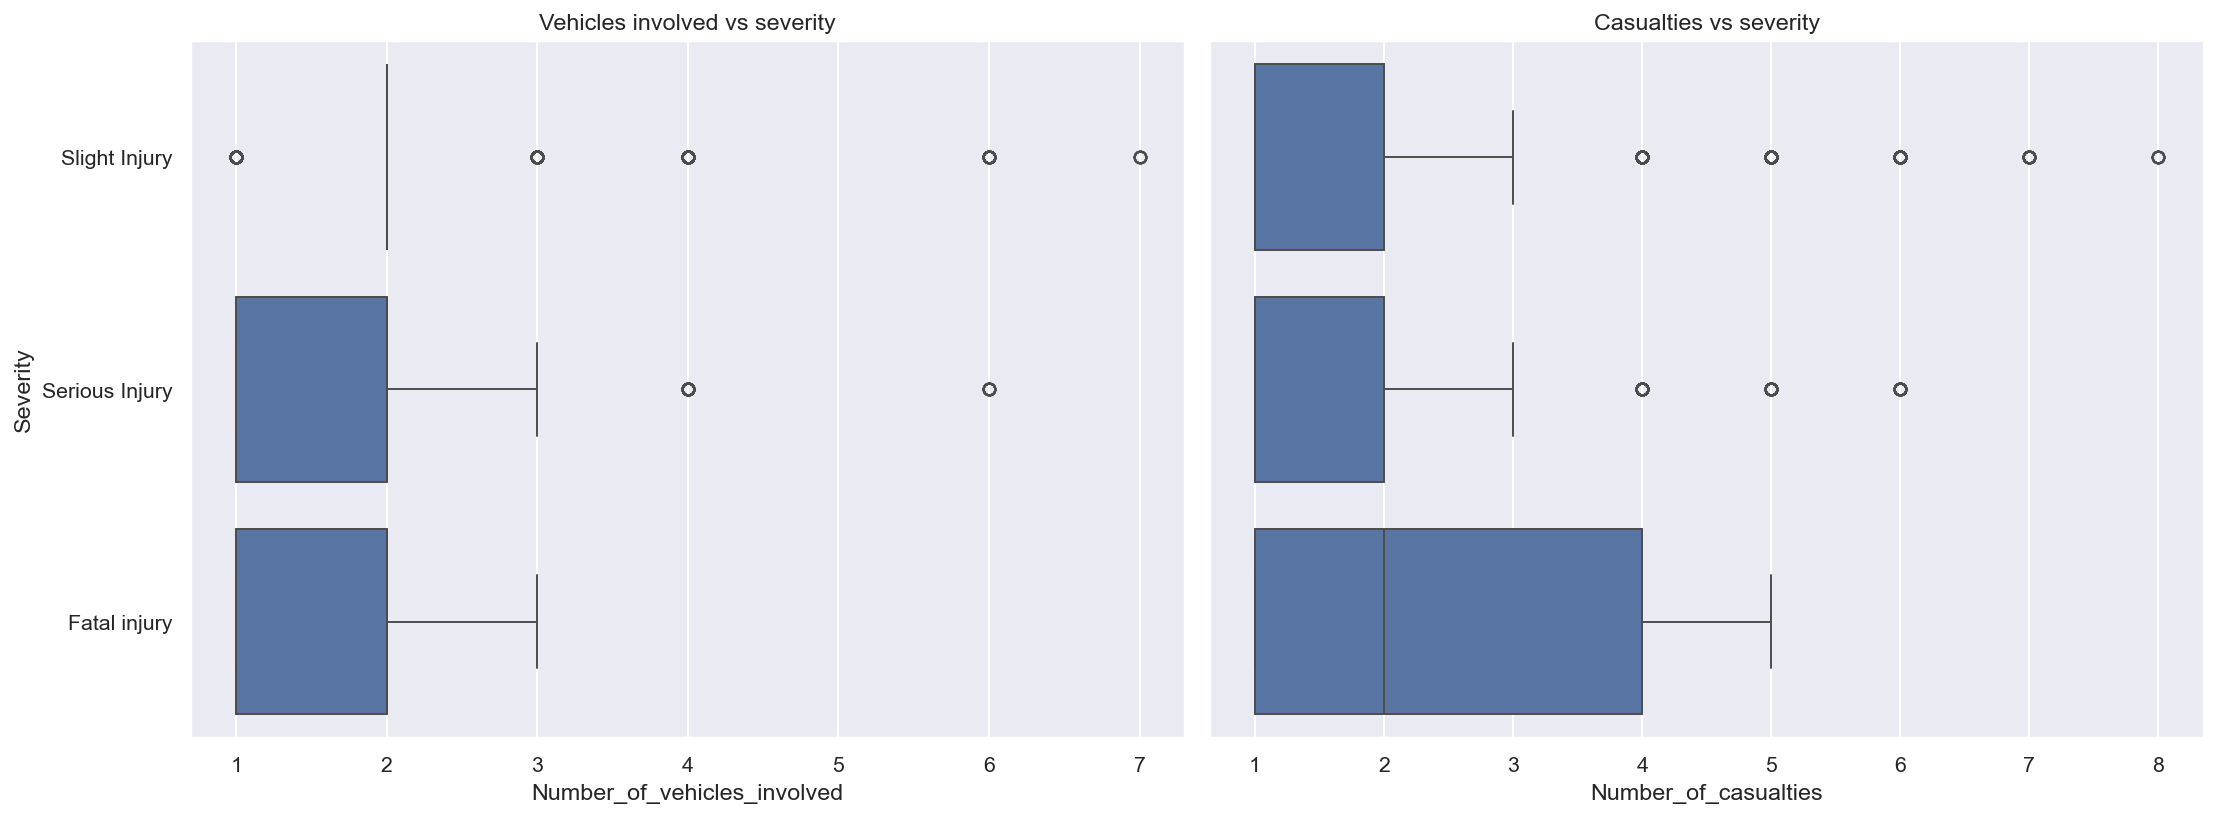

In [213]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=data, x="Number_of_vehicles_involved", y=TARGET, order=TARGET_ORDER, ax=ax1)
sns.boxplot(data=data, x="Number_of_casualties",       y=TARGET, order=TARGET_ORDER, ax=ax2).set(yticklabels=[])
ax1.set_title("Vehicles involved vs severity")
ax2.set_title("Casualties vs severity")
ax1.set_ylabel("Severity")
ax2.set_ylabel("")
plt.tight_layout()
plt.show()

In [214]:
def combine_similar(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.replace({
        "Unknown or other": "other",
        "Unknown": "unknown",
        "Other": "other",
        "Darkness - lights unlit": "Darkness - no lighting",
    })
    # Fix odd casualty age code "5" → treat as unknown to avoid mislabeling
    if "Age_band_of_casualty" in out.columns:
        out["Age_band_of_casualty"] = out["Age_band_of_casualty"].replace({"5": "unknown"})
    return out


In [215]:
data = combine_similar(data)


In [216]:
import re

def more_missing(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # case-insensitive replace for 'unknown', 'other', 'na'
    for col in out.columns:
        if out[col].dtype == "object":
            out[col] = out[col].replace(
                to_replace=re.compile(r"^(unknown|other|na)$", flags=re.IGNORECASE),
                value=np.nan,
                regex=True,
            )
    return out

data = more_missing(data)

In [217]:
na_counts = data.isna().sum()
print("Columns with missing values (sorted):")
print(na_counts[na_counts > 0].sort_values(ascending=False))

Columns with missing values (sorted):
Service_year_of_vehicle    6811
Age_band_of_casualty       4687
Sex_of_casualty            4443
Casualty_severity          4443
Casualty_class             4443
Defect_of_vehicle          4427
Area_accident_occured      4080
Work_of_casuality          3680
Fitness_of_casuality       2653
Type_of_vehicle            2158
Lanes_or_Medians           2102
Age_band_of_driver         1548
Types_of_Junction          1523
Vehicle_movement           1333
Driving_experience          862
Educational_level           841
Vehicle_driver_relation     716
Weather_conditions          588
Owner_of_vehicle            504
Cause_of_accident           481
Road_surface_type           339
Pedestrian_movement         293
Type_of_collision           195
Sex_of_driver               178
Road_allignment             142
dtype: int64


In [218]:
from sklearn.impute import SimpleImputer

In [219]:
def mode_imputer(df: pd.DataFrame) -> pd.DataFrame:
    imputer = SimpleImputer(strategy="most_frequent")
    out = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    return out


In [220]:
def unknown_imputer(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        mask = out[col].isna()
        if mask.any():
            if out[col].dtype == "O":
                out.loc[mask, col] = "Unknown"
            else:
                out.loc[mask, col] = out[col].median()
    return out


In [221]:
def prop_imputer(df: pd.DataFrame, target_col: str, seed: int = 42) -> pd.DataFrame:

    rng = np.random.default_rng(seed)
    out = df.copy()
    for col in out.columns:
        if col == target_col:
            continue
        mask = out[col].isna()
        if not mask.any():
            continue

        if not (out[col].dtype == "O"):  
            out.loc[mask, col] = out[col].median()
            continue

        vals = out.loc[~mask, col].dropna()
        if vals.empty:

            out.loc[mask, col] = "Unknown"
            continue

        probs = vals.value_counts(normalize=True)
        choices = probs.index.to_numpy()
        p = probs.values

        sampled = rng.choice(choices, size=mask.sum(), replace=True, p=p)
        out.loc[mask, col] = sampled

    return out

In [222]:
data_imp = prop_imputer(data, target_col=TARGET, seed=42)


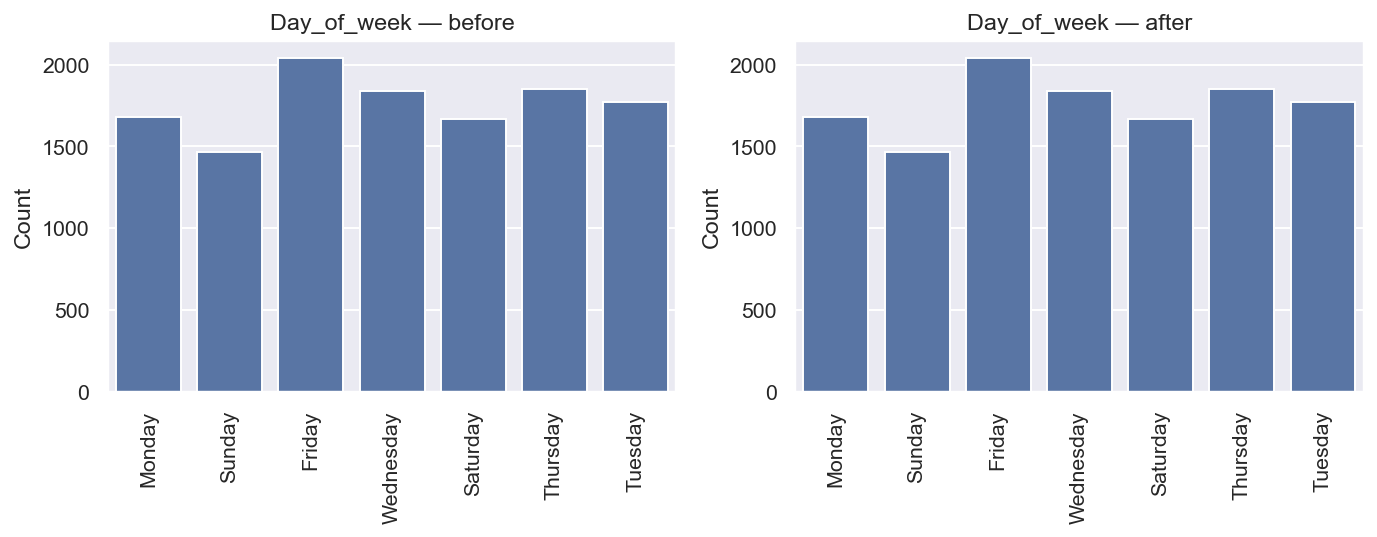

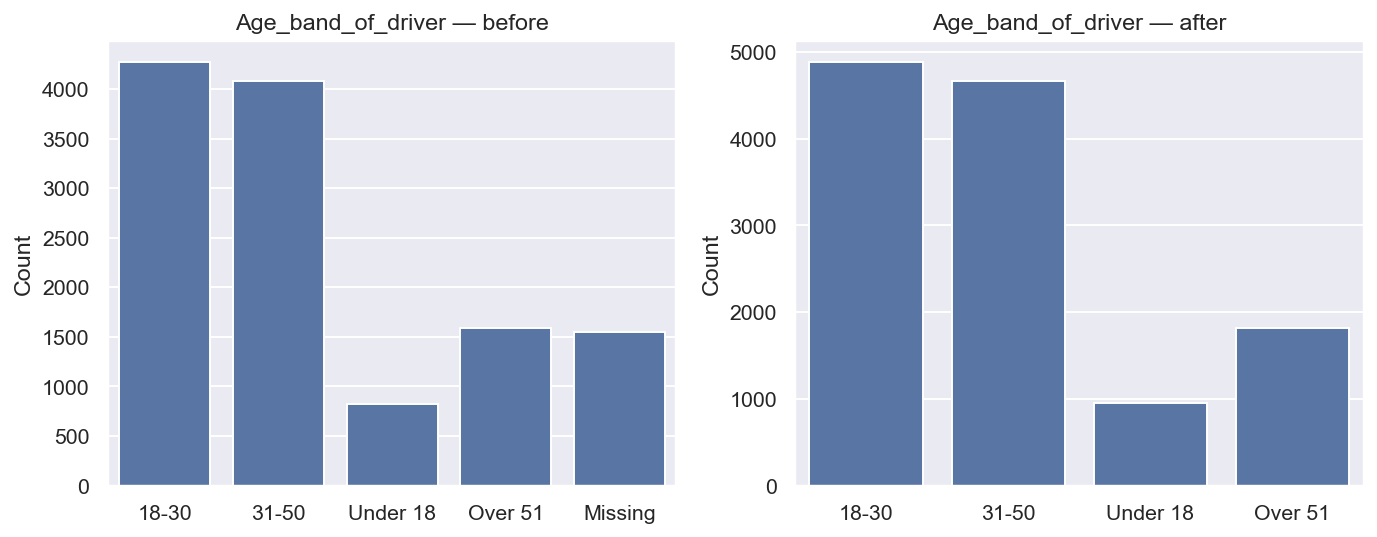

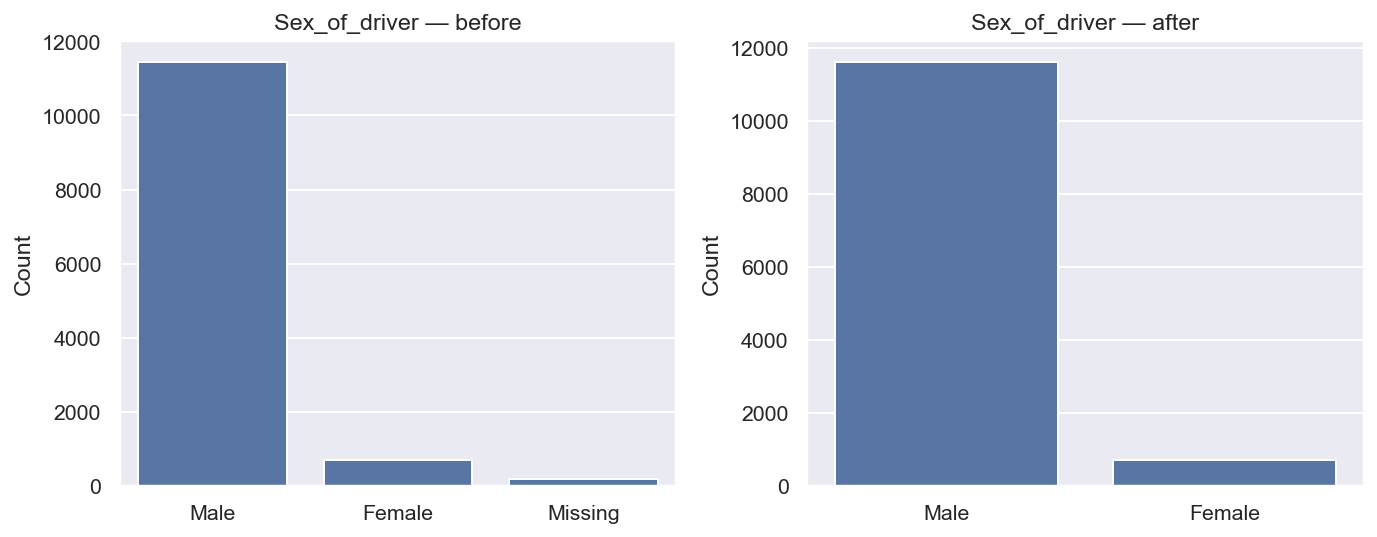

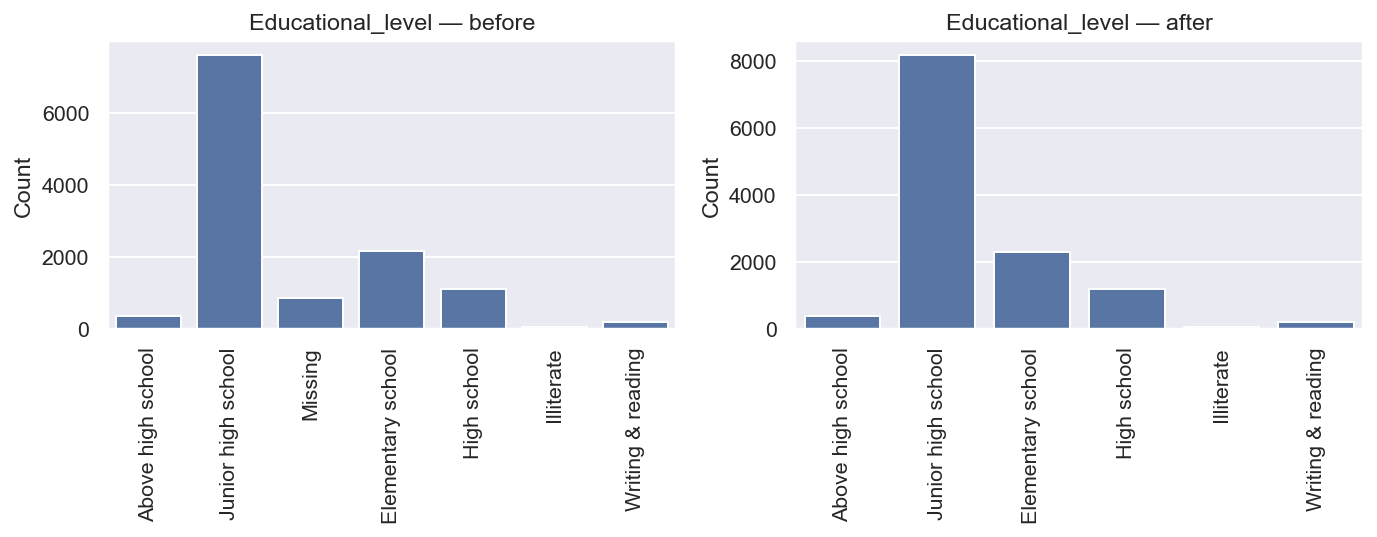

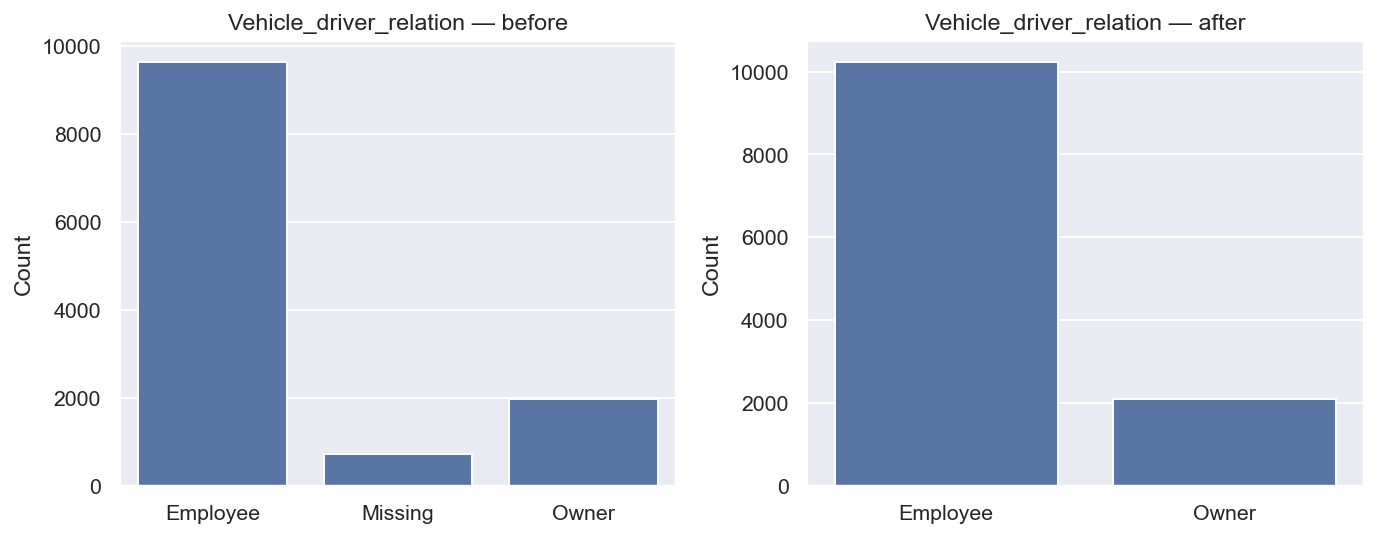

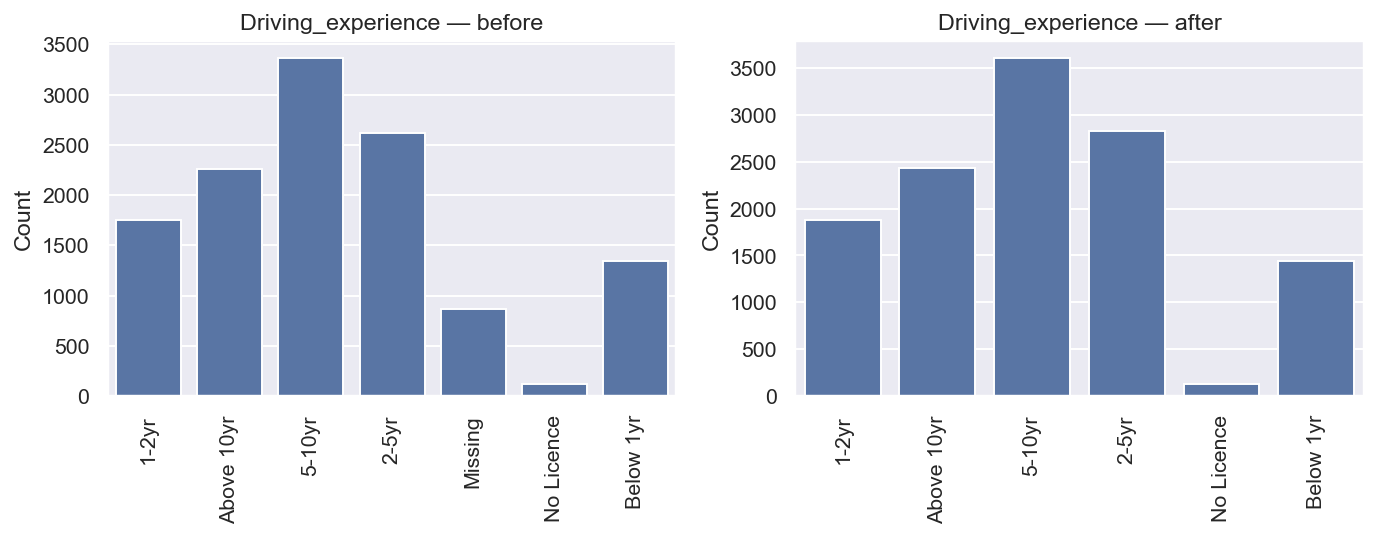

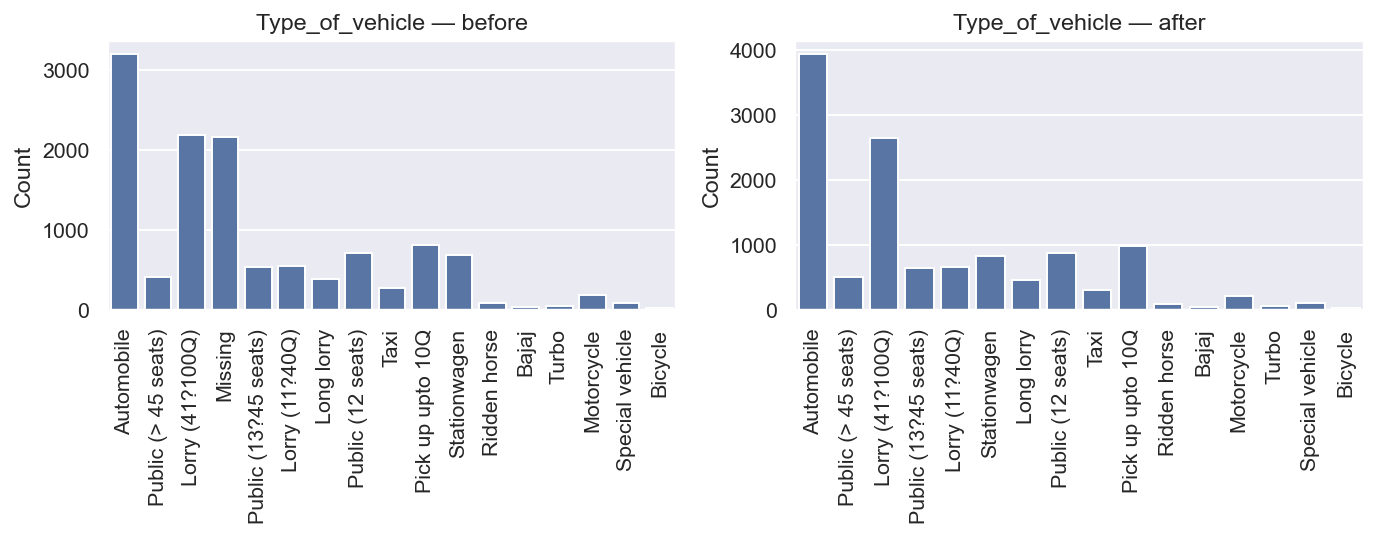

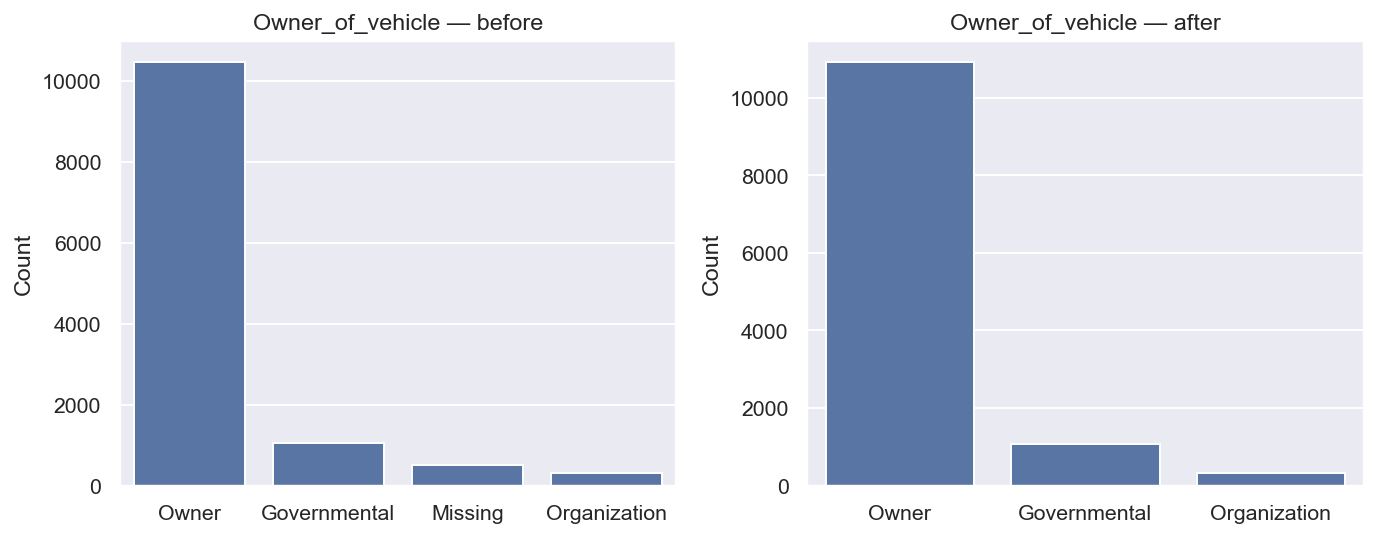

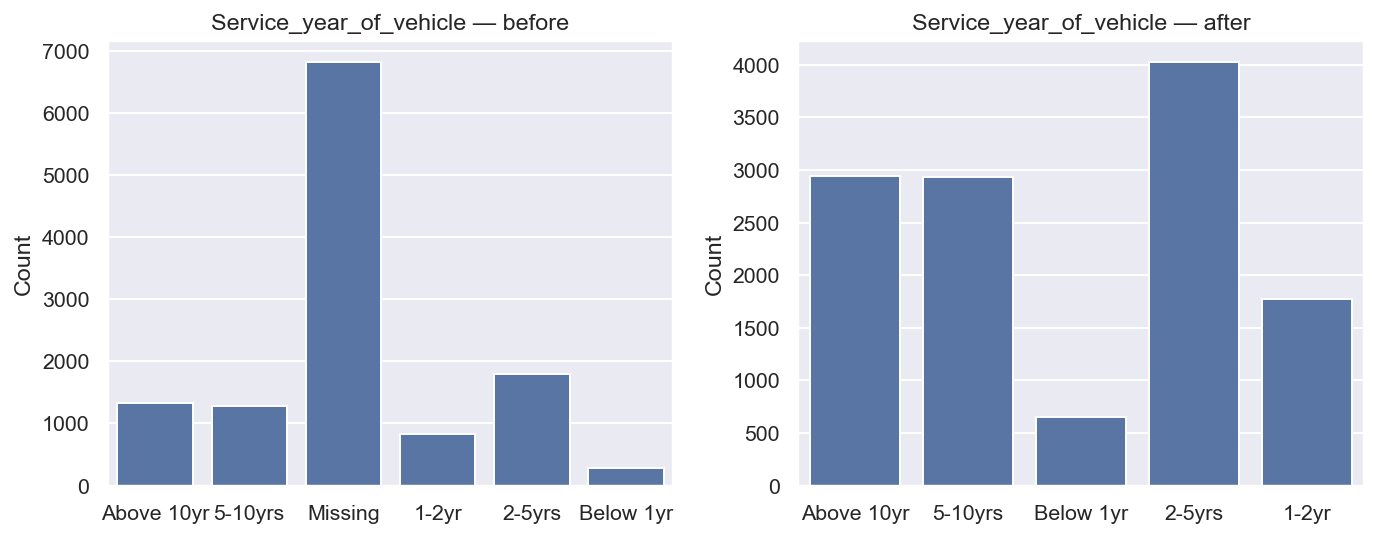

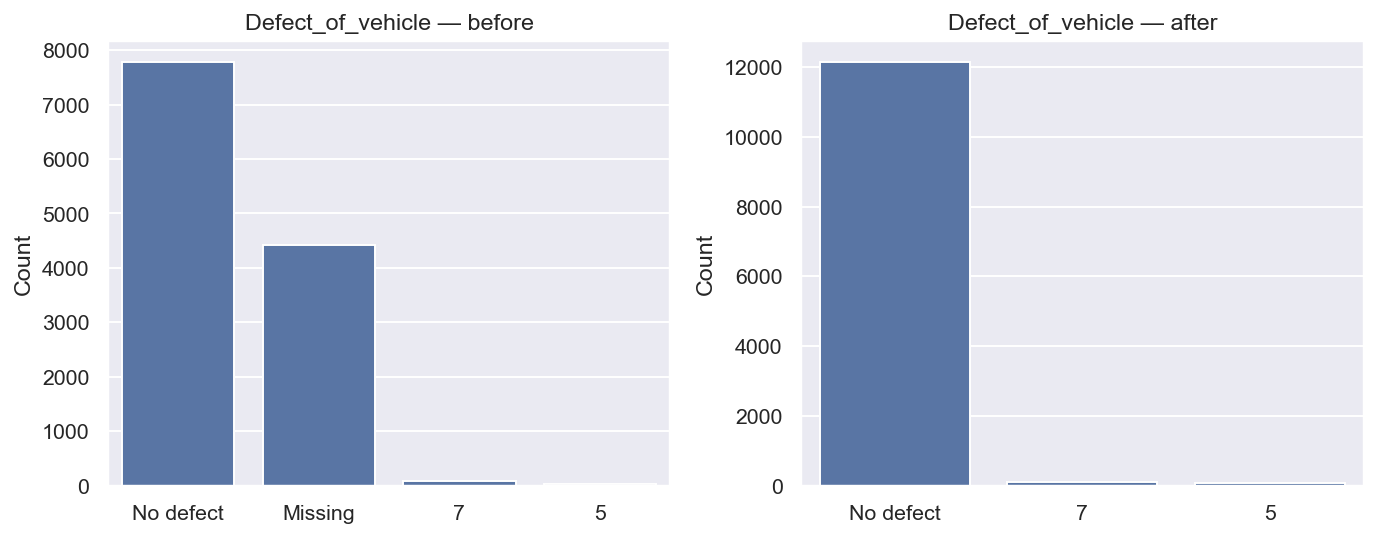

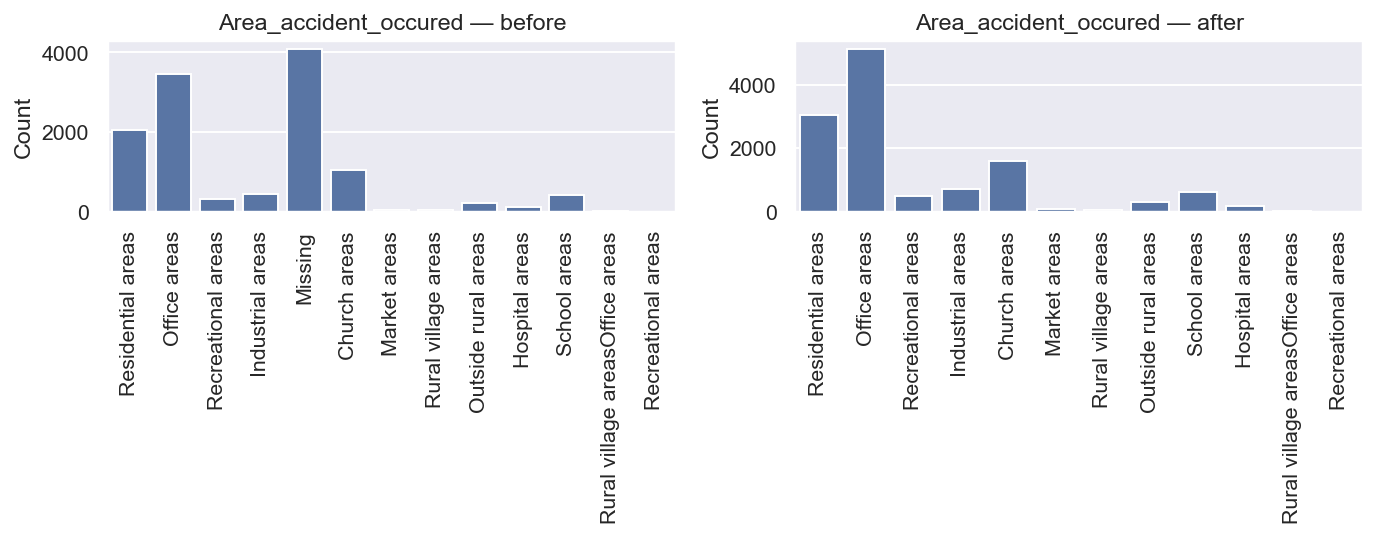

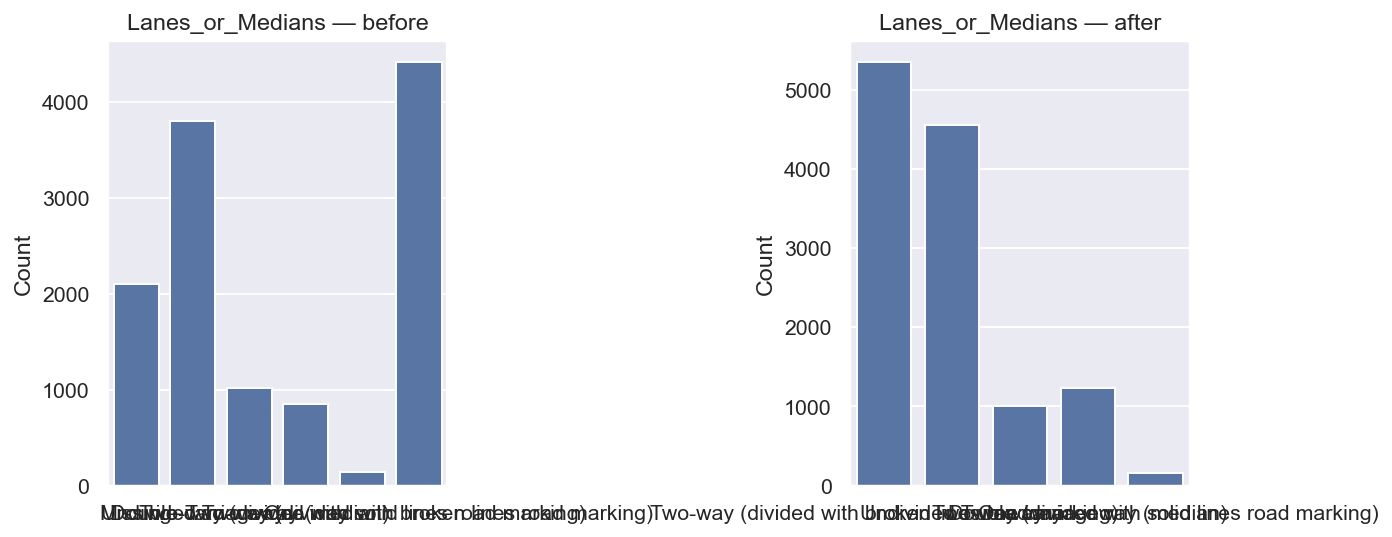

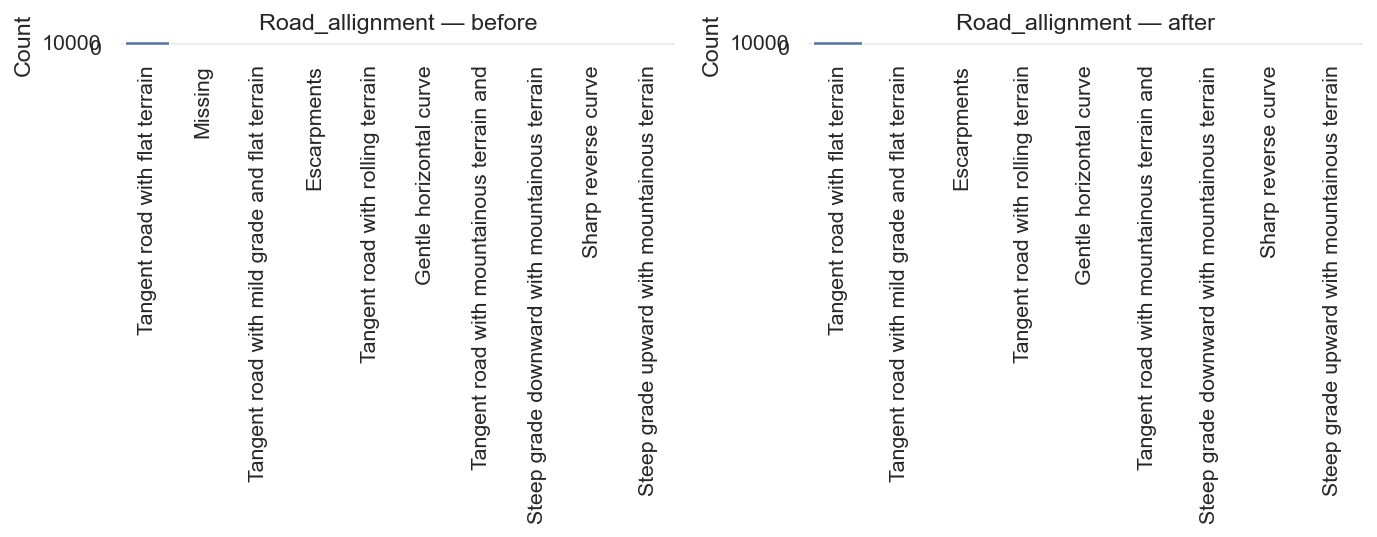

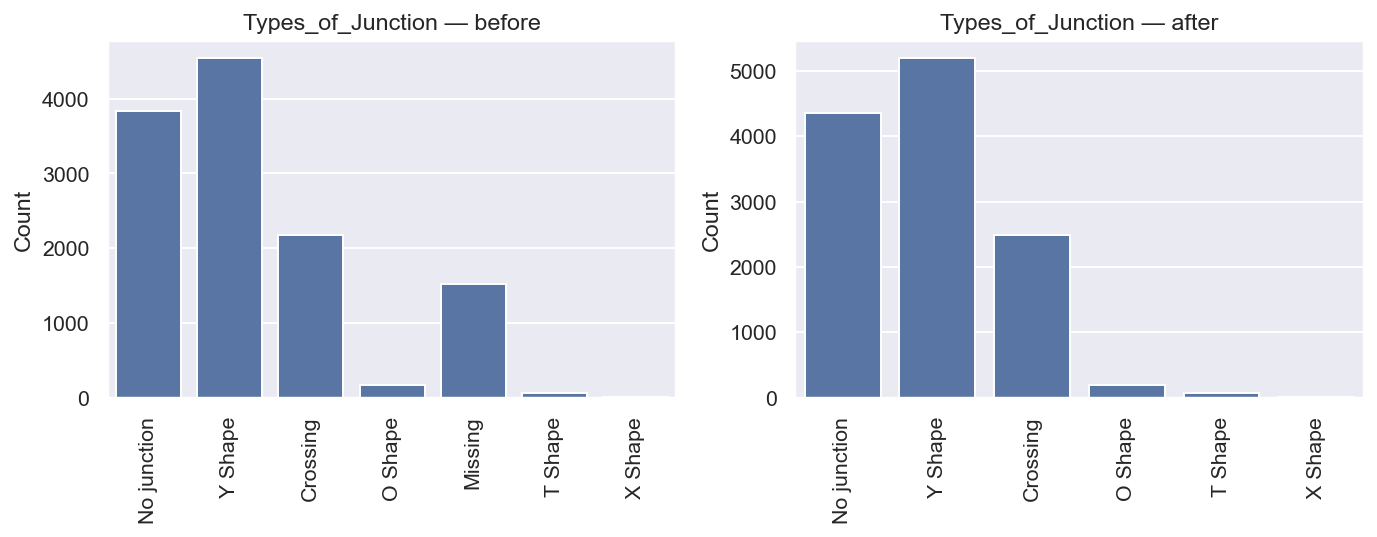

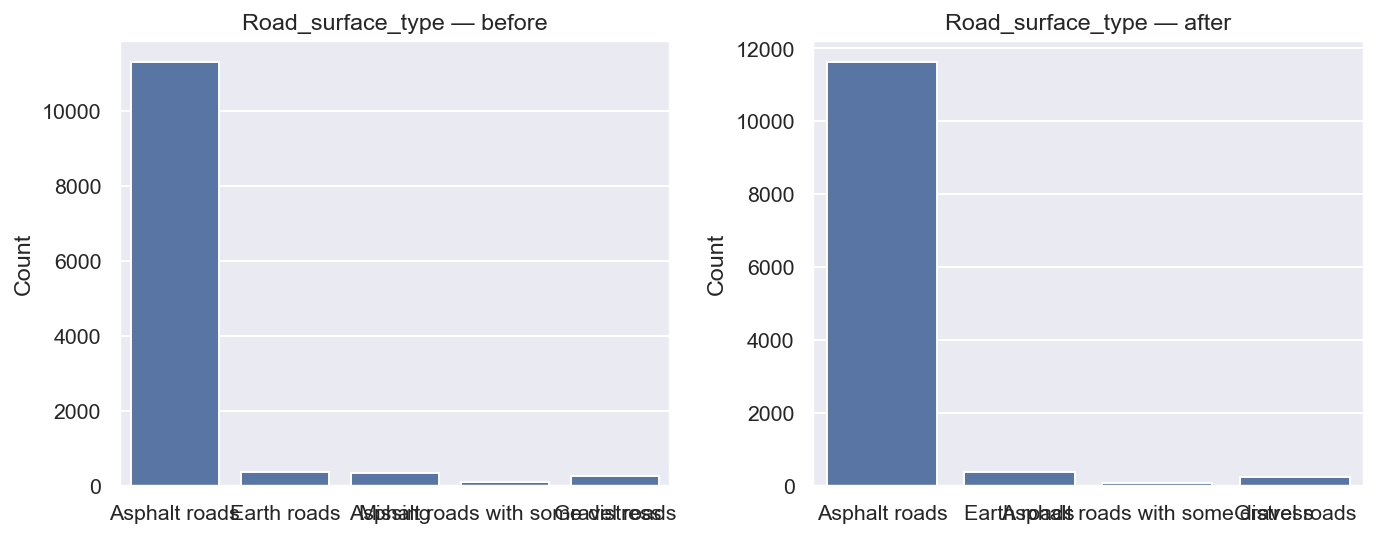

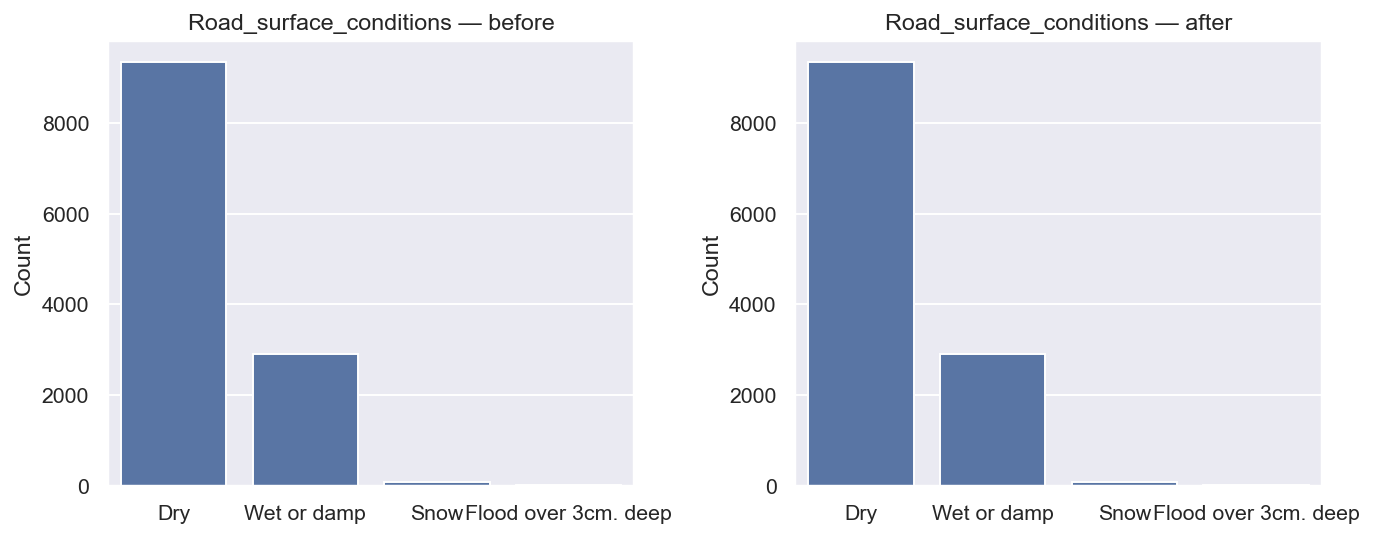

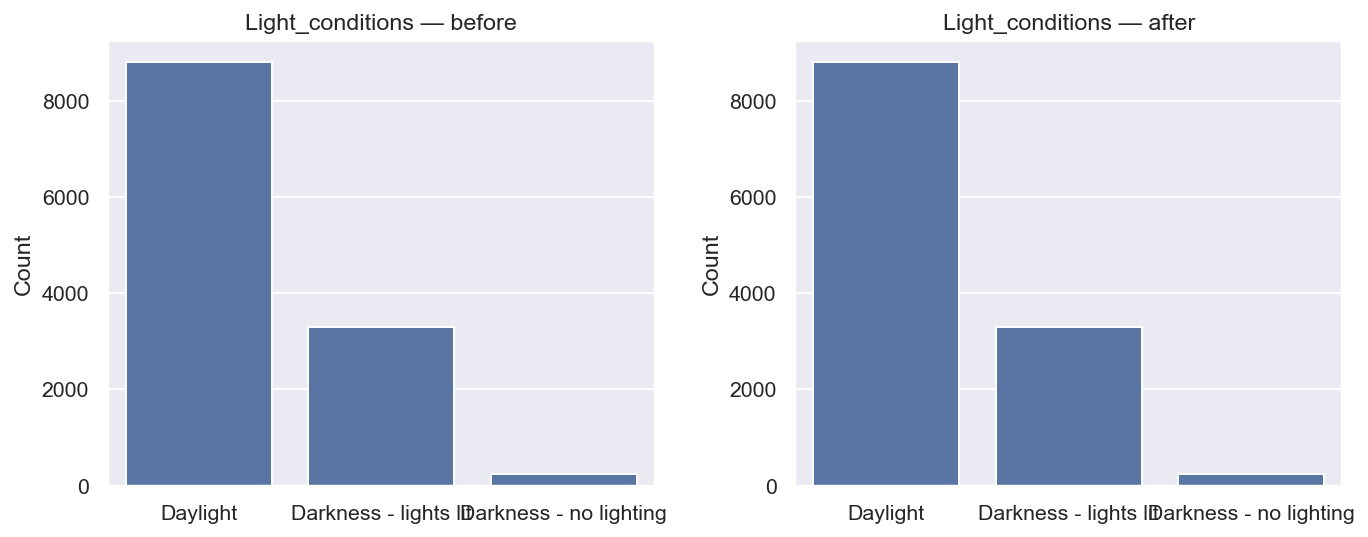

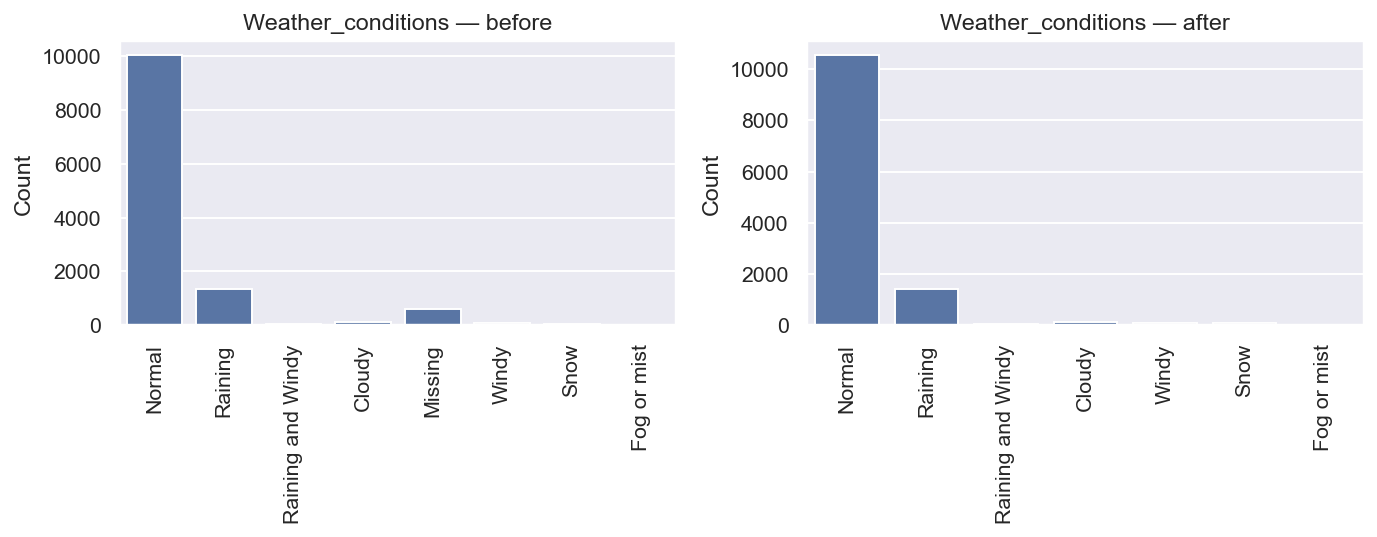

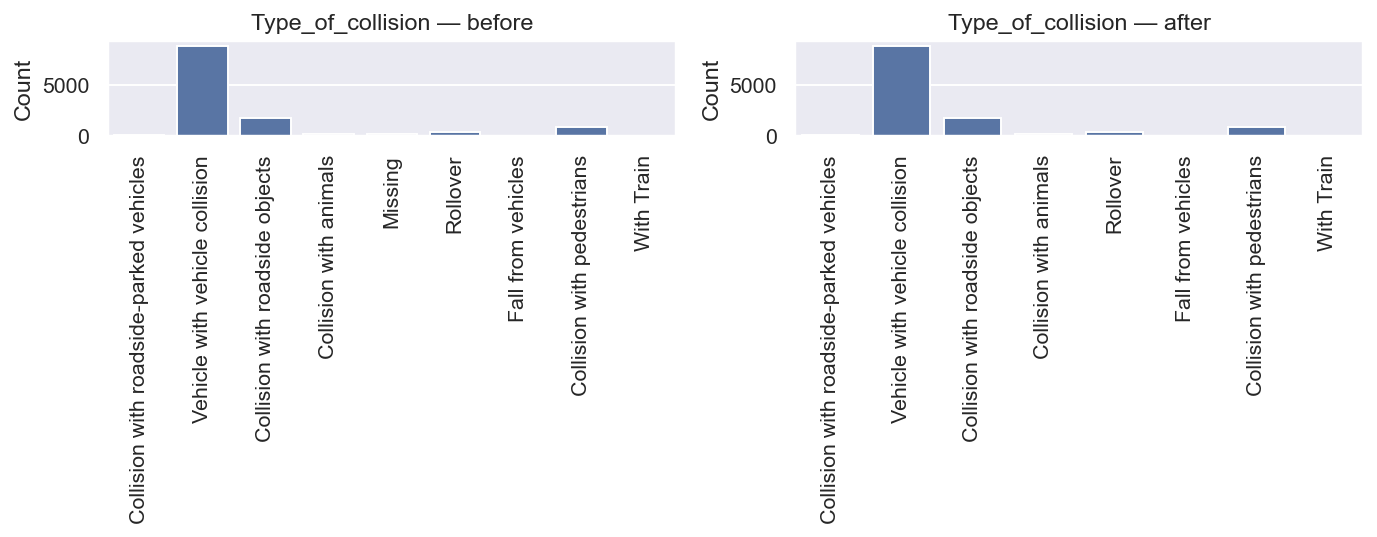

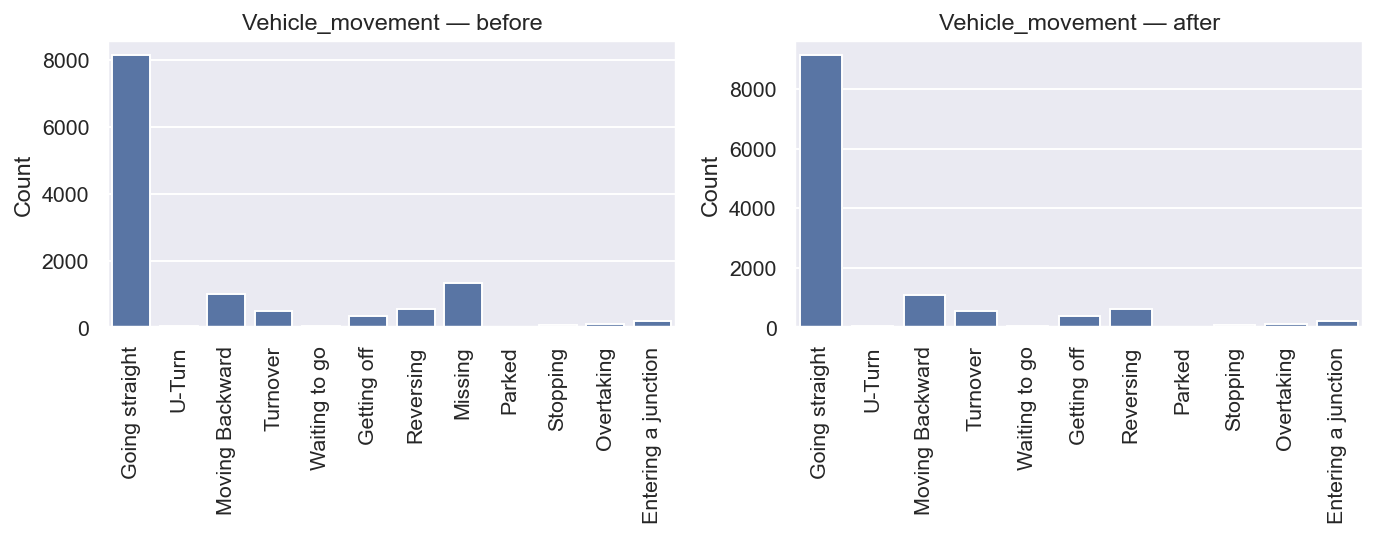

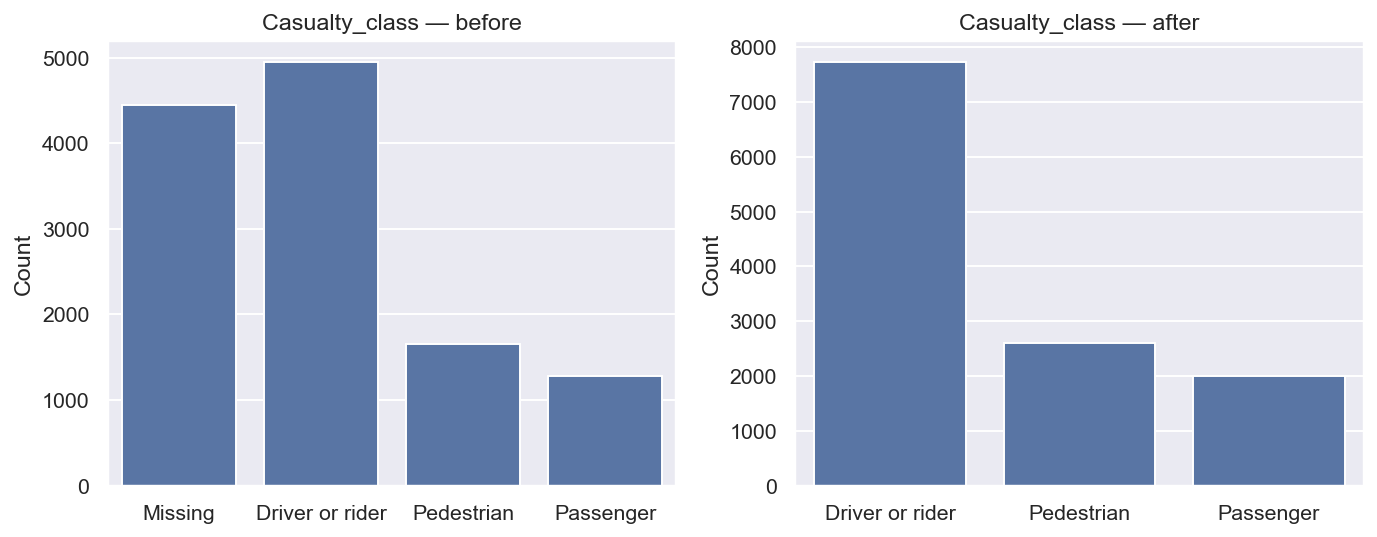

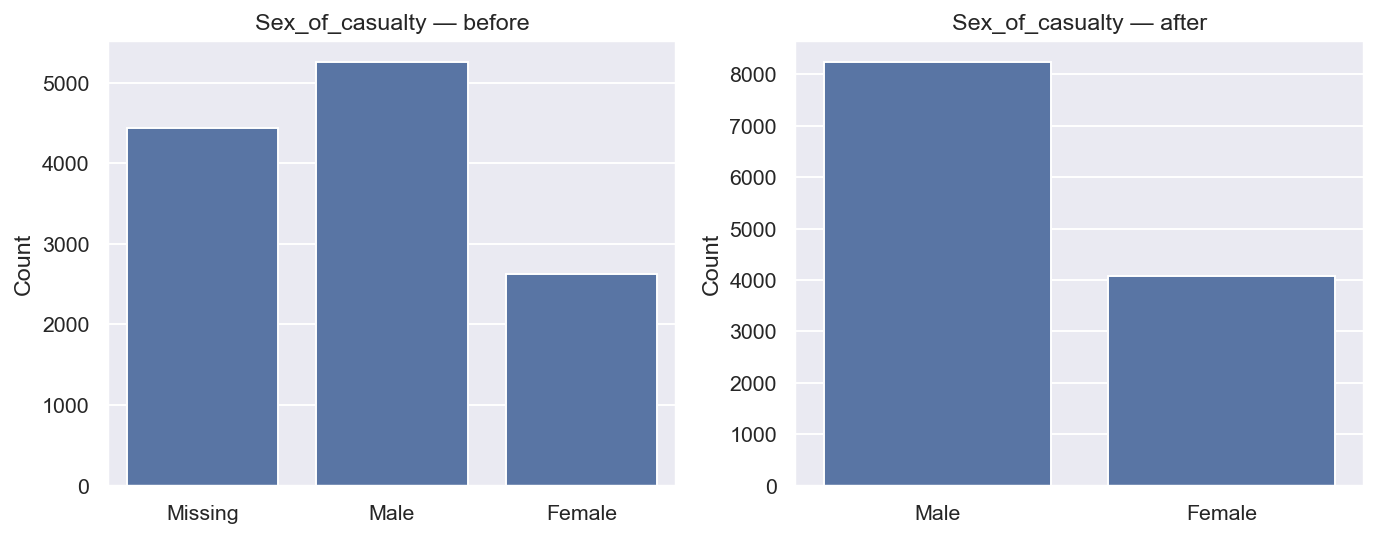

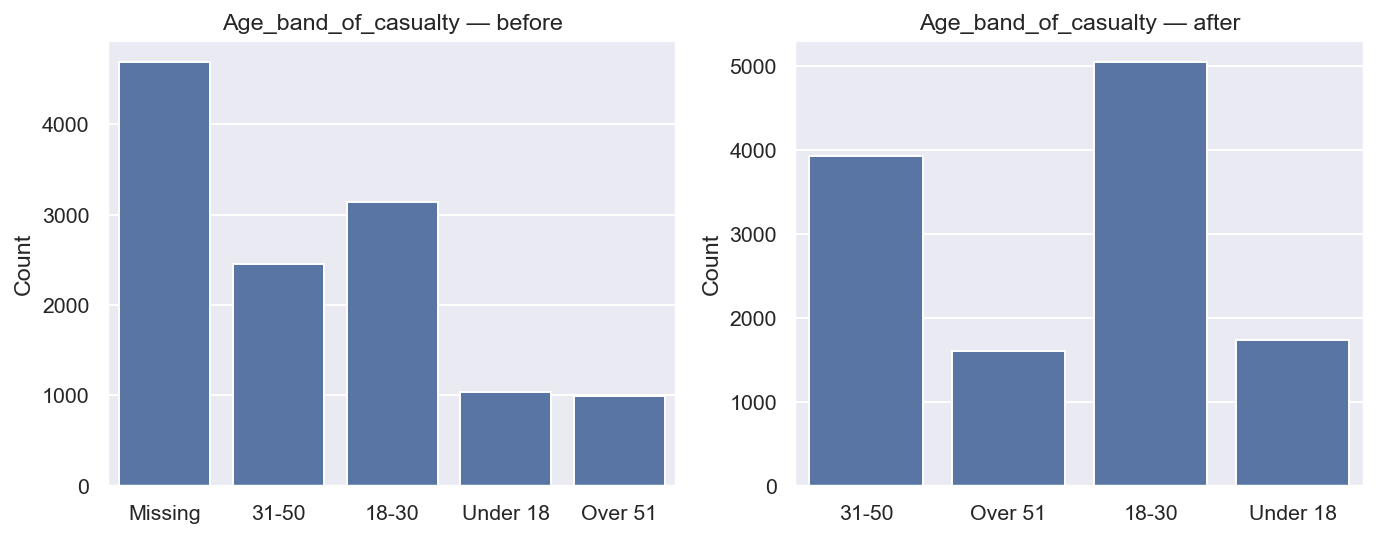

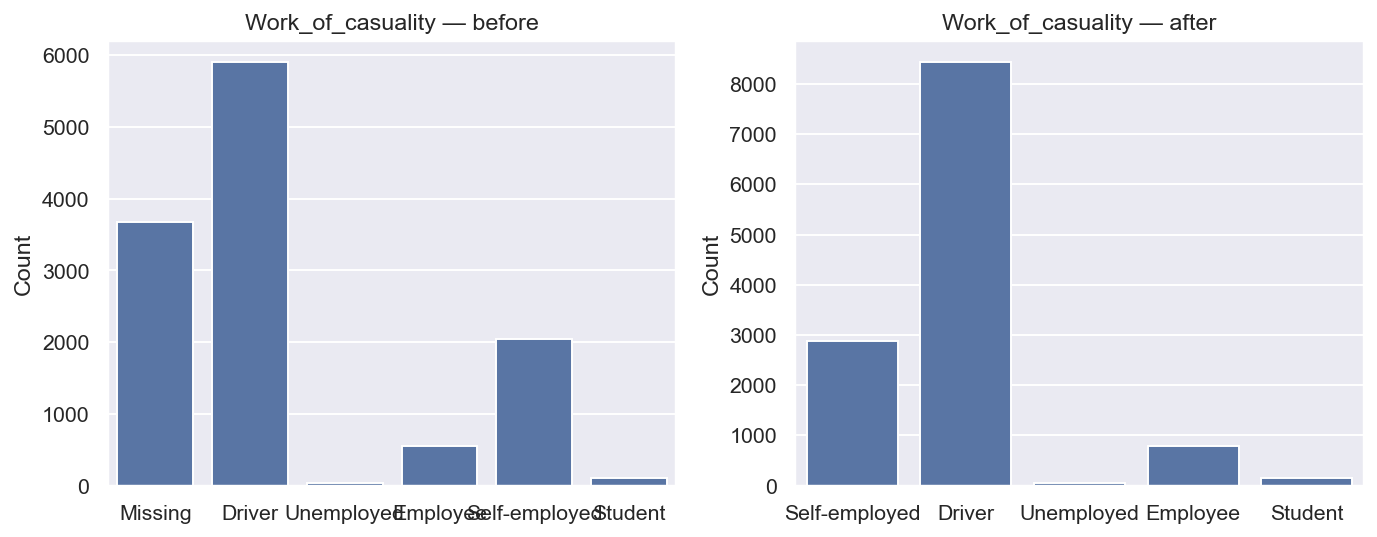

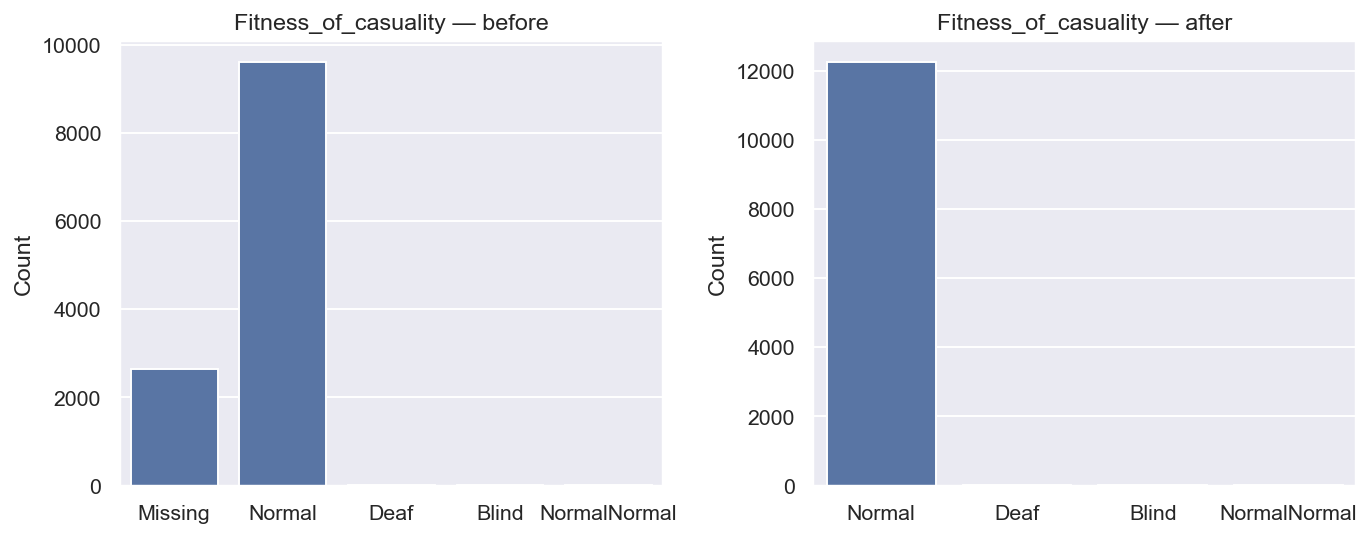

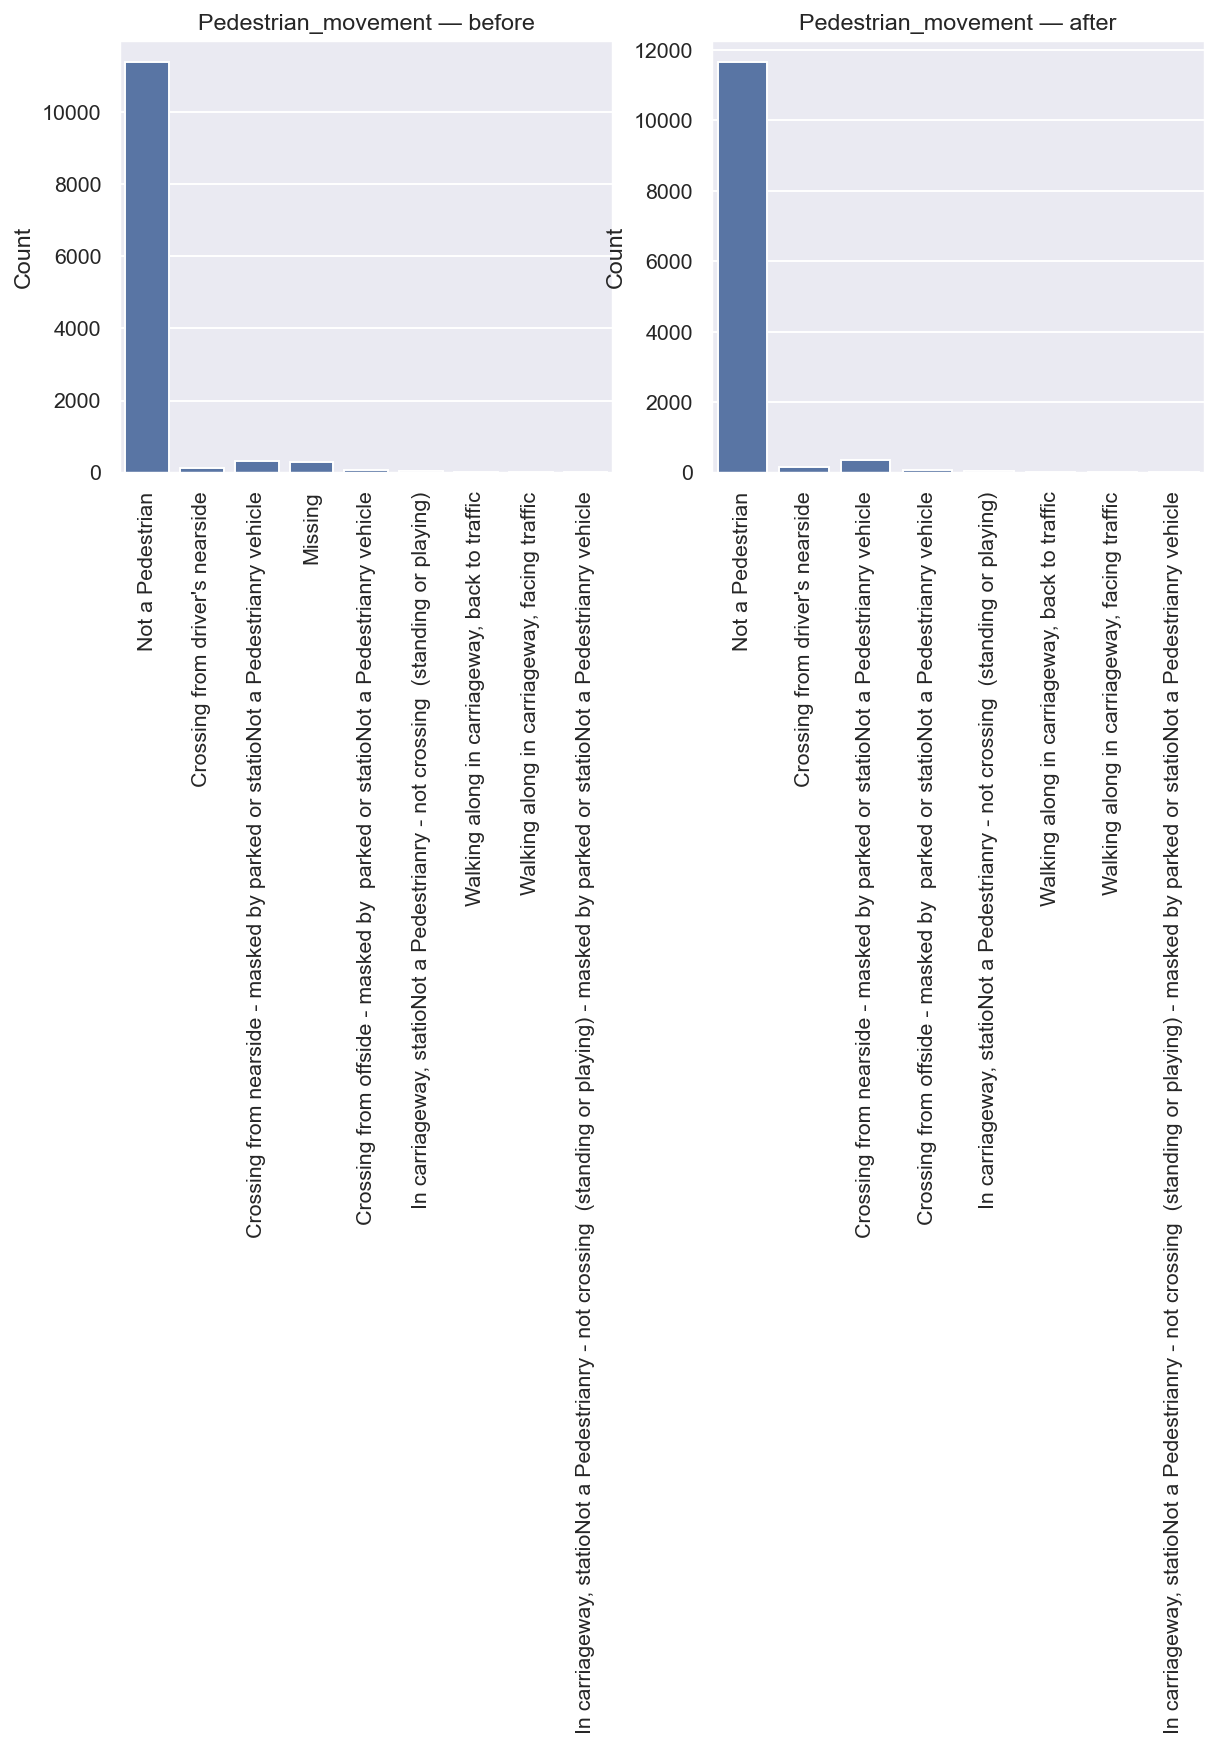

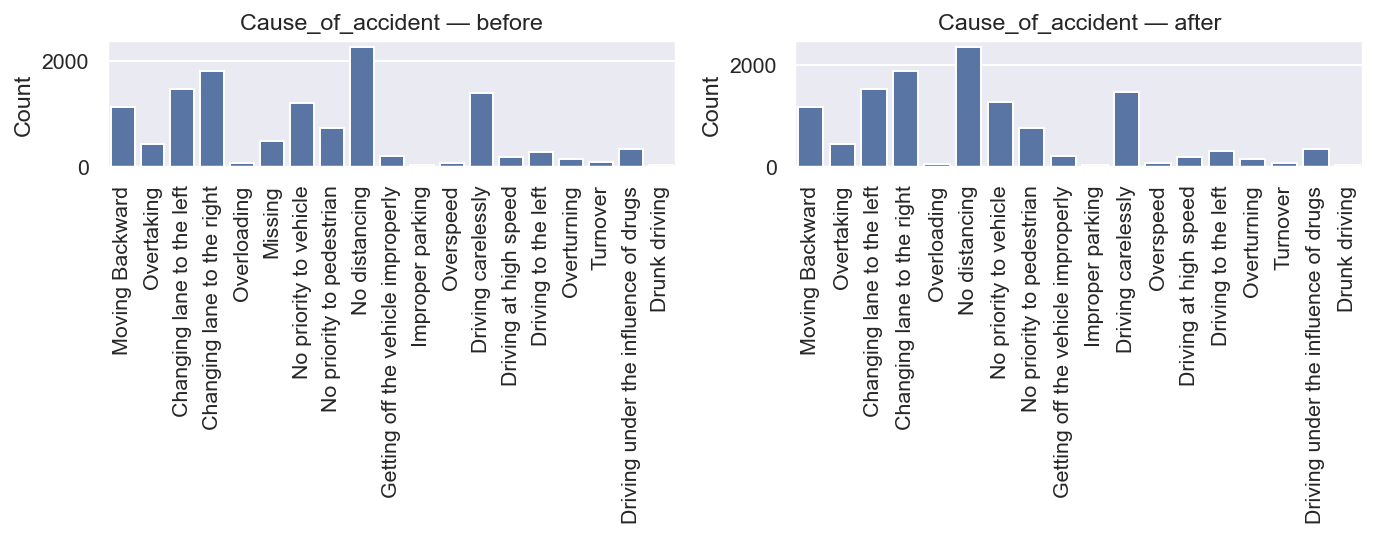

In [223]:
features_others = [c for c in data.columns if c not in [TARGET, "Time"]]
for feature in features_others:
    if data[feature].dtype == "O":  
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        sns.countplot(x=data[feature].fillna("Missing"),    ax=ax1)
        sns.countplot(x=data_imp[feature].fillna("Missing"), ax=ax2)
        ax1.set_title(f"{feature} — before")
        ax2.set_title(f"{feature} — after")
        for ax in (ax1, ax2):
            ax.set_xlabel("")
            ax.set_ylabel("Count")
            if data[feature].nunique(dropna=True) >= 6:
                for tick in ax.get_xticklabels():
                    tick.set_rotation(90)
        plt.tight_layout()
        plt.show()

In [224]:
data = data_imp
print("\nPost-imputation missing counts:")
print(data.isna().sum())
display(data.head())


Post-imputation missing counts:
Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,Day,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Driver or rider,Male,31-50,3.0,Self-employed,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,Day,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Driver or rider,Male,Over 51,3.0,Self-employed,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,Day,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Below 1yr,No defect,Recreational areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,Night,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Above 10yr,No defect,Office areas,Two-way (divided with broken lines road marking),Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,Night,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,No defect,Industrial areas,Undivided Two way,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Driver or rider,Male,18-30,3.0,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


In [225]:
SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
data["Accident_severity"] = data["Accident_severity"].astype(
    pd.CategoricalDtype(categories=SEVERITY_ORDER, ordered=True)
)

data_clean = data.copy()
data_clean.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,Day,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Driver or rider,Male,31-50,3.0,Self-employed,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,Day,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Driver or rider,Male,Over 51,3.0,Self-employed,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,Day,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Below 1yr,No defect,Recreational areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,Night,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Above 10yr,No defect,Office areas,Two-way (divided with broken lines road marking),Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,Night,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,No defect,Industrial areas,Undivided Two way,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Driver or rider,Male,18-30,3.0,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


## 3.3 Categorical data encoding

- **Ordinals** → manual codes (fixed, human-ordered): `Time`, age bands, education, driving experience, service years, light conditions, casualty age/severity.
- **Nominals** → label encoding (compact, one column each). We store encoders for later use.

Notes:
- Any unexpected value in an ordinal column is mapped to `10` (“other/unknown” bucket).
- We keep the target `Accident_severity` as labels for now (will encode only right before modeling).
- After encoding, we visualize per-feature counts by severity (no empty-figure spam), then check a **Spearman** correlation heatmap and drop a few highly redundant casualty fields.


In [226]:
TARGET = "Accident_severity"
SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]

In [227]:
numerical_cols = ["Number_of_vehicles_involved", "Number_of_casualties"]
ordinal_cols = [
    "Time", "Age_band_of_driver", "Educational_level",
    "Driving_experience", "Service_year_of_vehicle",
    "Light_conditions", "Age_band_of_casualty", "Casualty_severity", 
]
nominal_cols = [c for c in data.columns if c not in numerical_cols + ordinal_cols + [TARGET]]

In [228]:
Time_dict = {"Day": 0, "Night": 1}

In [229]:
Age_band_of_driver_dict = {
    "Under 18": 1, "18-30": 2, "31-50": 3, "Over 51": 4, "unknown": 10,
}

In [230]:
Educational_level_dict = {
    "Illiterate": 1, "Writing & reading": 2, "Elementary school": 3,
    "Junior high school": 4, "High school": 5, "Above high school": 6, "unknown": 10
}

In [231]:
Driving_experience_dict = {
    "No Licence": 0, "Below 1yr": 1, "1-2yr": 2, "2-5yr": 3, "5-10yr": 4, "Above 10yr": 5, "unknown": 10
}

In [232]:
Service_year_of_vehicle_dict = {
    "Below 1yr": 1, "1-2yr": 2, "2-5yrs": 3, "5-10yrs": 4, "Above 10yr": 5, "unknown": 10
}

In [233]:
Light_conditions_dict = {"Darkness - no lighting": 1, "Darkness - lights lit": 2, "Daylight": 3}

In [234]:
Age_band_of_casualty_dict = {"Under 18": 1, "18-30": 2, "31-50": 3, "Over 51": 4, "na": 10, "unknown": 10}

In [235]:
Casualty_severity_dict = {1: 1, 2: 2, 3: 3, "1": 1, "2": 2, "3": 3, "na": 10, "unknown": 10}

In [236]:
manual_encoder_dict = {
    "Time": Time_dict,
    "Age_band_of_driver": Age_band_of_driver_dict,
    "Educational_level": Educational_level_dict,
    "Driving_experience": Driving_experience_dict,
    "Service_year_of_vehicle": Service_year_of_vehicle_dict,
    "Light_conditions": Light_conditions_dict,
    "Age_band_of_casualty": Age_band_of_casualty_dict,
    "Casualty_severity": Casualty_severity_dict,
}

In [237]:
def manual_encoder(df: pd.DataFrame, cols: list[str], mapping: dict[str, dict]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = out[col].map(mapping[col]).fillna(10).astype(int)  # 10 = other/unknown
    return out

In [238]:
data_enc = manual_encoder(data, ordinal_cols, manual_encoder_dict)


In [239]:
saved_dict = {}

def label_encode_nominals(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        print(f"Encoding {col}")
        le = LabelEncoder()
        out[col] = le.fit_transform(out[col].astype(str))
        saved_dict[f"le_{col}"] = le
    return out

In [240]:
data_enc = label_encode_nominals(data_enc, nominal_cols)


Encoding Day_of_week
Encoding Sex_of_driver
Encoding Vehicle_driver_relation
Encoding Type_of_vehicle
Encoding Owner_of_vehicle
Encoding Defect_of_vehicle
Encoding Area_accident_occured
Encoding Lanes_or_Medians
Encoding Road_allignment
Encoding Types_of_Junction
Encoding Road_surface_type
Encoding Road_surface_conditions
Encoding Weather_conditions
Encoding Type_of_collision
Encoding Vehicle_movement
Encoding Casualty_class
Encoding Sex_of_casualty
Encoding Work_of_casuality
Encoding Fitness_of_casuality
Encoding Pedestrian_movement
Encoding Cause_of_accident


In [241]:
display(data_enc.head())


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,0,1,2,1,6,0,2,0,2,5,2,8,2,5,1,0,0,3,2,3,2,2,2,0,1,3,3,2,2,5,9,Slight Injury
1,0,1,3,1,4,0,5,10,2,4,2,6,4,5,1,0,0,3,2,6,2,2,2,0,1,4,3,2,2,5,15,Slight Injury
2,0,1,2,1,4,0,2,5,2,1,2,1,2,5,1,0,0,3,2,2,2,2,2,0,1,3,3,0,2,5,0,Serious Injury
3,1,3,2,1,4,0,4,10,0,5,2,6,2,6,5,2,0,2,2,6,2,2,2,2,0,2,3,0,2,5,1,Slight Injury
4,1,3,2,1,4,0,3,0,2,4,2,4,4,5,5,0,0,2,2,6,2,2,2,0,1,2,3,0,2,5,15,Slight Injury


In [242]:
def facet_counts(df, feature):
    g = sns.catplot(
        data=df,
        x=feature,
        col=TARGET,
        col_order=SEVERITY_ORDER,
        kind="count",
        sharey=False,
        height=3.5,
        aspect=1.2,
    )
    if df[feature].nunique() >= 6:
        g.set_xticklabels(rotation=90)
    g.set_xlabels("")
    g.set_ylabels("Count")
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.82)
    g.fig.suptitle(f"Frequency distribution of {feature} by target class")
    plt.show()

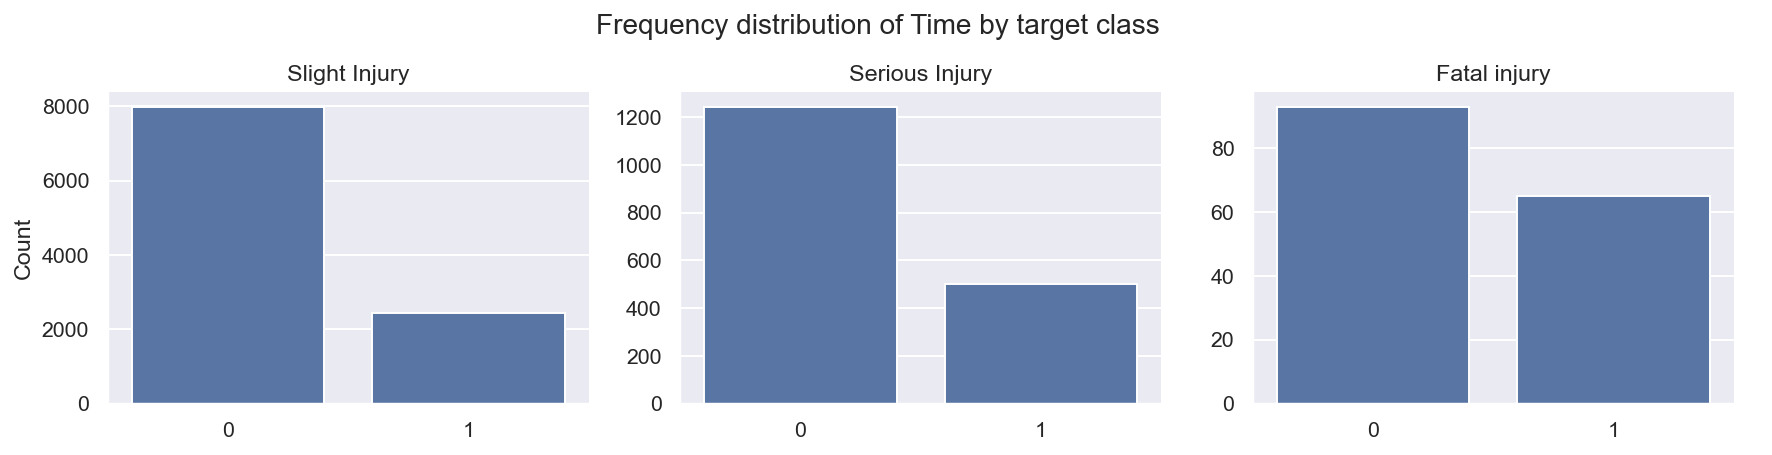

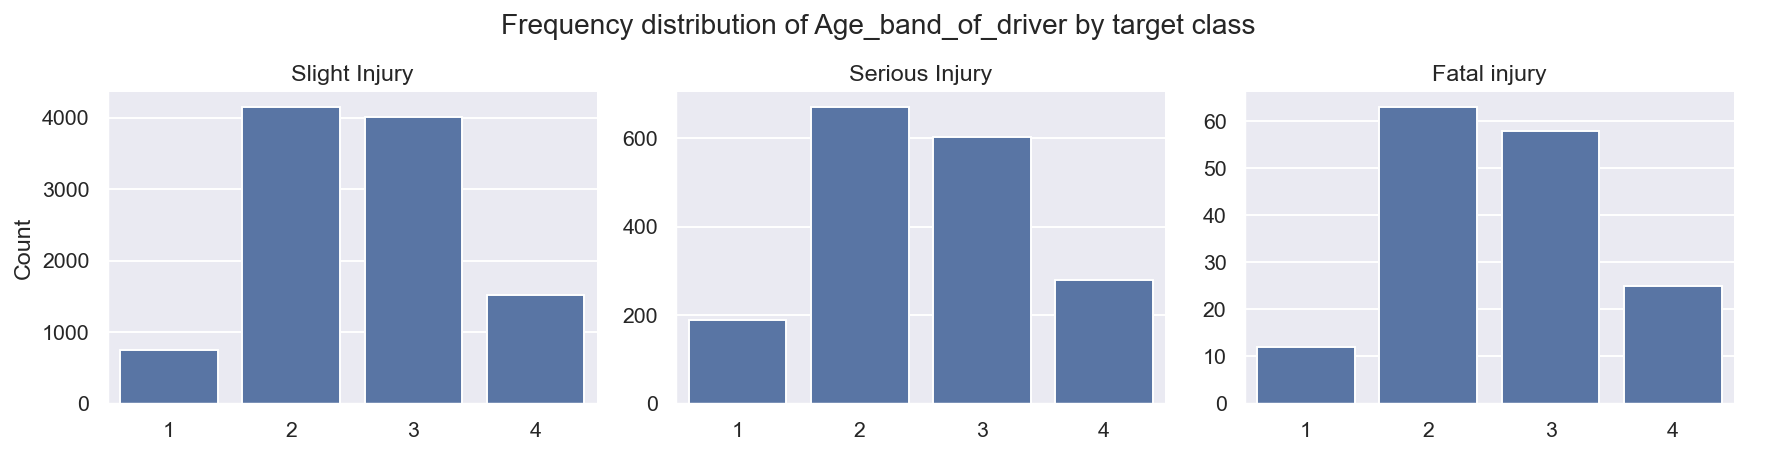

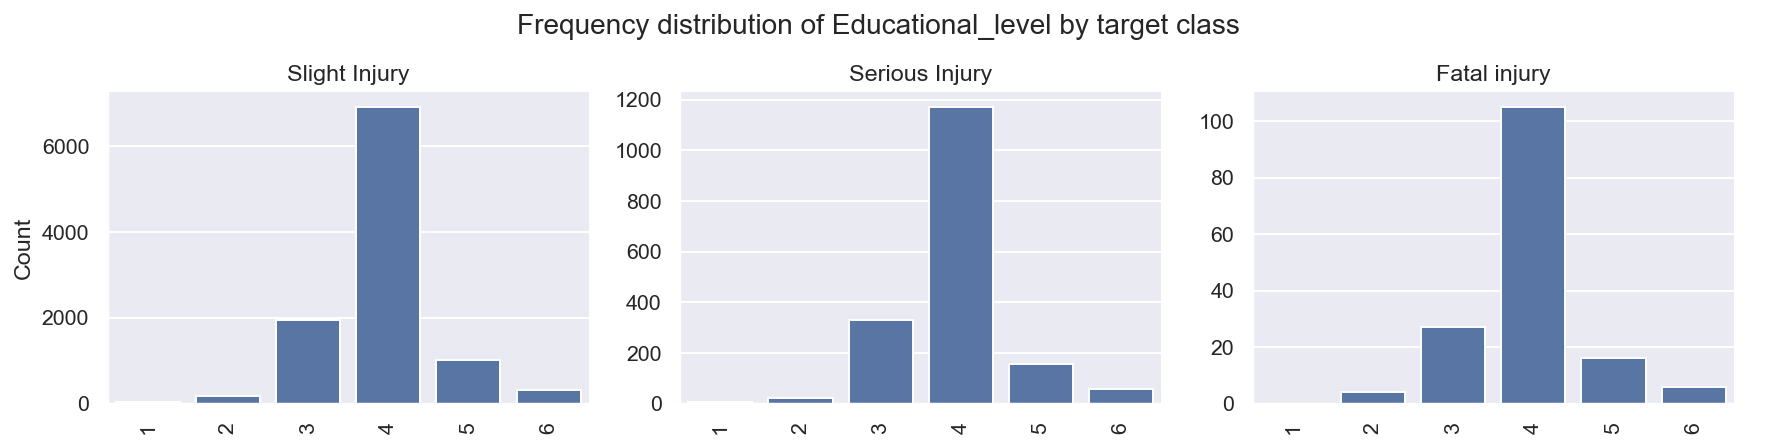

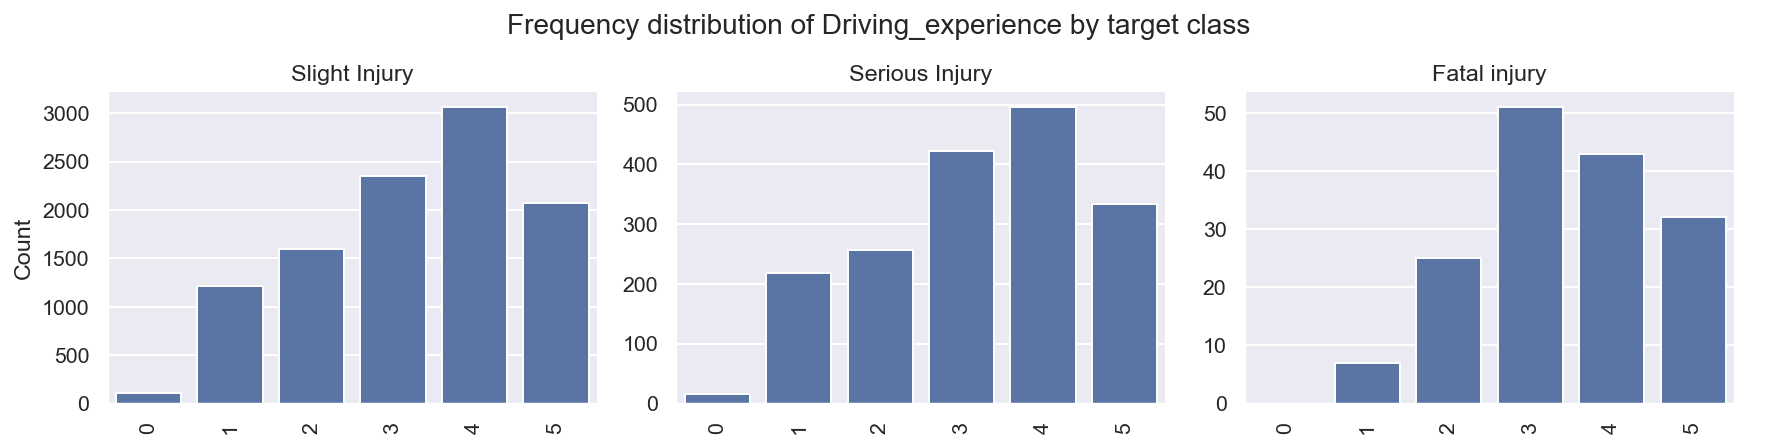

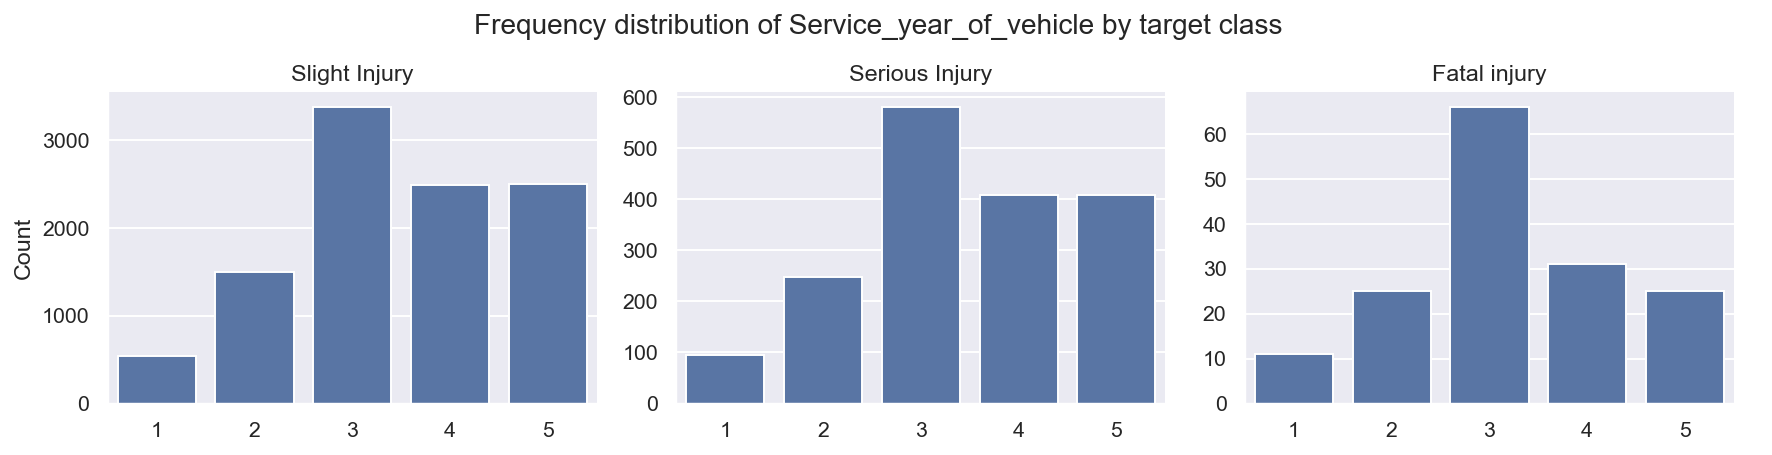

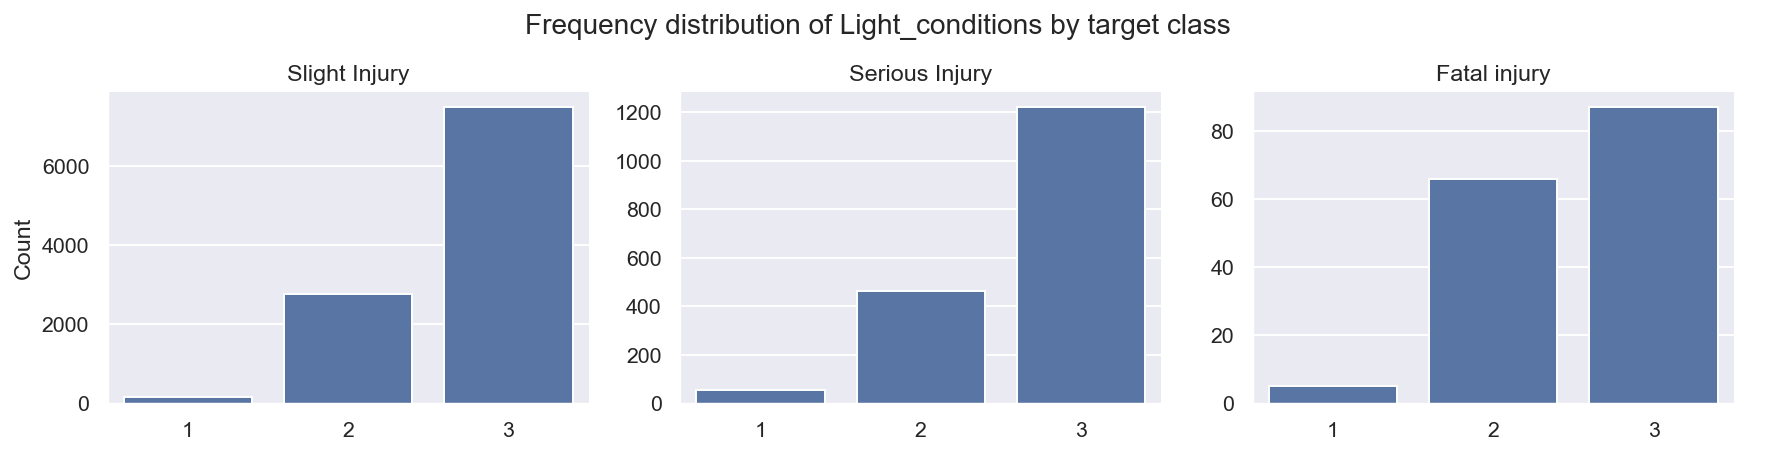

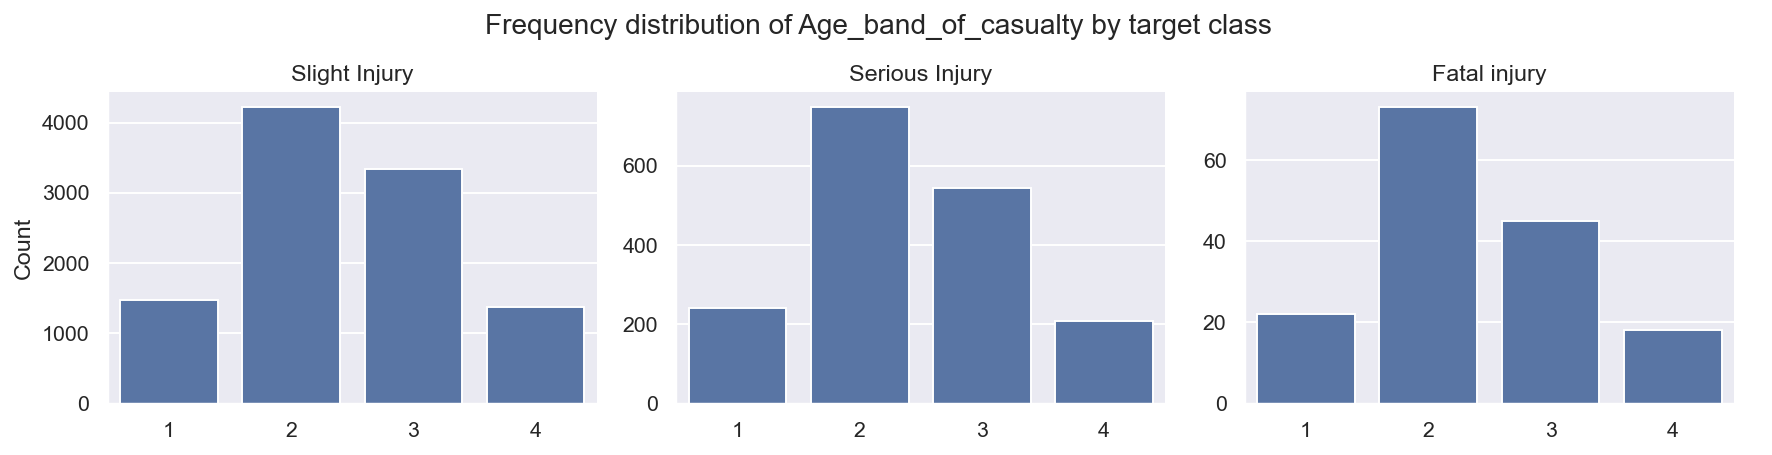

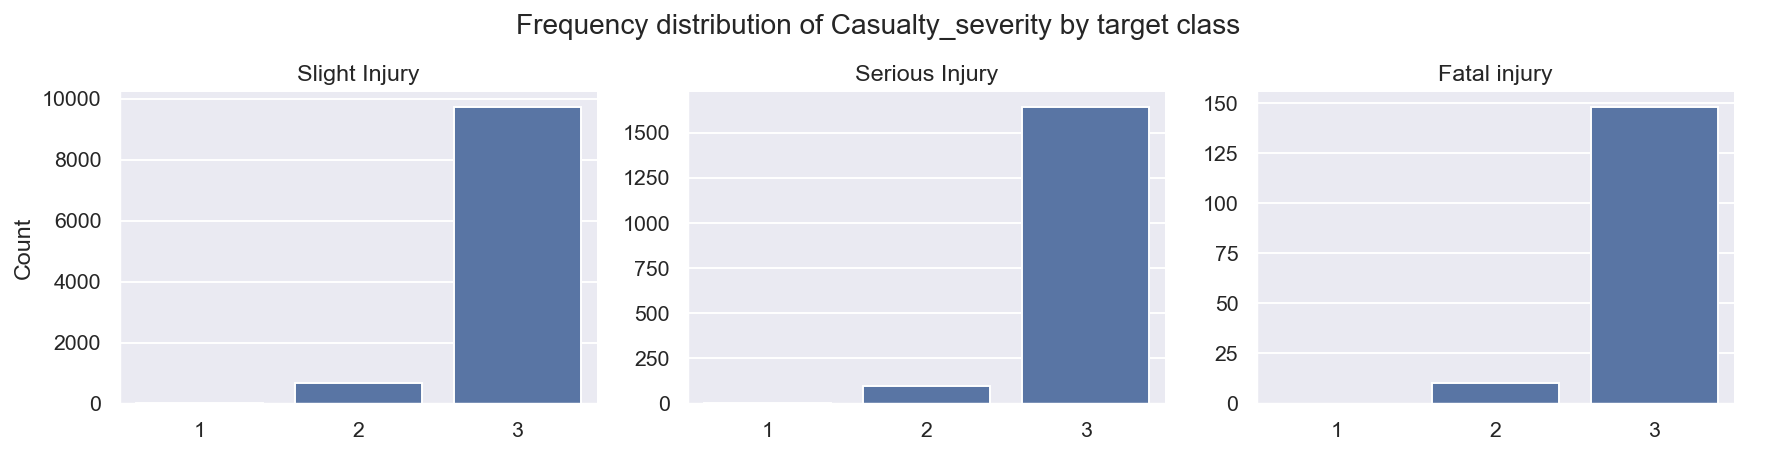

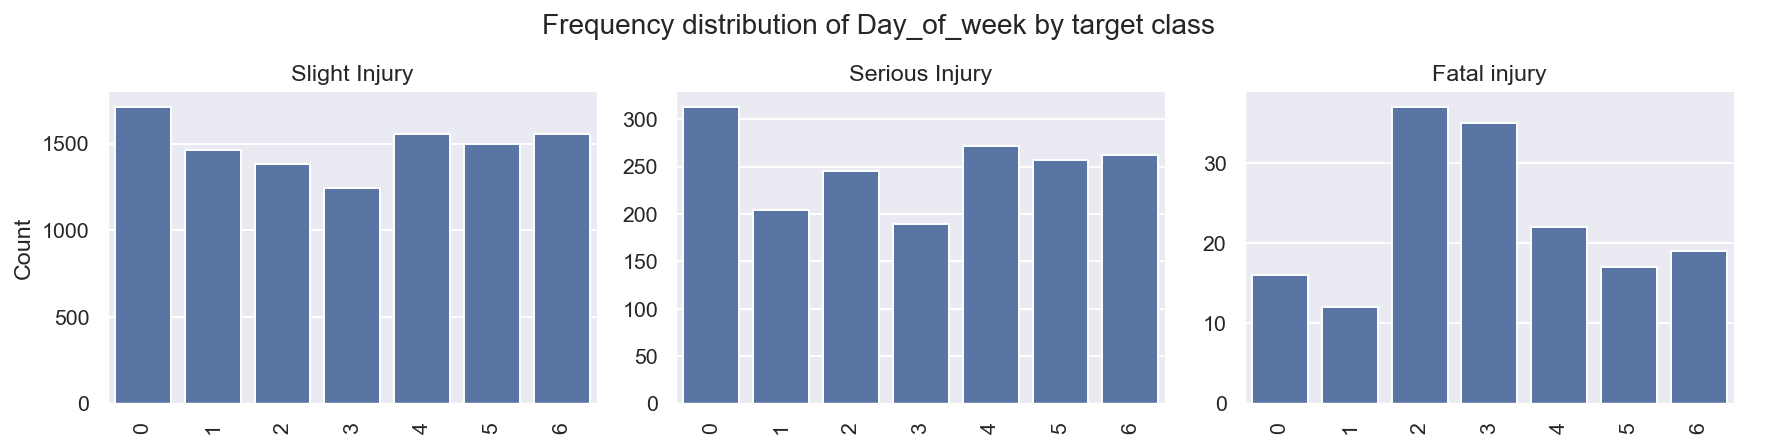

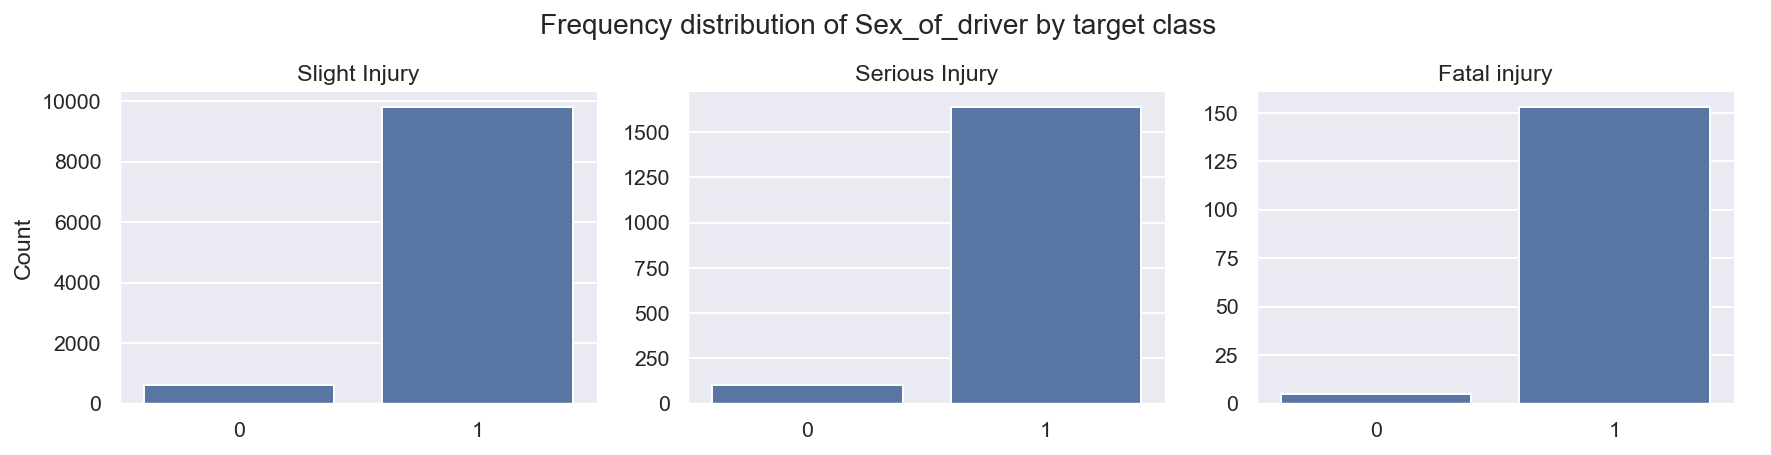

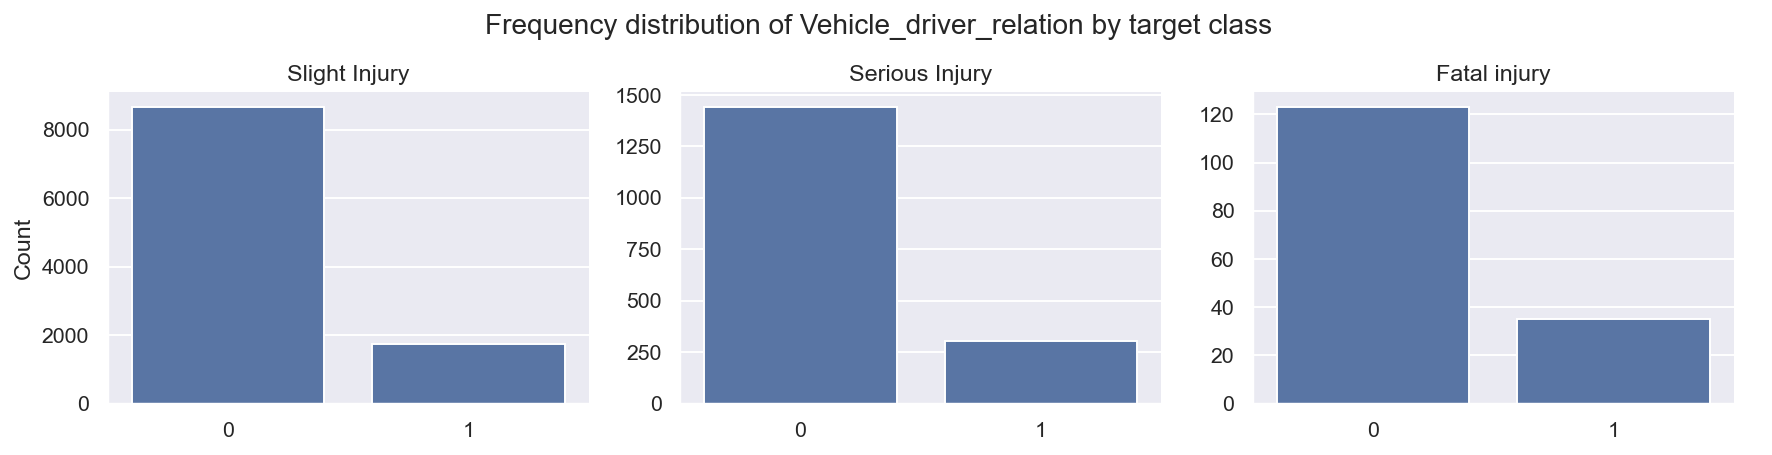

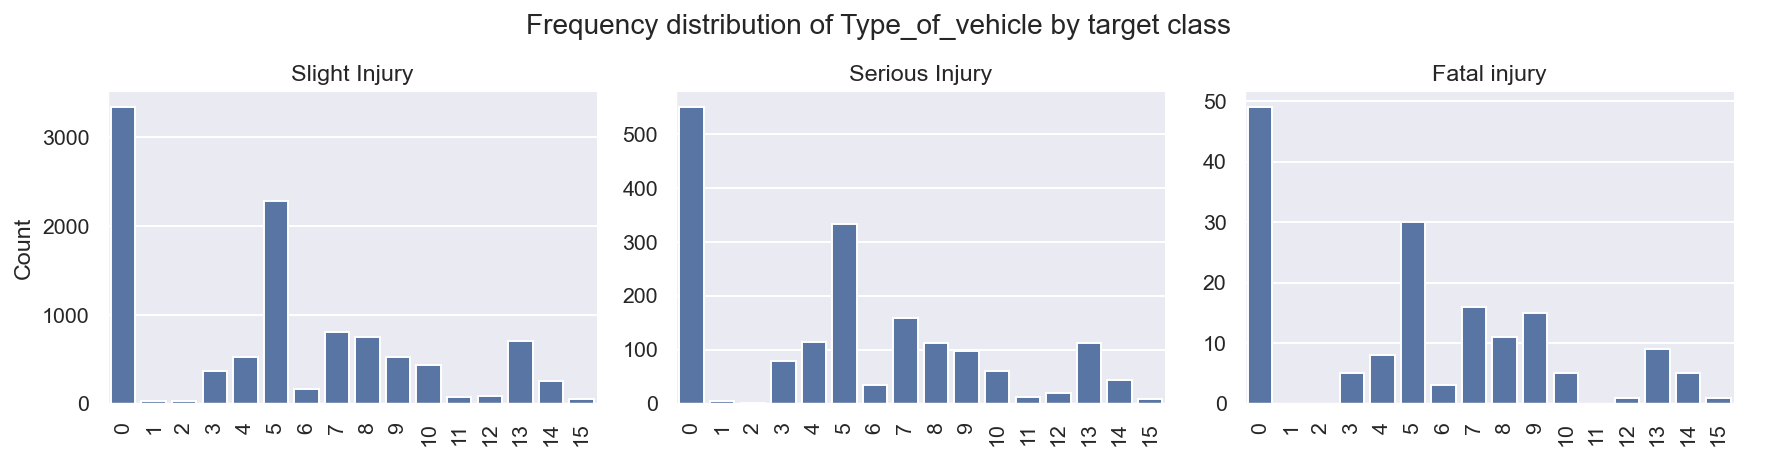

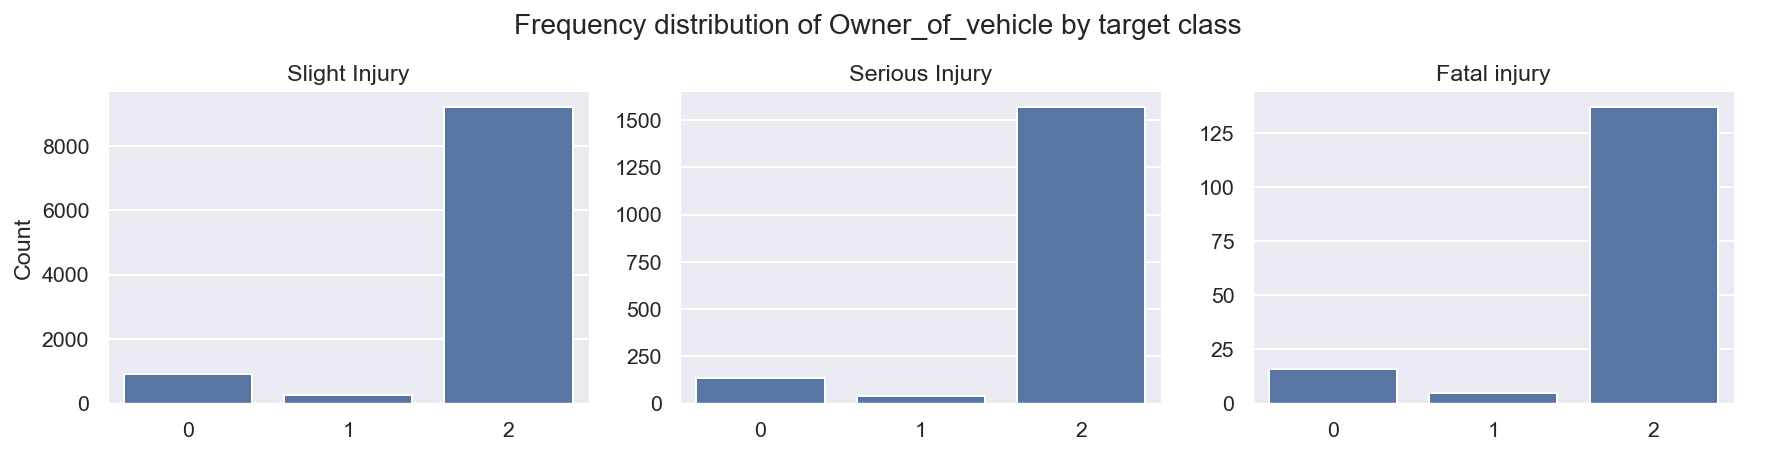

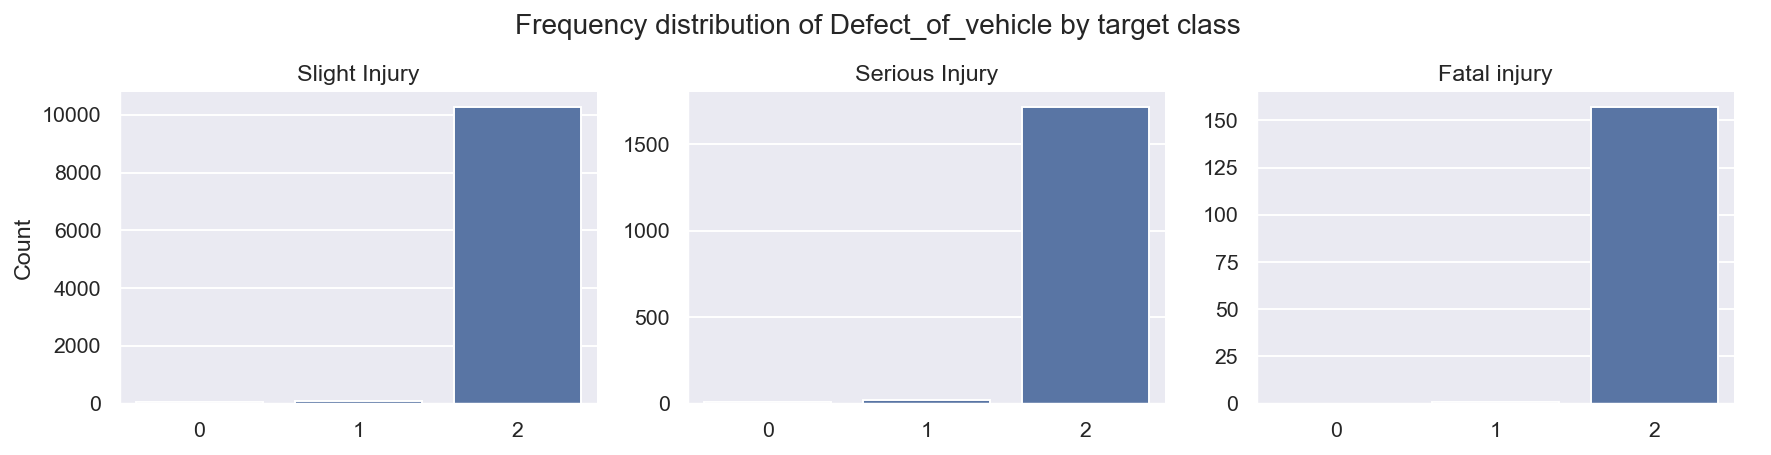

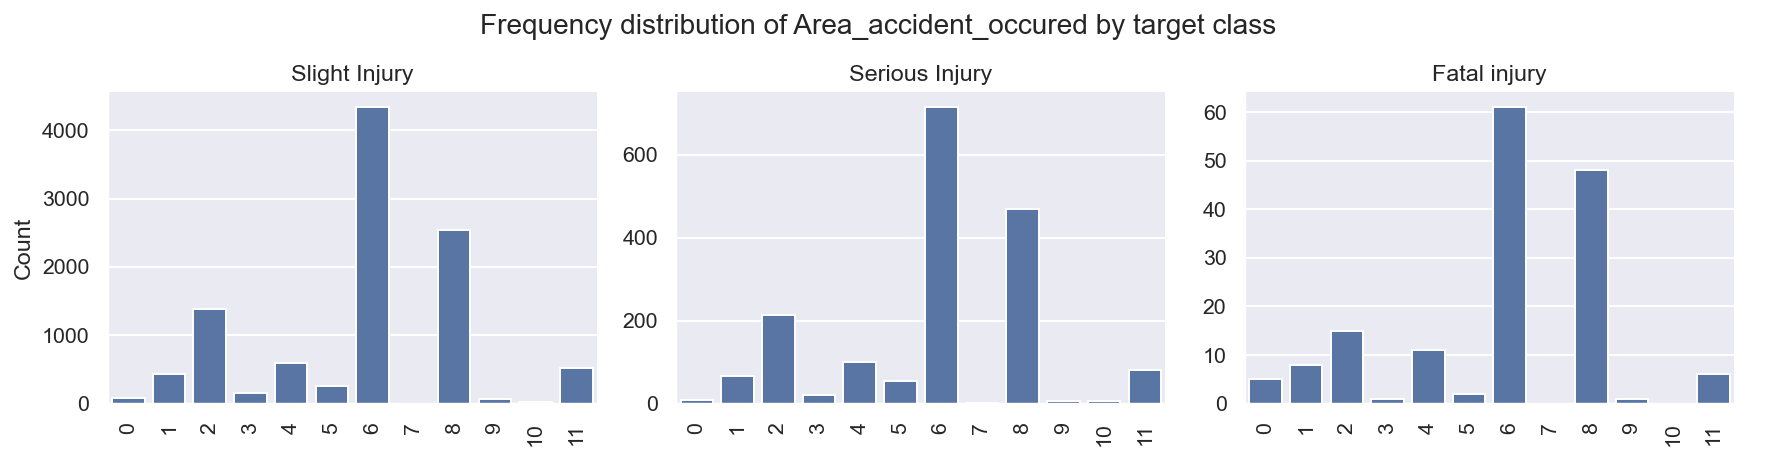

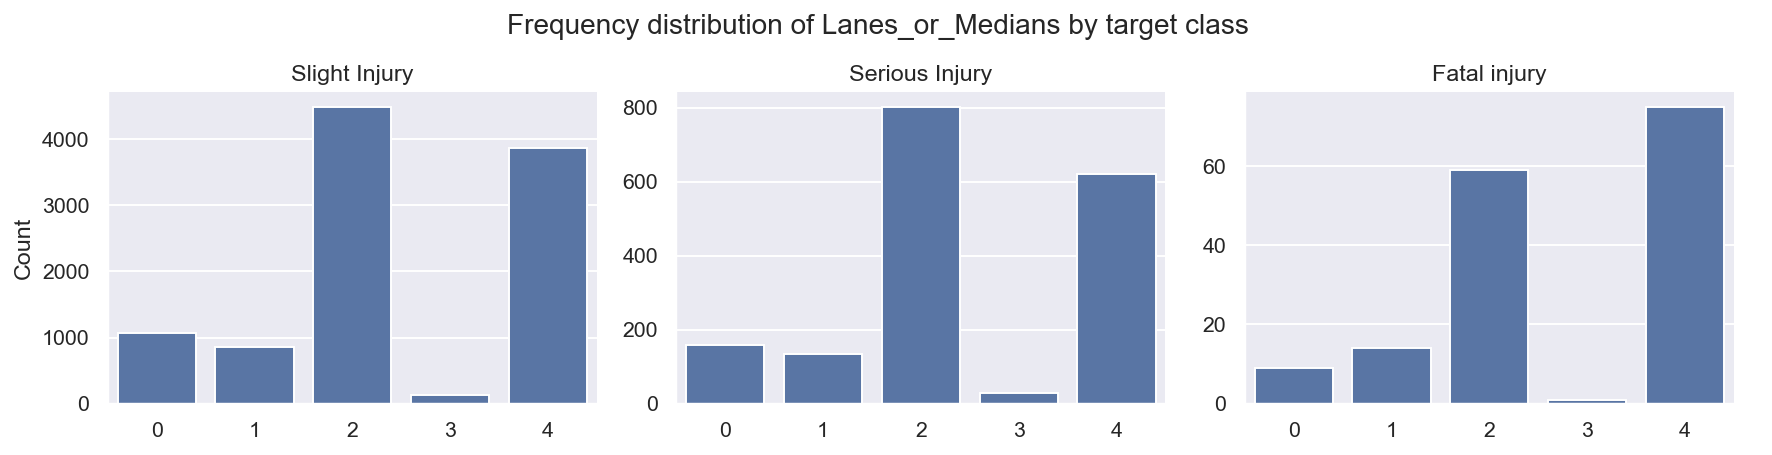

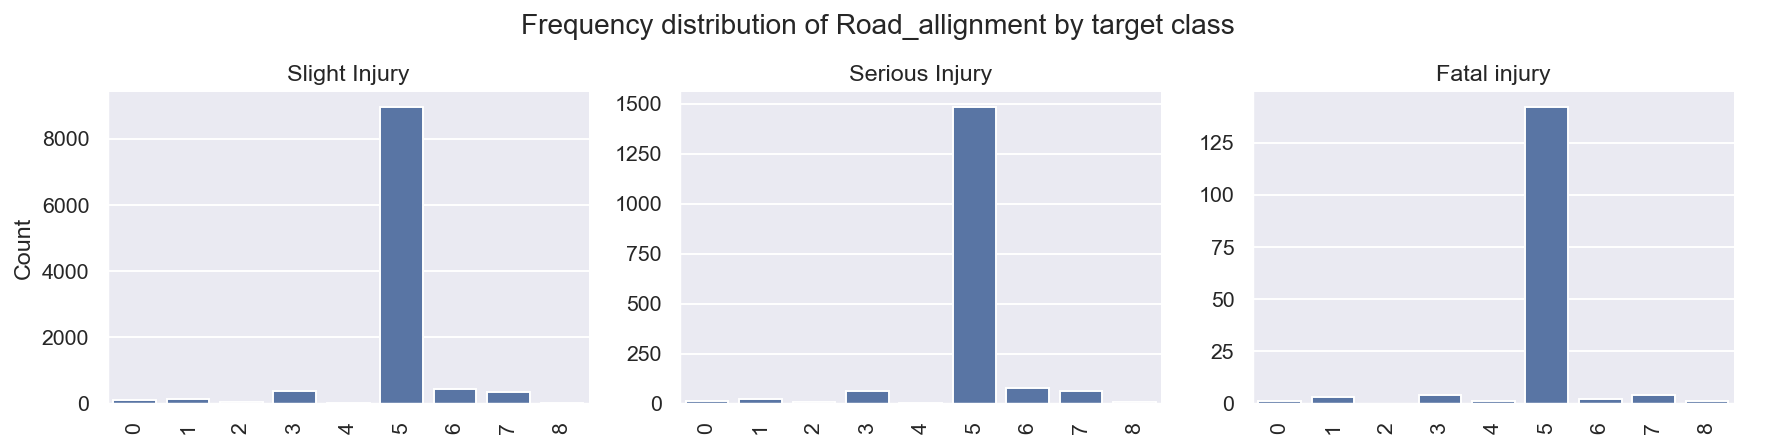

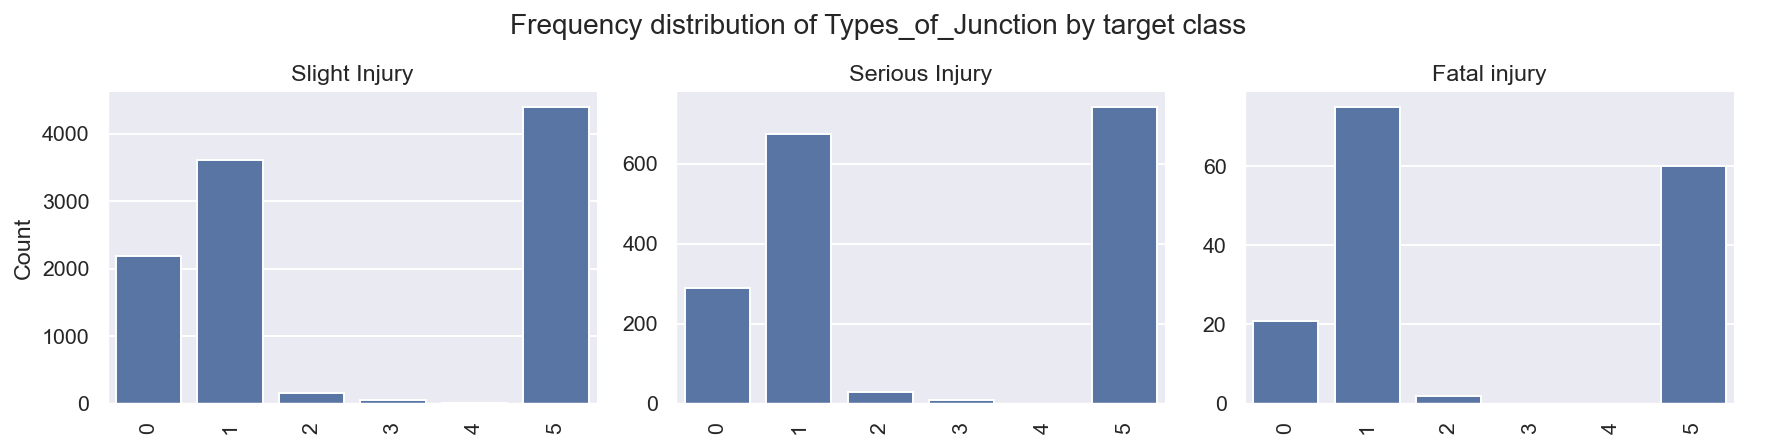

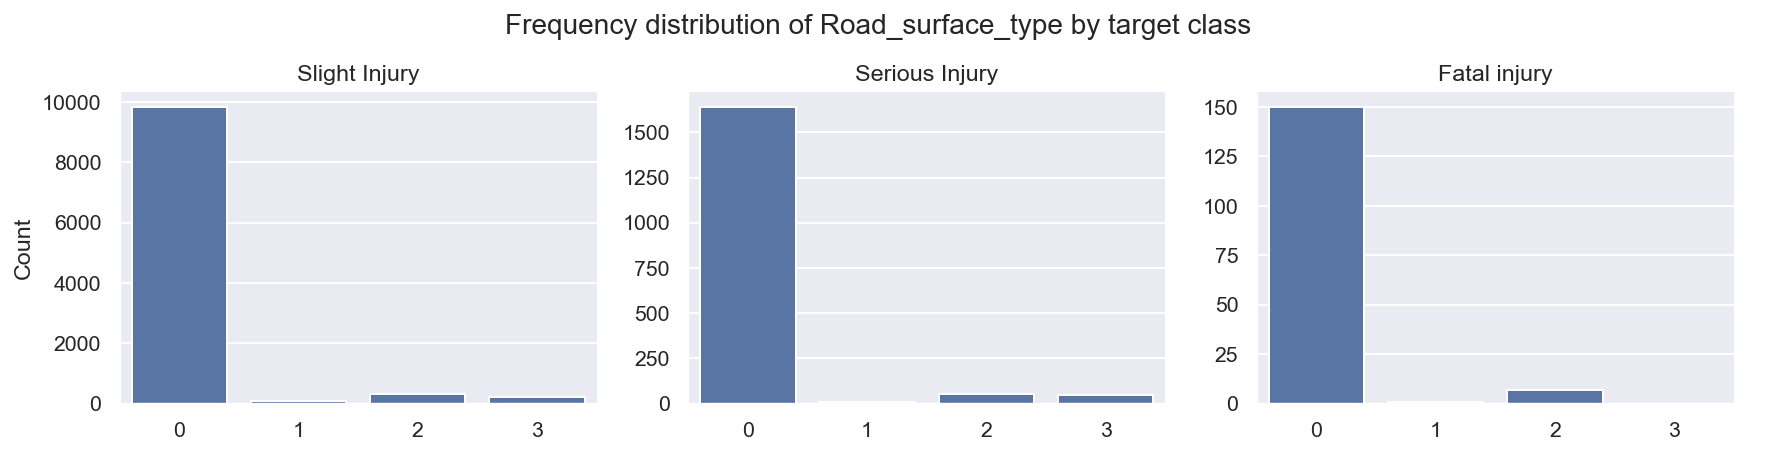

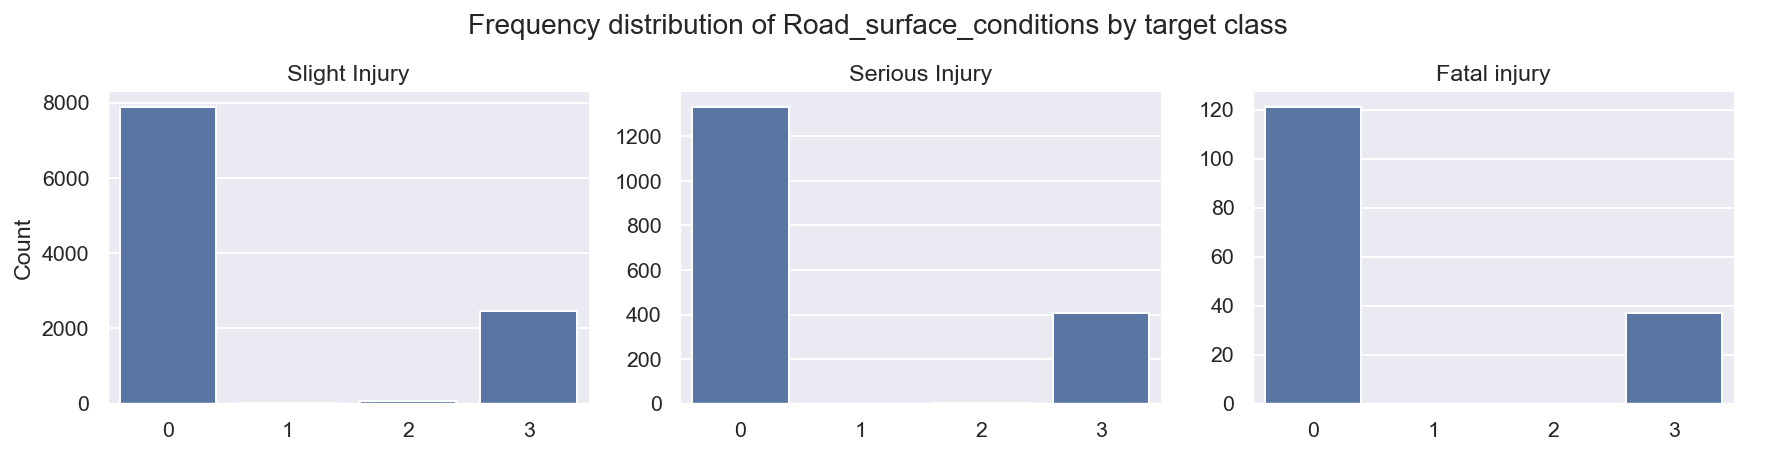

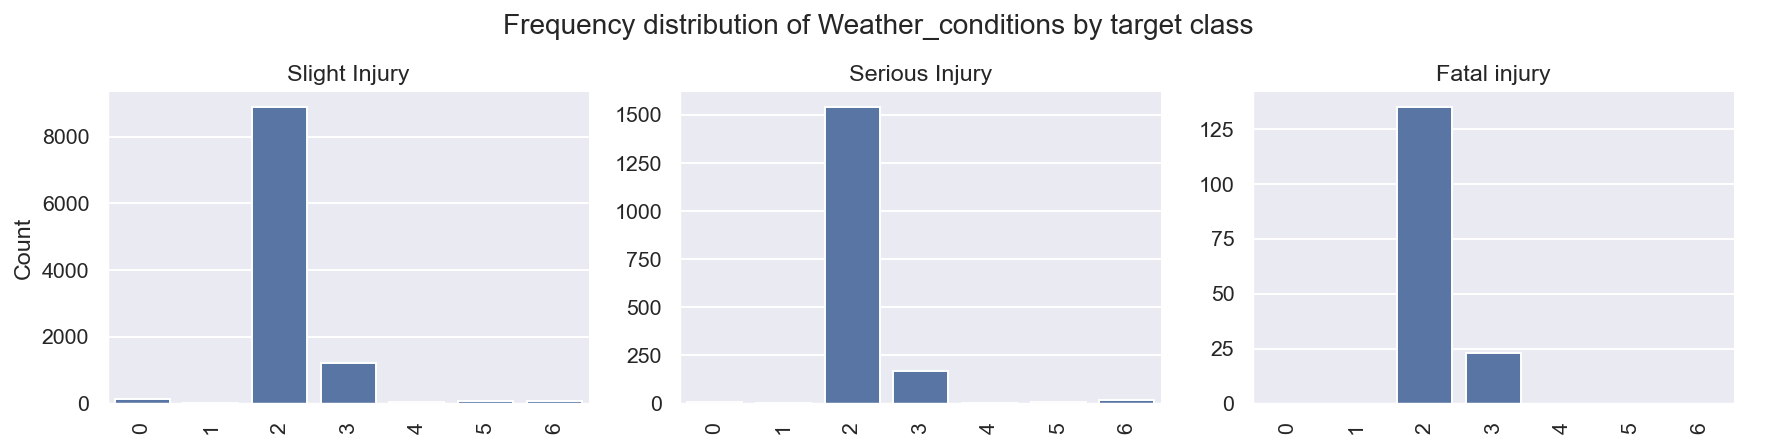

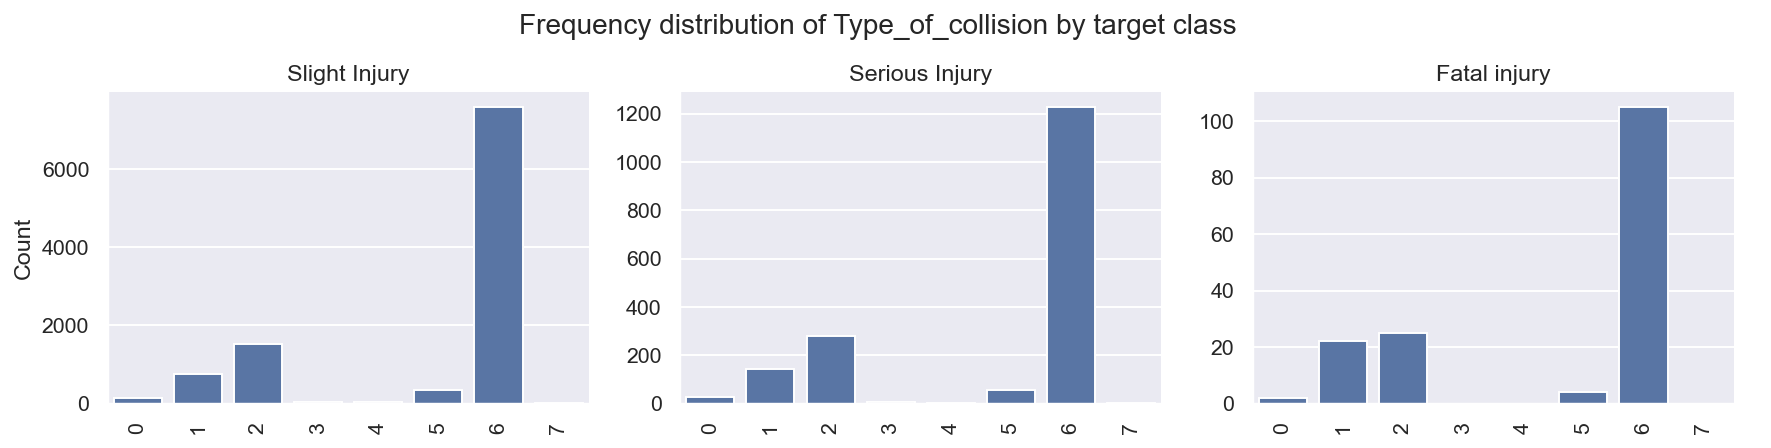

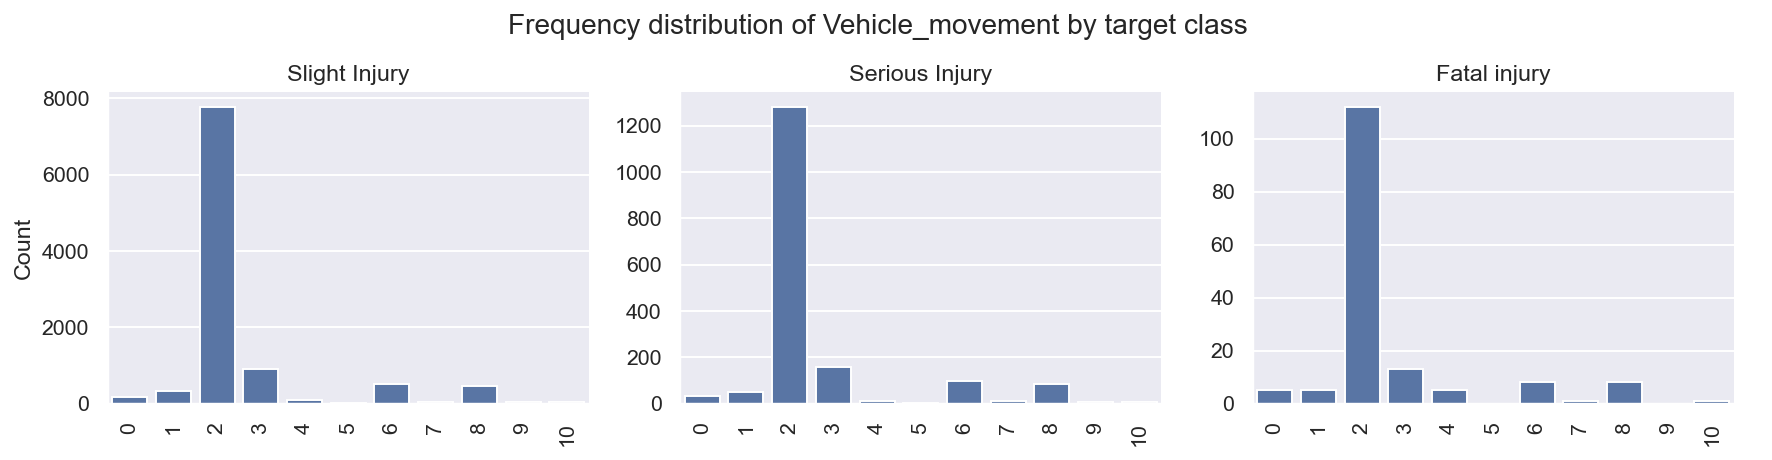

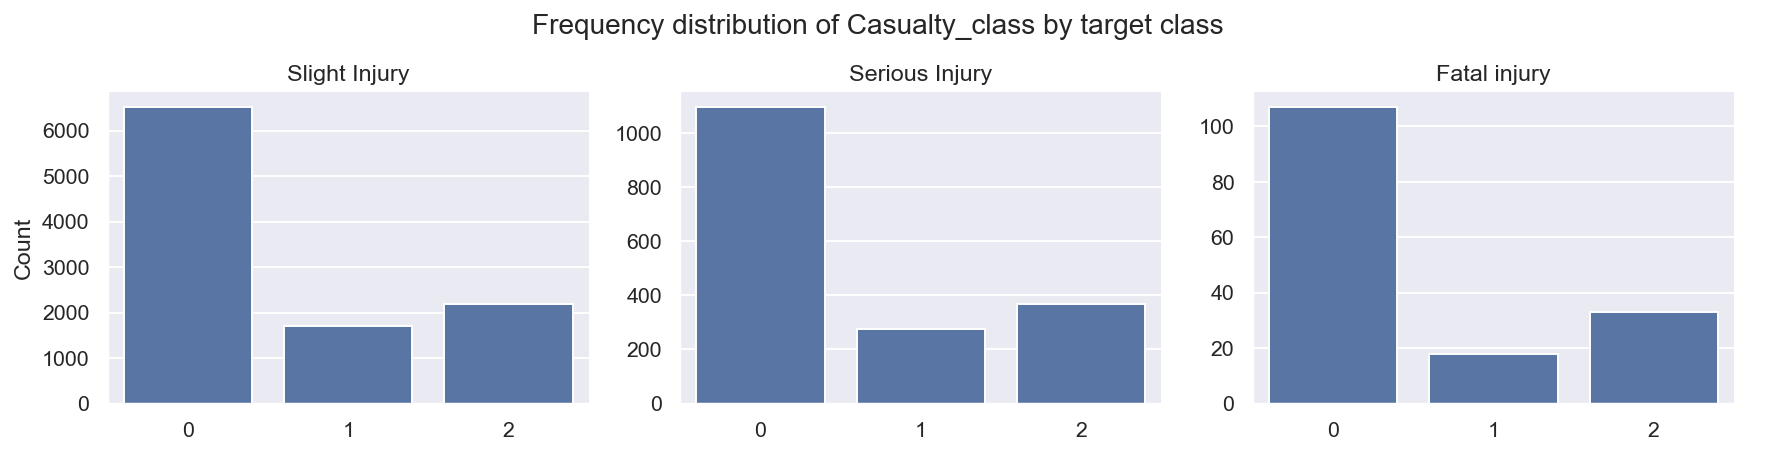

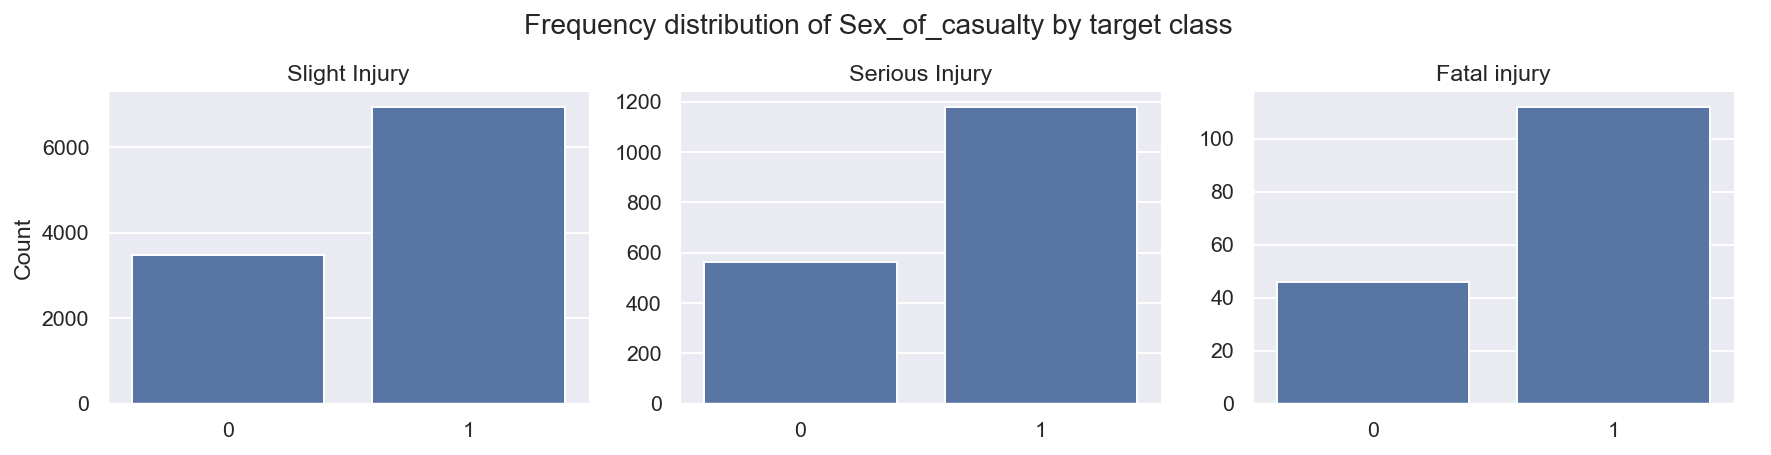

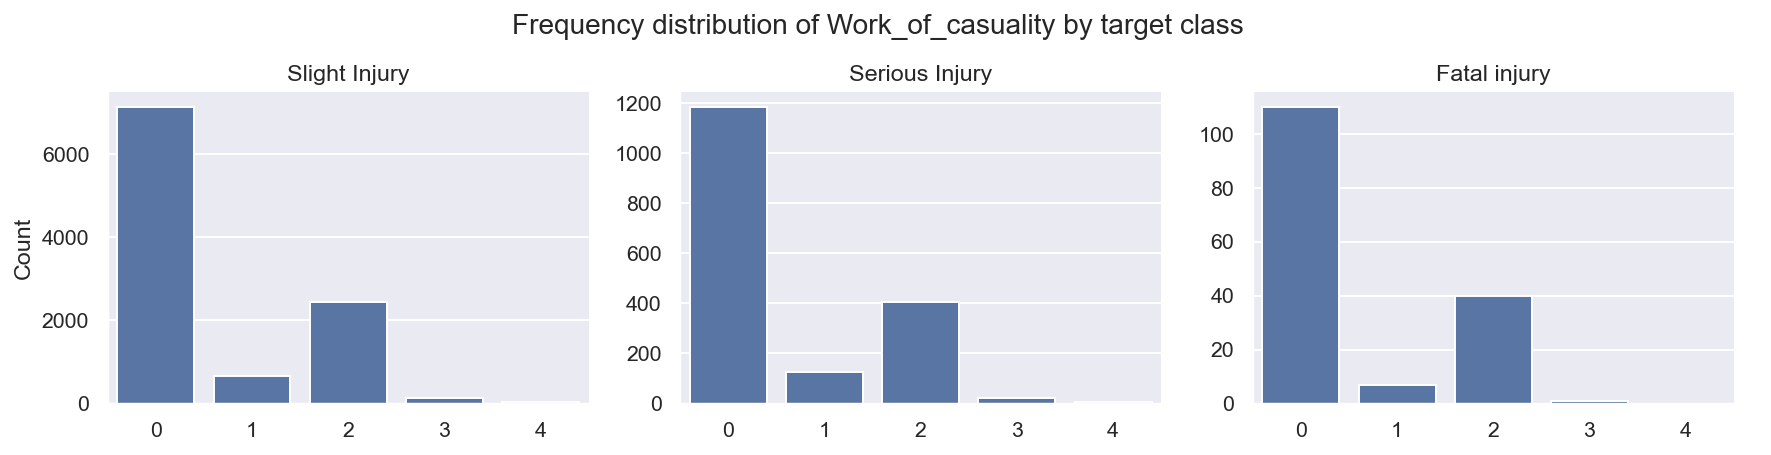

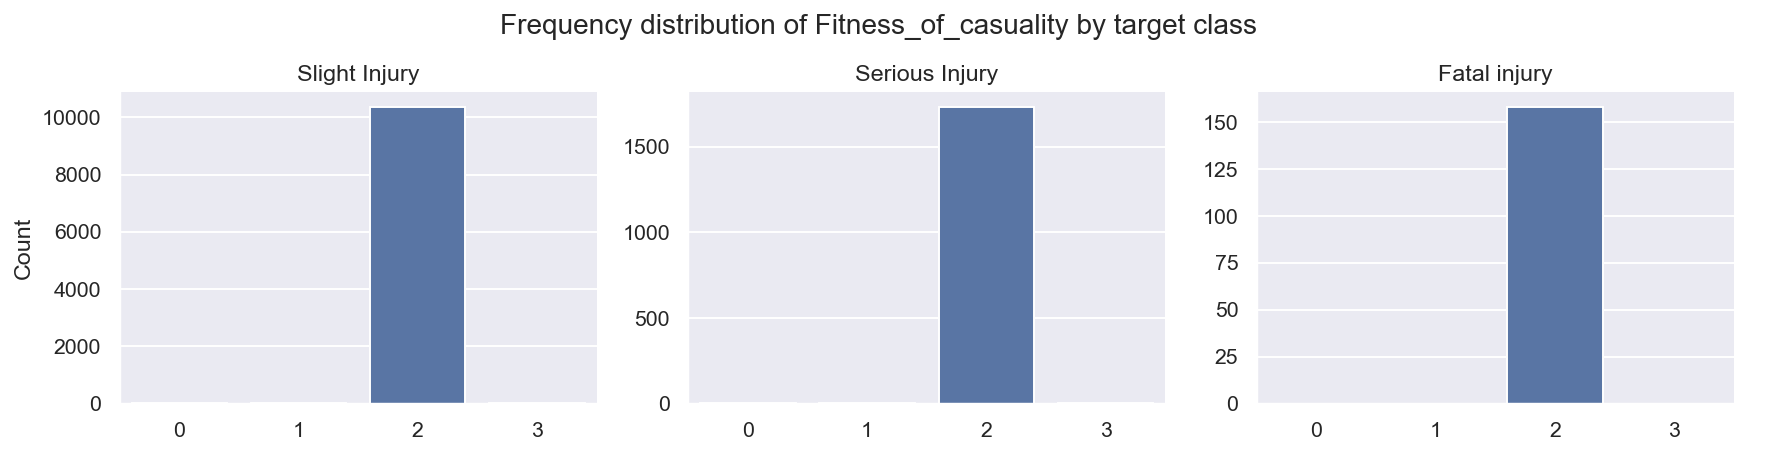

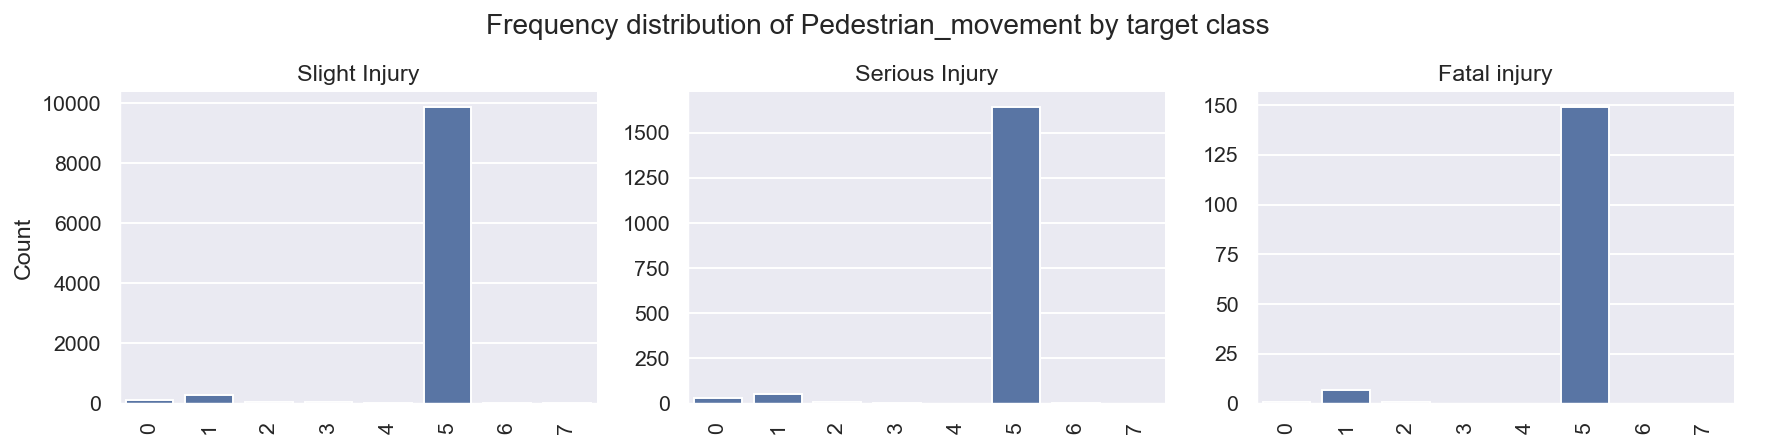

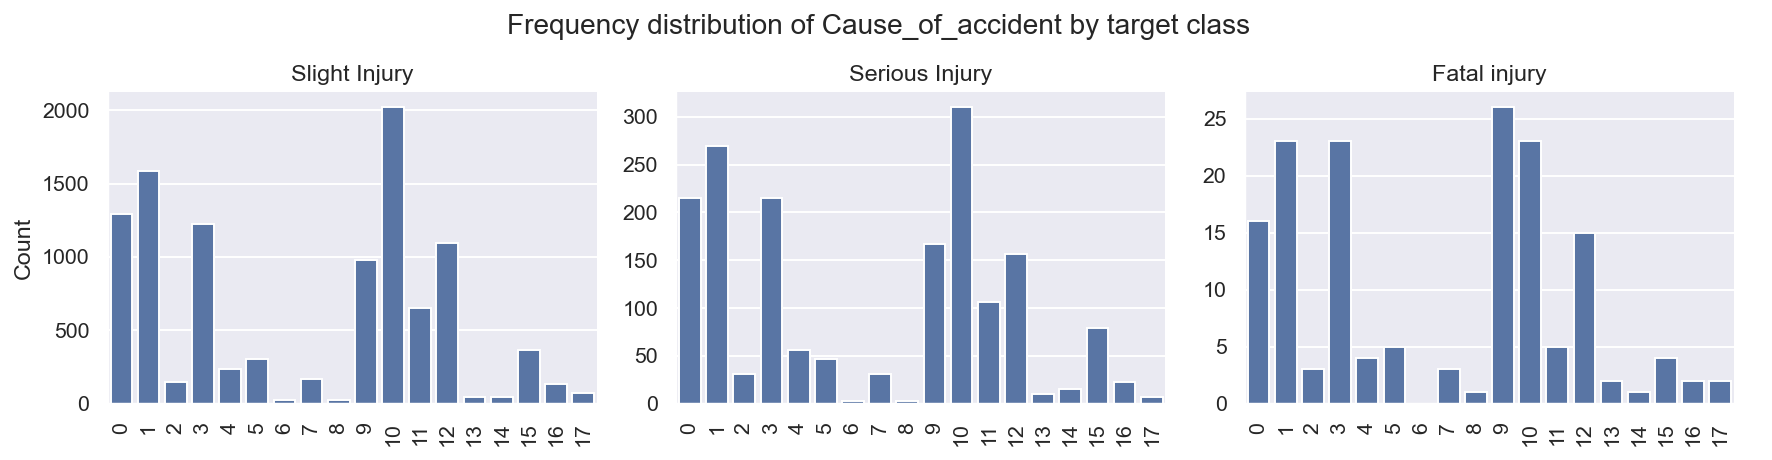

In [243]:

for feature in ordinal_cols + nominal_cols:
    if feature != TARGET and feature in data_enc.columns:
        facet_counts(data_enc, feature)

In [244]:
def corr_heatmap(df: pd.DataFrame, title="Feature correlation (Spearman)"):
    corr = df.corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(22, 16))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
    plt.title(title)
    plt.tight_layout()
    plt.show()


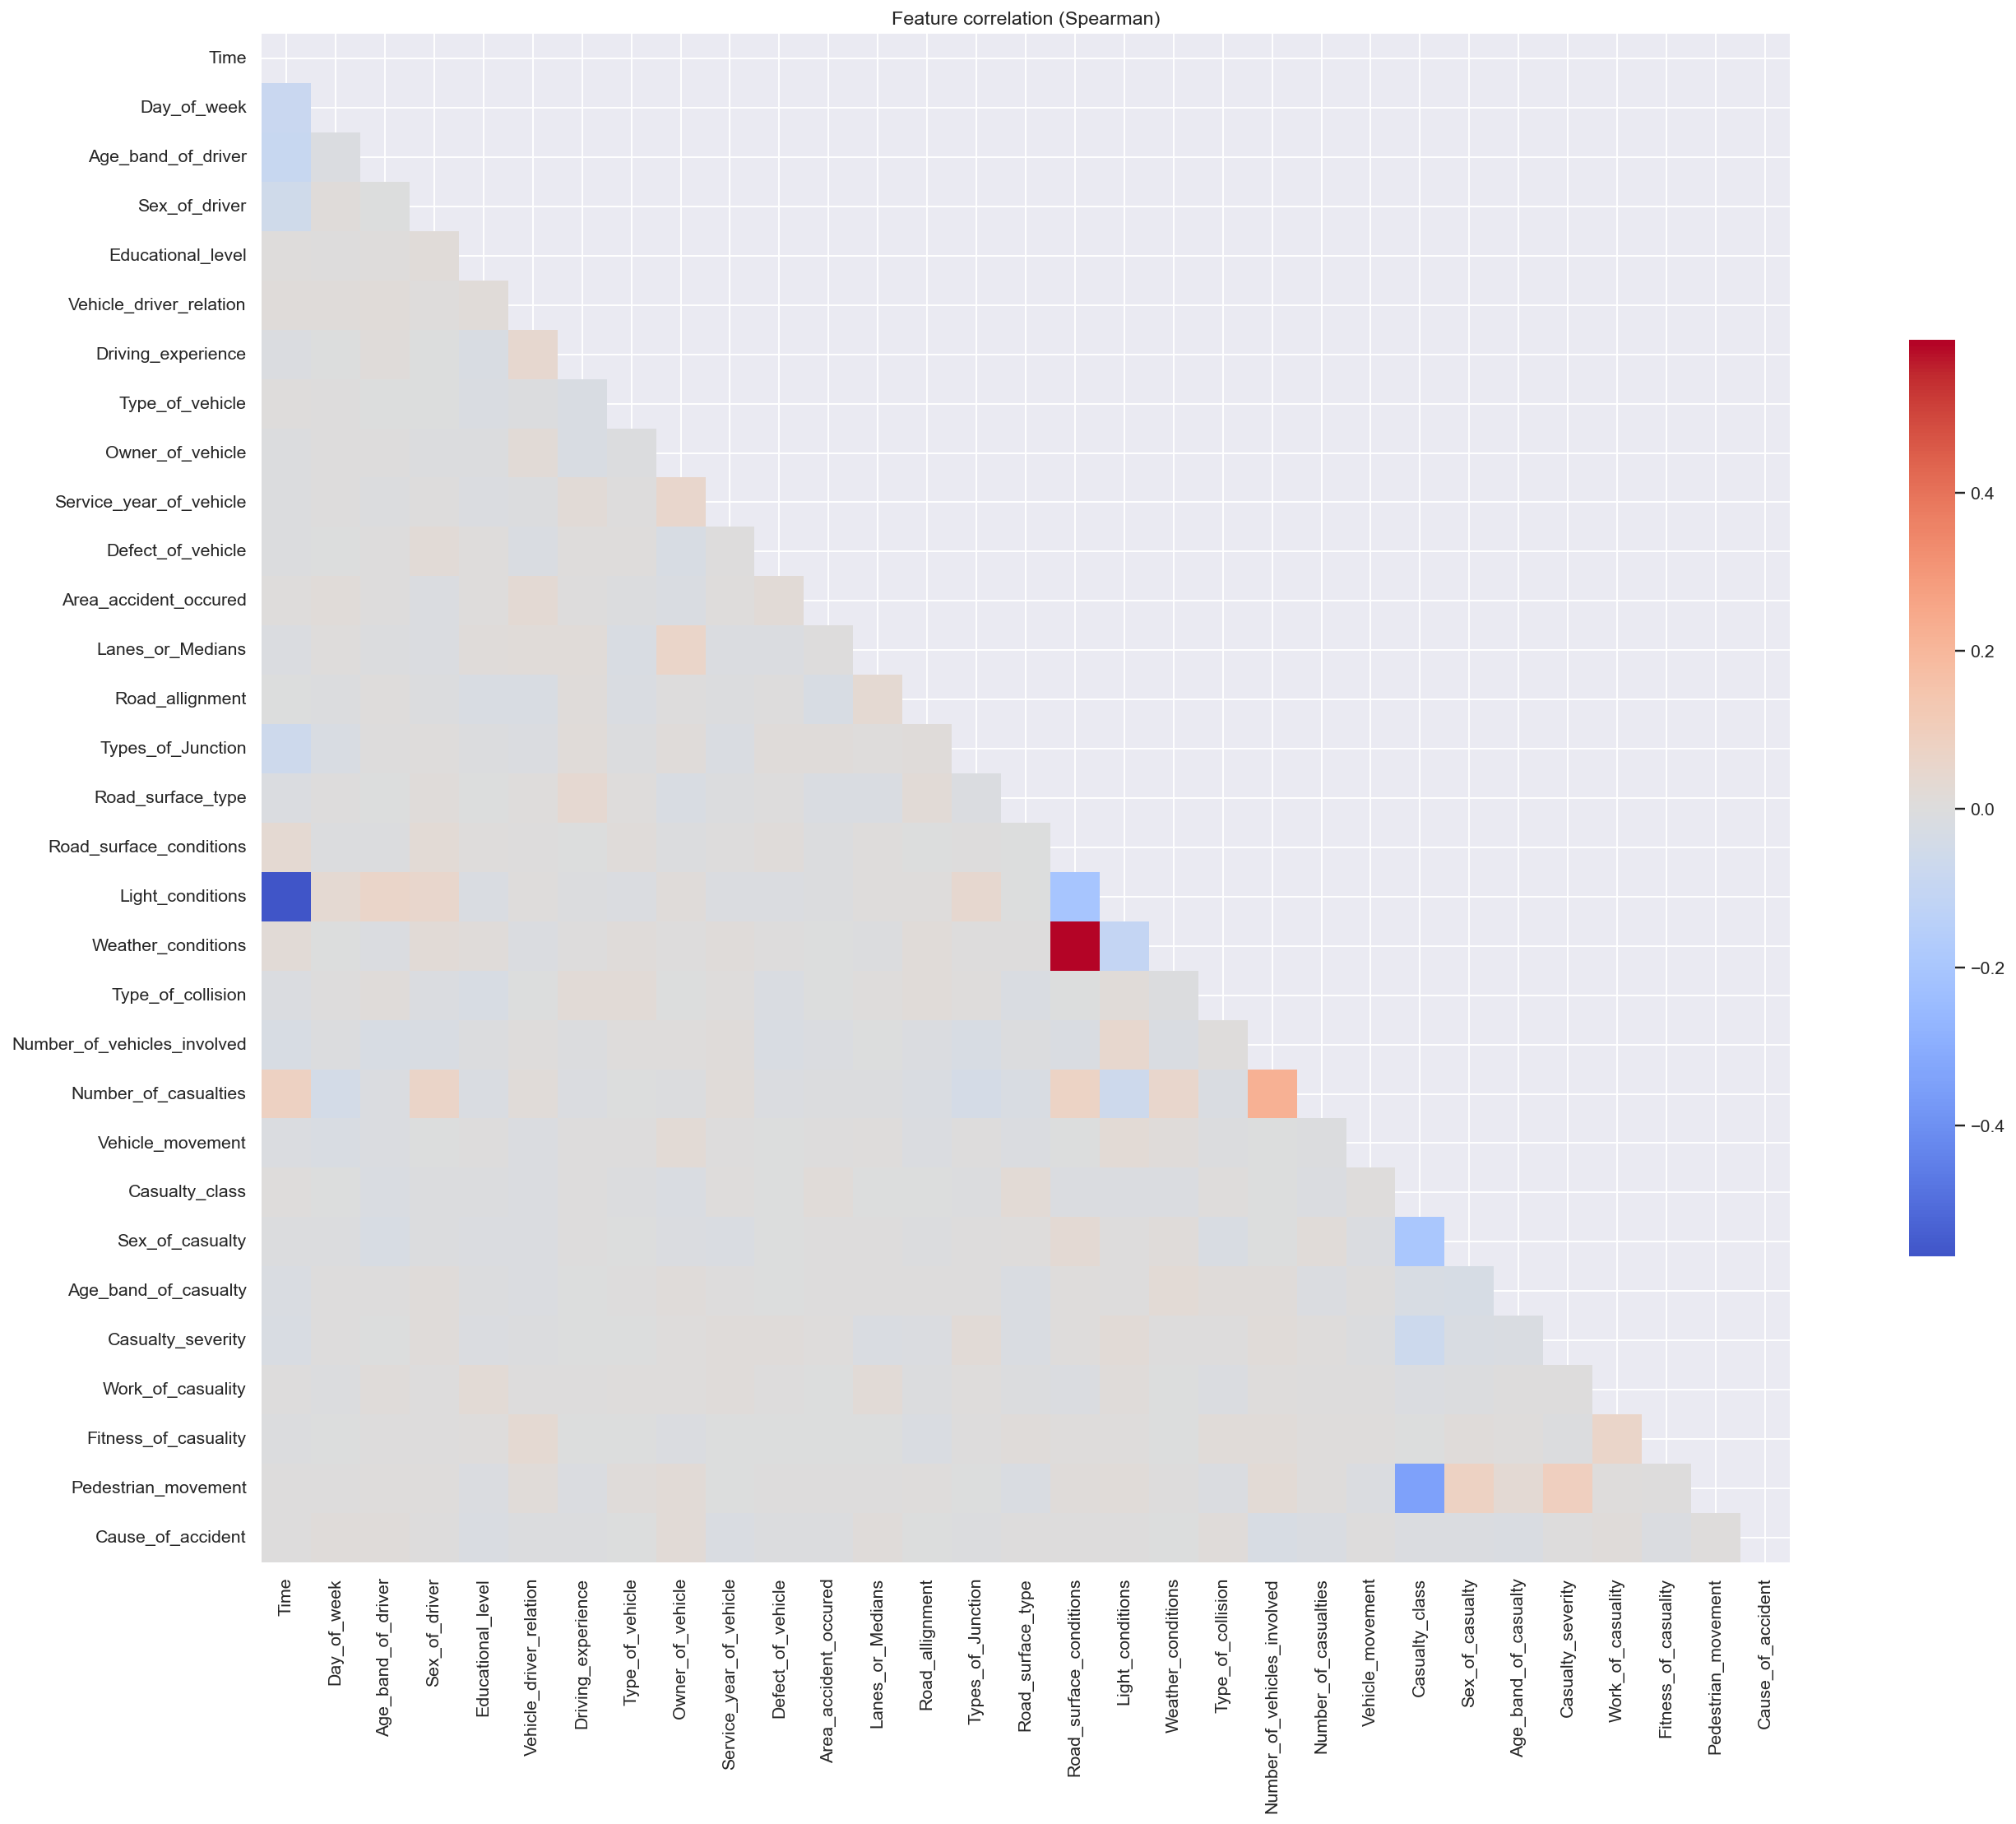

In [245]:
data_heat = data_enc.drop(columns=[TARGET], errors="ignore")
corr_heatmap(data_heat)

In [246]:
drop_cols = ["Casualty_class", "Sex_of_casualty", "Casualty_severity"]
data_enc = data_enc.drop(columns=drop_cols, errors="ignore")

In [247]:
print("Final columns:", len(data_enc.columns))


Final columns: 29


## 3.4 Predictor–target split

We Pull out `Accident_severity` as the label and keep everything else as predictors.

## 3.5 Train–test split

We Use a stratified 80/20 split so the class proportions (Slight/Serious/Fatal) stay consistent between train and test.  
We’ll print shapes and the class balance for both sets to confirm.


In [248]:

TARGET = "Accident_severity"
SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]

In [249]:
working_df = globals().get("data_enc", None)
if working_df is None:
    working_df = data

In [250]:
def predictor_target_split(df: pd.DataFrame, target: str):
    y = df[target]
    X = df.drop(columns=[target])
    return X, y


In [251]:

X, y = predictor_target_split(working_df, TARGET)

In [252]:
y = y.astype(pd.CategoricalDtype(categories=SEVERITY_ORDER, ordered=True))


In [253]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [254]:
print("Shapes:")
print("  X_train:", X_train.shape, "| y_train:", y_train.shape)
print("  X_test :", X_test.shape,  "| y_test :", y_test.shape)

Shapes:
  X_train: (9852, 28) | y_train: (9852,)
  X_test : (2464, 28) | y_test : (2464,)


In [255]:
def balance_table(series, title):
    vc = series.value_counts().reindex(SEVERITY_ORDER)
    tbl = pd.DataFrame({"count": vc, "pct": (vc / vc.sum() * 100).round(2)})
    print(f"\n{title}")
    display(tbl)

In [256]:
balance_table(y_train, "Train class distribution")
balance_table(y_test,  "Test  class distribution")


Train class distribution


,count,pct
Accident_severity,,
Slight Injury,8331,84.56
Serious Injury,1394,14.15
Fatal injury,127,1.29



Test  class distribution


,count,pct
Accident_severity,,
Slight Injury,2084,84.58
Serious Injury,349,14.16
Fatal injury,31,1.26


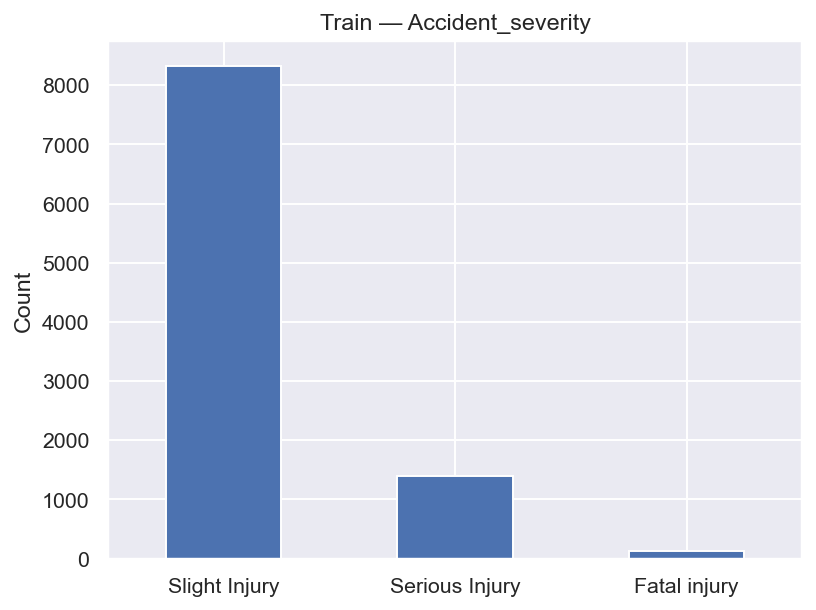

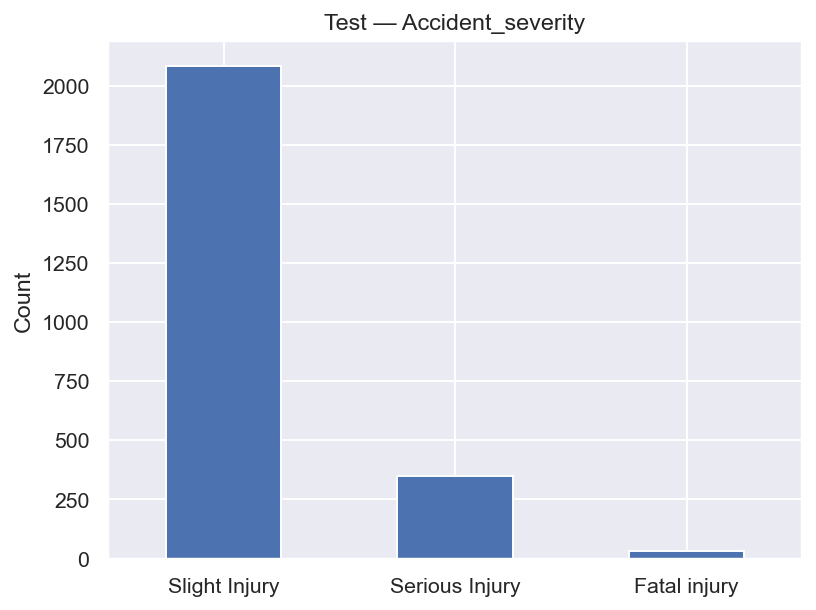

In [257]:
for name, s in [("Train", y_train), ("Test", y_test)]:
    vc = s.value_counts().reindex(SEVERITY_ORDER).fillna(0)
    vc.plot(kind="bar")
    plt.title(f"{name} — Accident_severity")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

## 3.6 Sampling

We’ll try different strategies to address the class imbalance on the **training** set:

- Random undersampling (RUS)
- Random oversampling (ROS)
- SMOTE (synthetic oversampling)
- NearMiss (undersampling by nearest neighbors)

Each method returns a new `(X_train, y_train)` and we’ll plot the target distribution before/after to confirm it’s balanced. Finally, we’ll encode the target to integers for modeling.


In [258]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling  import RandomOverSampler, SMOTE


In [259]:
SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
ACC_SEV_MAP = {"Slight Injury": 1, "Serious Injury": 2, "Fatal injury": 3}

In [260]:
def _count_table(s: pd.Series, title: str = ""):
    vc = s.value_counts().reindex(SEVERITY_ORDER)
    tbl = pd.DataFrame({"count": vc, "pct": (vc / vc.sum() * 100).round(2)})
    if title:
        print(title)
    display(tbl)

In [261]:
def _plot_before_after(y_before, y_after):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.countplot(x=y_before, order=SEVERITY_ORDER, ax=ax1)
    sns.countplot(x=y_after,  order=SEVERITY_ORDER, ax=ax2)
    ax1.set_title("Before")
    ax2.set_title("After")
    for ax in (ax1, ax2):
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    fig.suptitle("Training target distribution before vs after resampling", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

In [262]:
def resample_data(X_train, y_train, method="smote", show_plot=True, random_state=42):
    method = method.lower()
    if method == "rus":
        sampler = RandomUnderSampler(random_state=random_state, replacement=False)
    elif method == "ros":
        sampler = RandomOverSampler(random_state=random_state)
    elif method == "smote":
        sampler = SMOTE(random_state=random_state)   # n_jobs not supported; removes invalid arg
    elif method in ("nm", "nearmiss"):
        sampler = NearMiss()
    else:
        raise ValueError("method must be one of: 'rus', 'ros', 'smote', 'nm'")

    X_new, y_new = sampler.fit_resample(X_train, y_train)

    _count_table(y_train, "Before resampling")
    _count_table(y_new,   "After resampling")
    if show_plot:
        _plot_before_after(y_train, y_new)

    return X_new, y_new


Before resampling


,count,pct
Accident_severity,,
Slight Injury,8331,84.56
Serious Injury,1394,14.15
Fatal injury,127,1.29


After resampling


,count,pct
Accident_severity,,
Slight Injury,8331,33.33
Serious Injury,8331,33.33
Fatal injury,8331,33.33


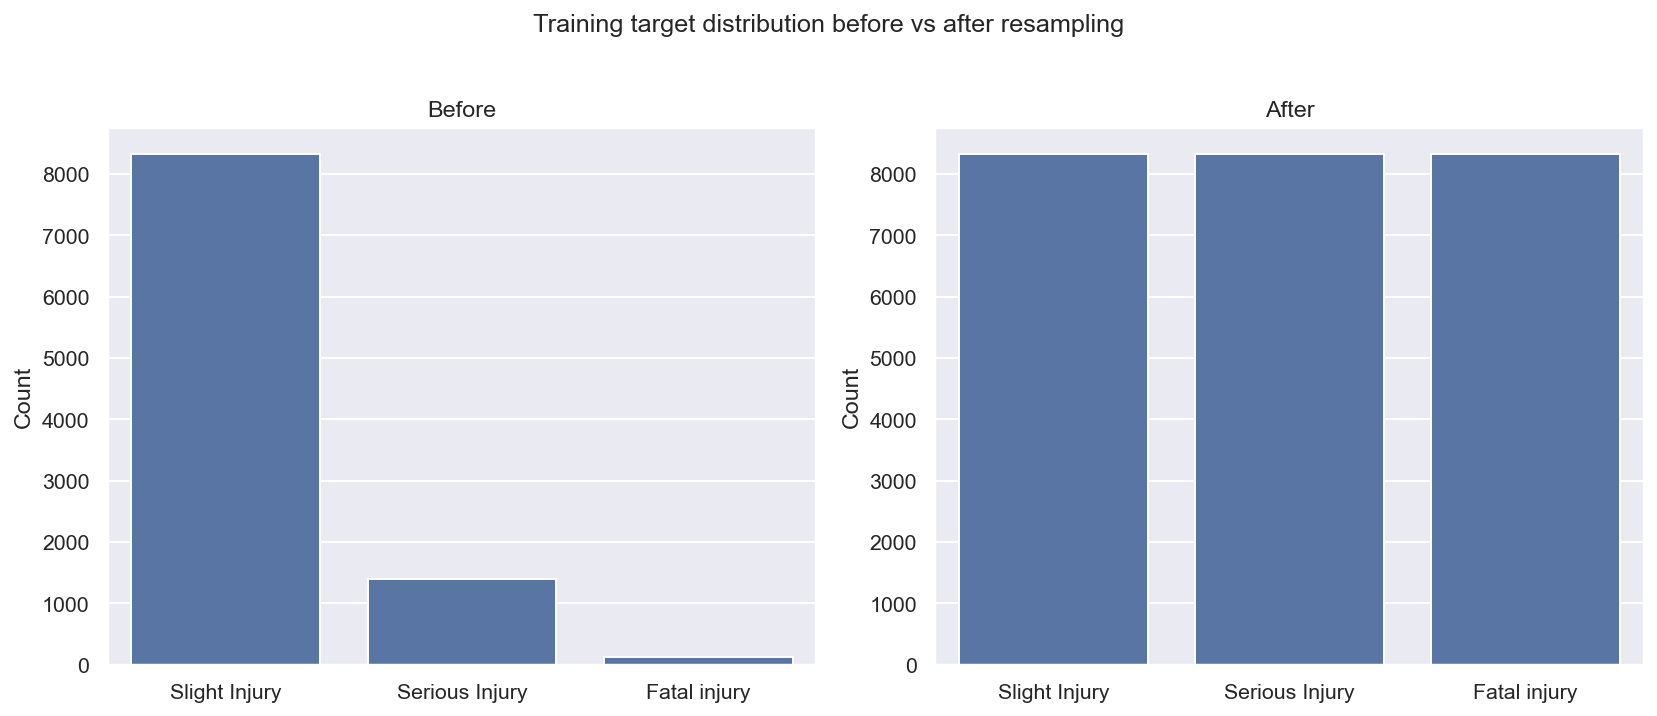

In [263]:
X_train, y_train = resample_data(X_train, y_train, method="ros", show_plot=True, random_state=42)


In [264]:
y_train = y_train.map(ACC_SEV_MAP).astype(int)
y_test  = y_test.map(ACC_SEV_MAP).astype(int)
print("Target classes encoded as:", ACC_SEV_MAP)

Target classes encoded as: {'Slight Injury': 1, 'Serious Injury': 2, 'Fatal injury': 3}


## Zero-variance features

After resampling it’s good to confirm no predictor is constant.  
We’ll list any columns with a single unique value and drop them from both train and test.


In [265]:
def drop_constant_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    nuniques = X_train.nunique(dropna=False)
    constant_cols = nuniques[nuniques <= 1].index.tolist()

    print("Constant columns in X_train:", constant_cols if constant_cols else "None")
    if constant_cols:
        X_train = X_train.drop(columns=constant_cols)
        X_test  = X_test.drop(columns=[c for c in constant_cols if c in X_test.columns])
        print(f"Dropped {len(constant_cols)} constant column(s).")
    print("New shapes — X_train:", X_train.shape, "| X_test:", X_test.shape)
    return X_train, X_test, constant_cols

X_train, X_test, constant_cols = drop_constant_columns(X_train, X_test)

Constant columns in X_train: None
New shapes — X_train: (24993, 28) | X_test: (2464, 28)


## 3.8 Feature selection

We’ll try two univariate filters:

- **Chi-square (χ²)** — requires non-negative inputs; we’ll shift any column with a negative minimum to start at 0.
- **Mutual information (MI)** — captures any nonlinear association; with our integer-coded categories, we’ll flag features as discrete.

First, we’ll score all features and visualize the χ² scores. Then we’ll keep the top 16 features and slice both train and test to those columns.


In [266]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif


In [267]:
def shift_to_nonnegative_df(df: pd.DataFrame) -> pd.DataFrame:
    df_ = df.copy()
    mins = df_.min(axis=0, numeric_only=True)
    to_shift = mins[mins < 0]
    if not to_shift.empty:
        df_[to_shift.index] = df_[to_shift.index].add(-to_shift, axis=1)
    return df_

In [268]:
def shift_to_nonnegative_series(y: pd.Series) -> pd.Series:
    y_ = y.copy()
    m = y_.min()
    return y_ - m if m < 0 else y_

In [269]:
def feature_selection_chi2(X_tr, y_tr, X_te, k="all"):
    # χ² needs nonnegative inputs
    X_tr_pos = shift_to_nonnegative_df(X_tr)
    X_te_pos = shift_to_nonnegative_df(X_te)
    y_tr_pos = shift_to_nonnegative_series(y_tr)

    fs = SelectKBest(score_func=chi2, k=k)
    fs.fit(X_tr_pos, y_tr_pos)

    cols = X_tr_pos.columns[fs.get_support()]
    return X_tr_pos[cols], X_te_pos[cols], fs, cols.tolist()

In [270]:
def feature_selection_mi(X_tr, y_tr, X_te, k="all"):
    fs = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, discrete_features=True, random_state=42), k=k)
    fs.fit(X_tr, y_tr)
    cols = X_tr.columns[fs.get_support()]
    return X_tr[cols], X_te[cols], fs, cols.tolist()

In [271]:
X_train_chi_all, X_test_chi_all, fs_chi, _ = feature_selection_chi2(X_train, y_train, X_test, k="all")


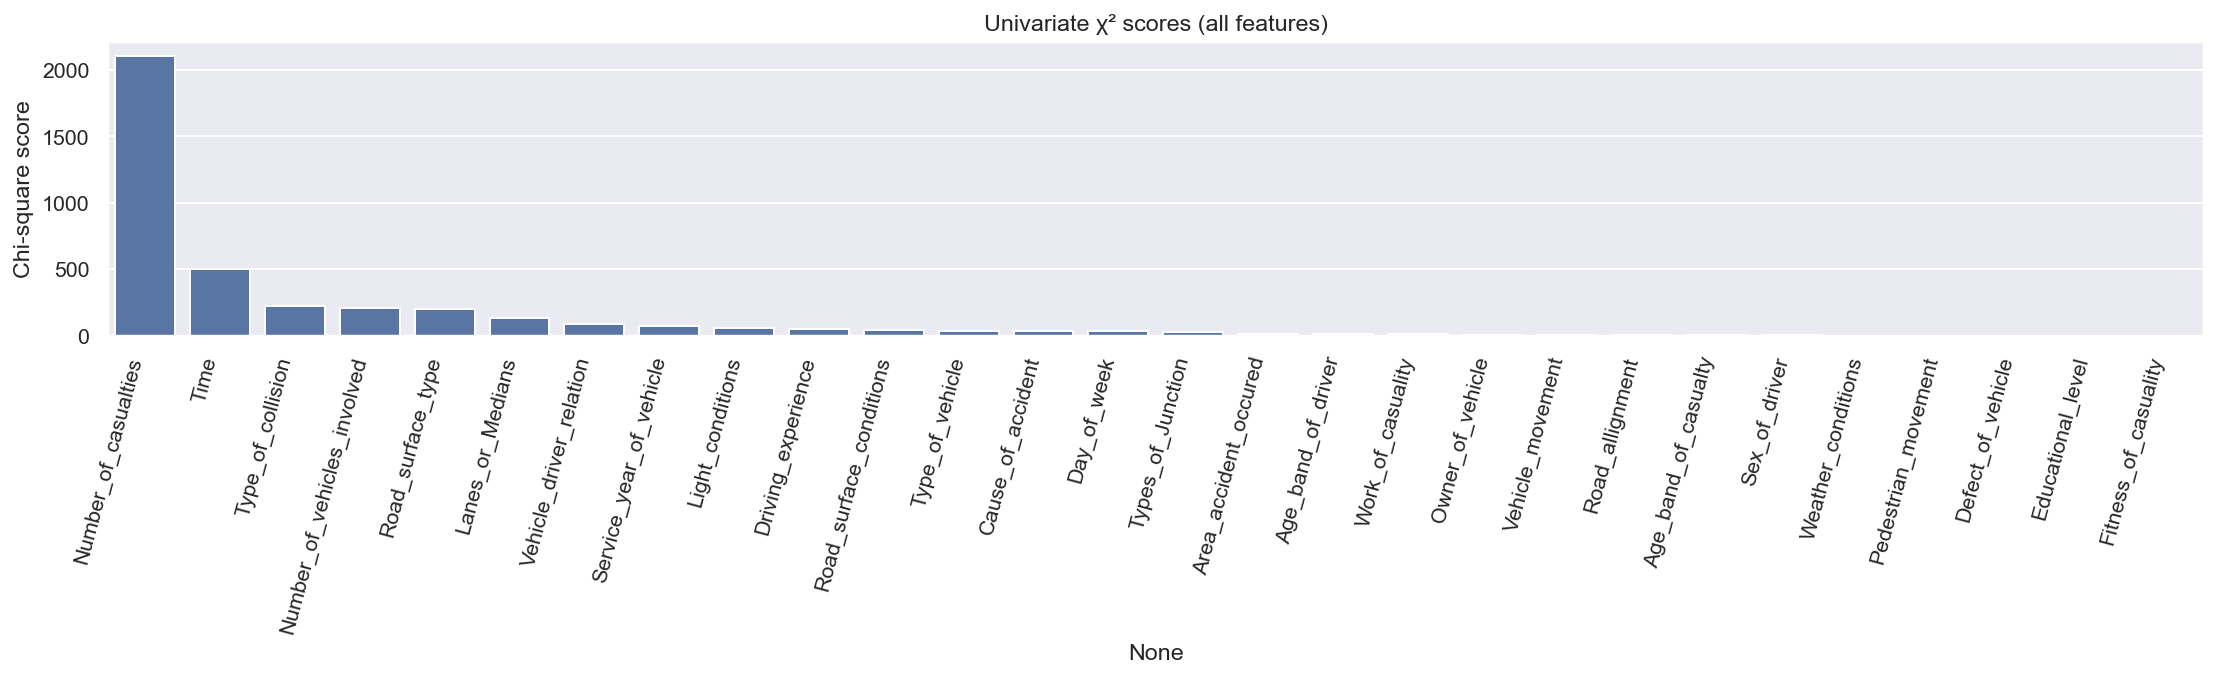

In [272]:
chi_scores = pd.Series(fs_chi.scores_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(16, 5))
sns.barplot(x=chi_scores.index, y=chi_scores.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Chi-square score")
plt.title("Univariate χ² scores (all features)")
plt.tight_layout()
plt.show()

In [273]:
TOP_K = 16
X_train, X_test, fs_chi_k, selected_cols = feature_selection_chi2(X_train, y_train, X_test, k=TOP_K)
print(f"Selected top {TOP_K} features (χ²):")
print(selected_cols)

Selected top 16 features (χ²):
['Time', 'Day_of_week', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Cause_of_accident']


In [274]:
X_train_mi, X_test_mi, fs_mi, selected_cols_mi = feature_selection_mi(X_train, y_train, X_test, k=TOP_K)
print("\nTop features by Mutual Information:")
print(selected_cols_mi)


Top features by Mutual Information:
['Time', 'Day_of_week', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Cause_of_accident']


## χ² vs MI ( side-by-side )

We’ll score the same predictors with both χ² and Mutual Information (MI), rank them, and compare:
- a table with both scores and ranks,
- the top-16 lists from each method,
- overlap count and Jaccard similarity.




In [275]:
from sklearn.feature_selection import mutual_info_classif


In [276]:
X_all = X_train_chi_all.copy()
y_all = y_train.copy()

In [277]:
mi_vals = mutual_info_classif(X_all, y_all, discrete_features=True, random_state=42)
mi_scores = pd.Series(mi_vals, index=X_all.columns, name="mi").sort_values(ascending=False)


In [278]:
chi_series = chi_scores.copy().rename("chi2").sort_values(ascending=False)


In [279]:
comp = (
    pd.concat([chi_series, mi_scores], axis=1)
      .assign(chi2_rank=lambda d: d["chi2"].rank(ascending=False, method="min").astype(int),
              mi_rank=lambda d: d["mi"].rank(ascending=False, method="min").astype(int))
      .sort_values("chi2_rank")
)


In [280]:
display(comp.head(25))


,chi2,mi,chi2_rank,mi_rank
Number_of_casualties,2105.312137,0.089277,1,1
Time,502.061004,0.014384,2,6
Type_of_collision,225.005867,0.011050,3,11
Number_of_vehicles_involved,211.644519,0.029715,4,2
Road_surface_type,202.637121,0.007507,5,15
Lanes_or_Medians,137.256430,0.006034,6,17
Vehicle_driver_relation,90.677696,0.002220,7,22
Service_year_of_vehicle,72.335773,0.004436,8,19
Light_conditions,62.176940,0.012324,9,9
Driving_experience,53.277941,0.016716,10,4


In [281]:
TOP_K = 16
top16_chi = comp.nsmallest(TOP_K, "chi2_rank").index.tolist()
top16_mi  = comp.nsmallest(TOP_K, "mi_rank").index.tolist()

In [282]:
print("\nTop-16 by χ²:")
print(top16_chi)
print("\nTop-16 by MI:")
print(top16_mi)


Top-16 by χ²:
['Number_of_casualties', 'Time', 'Type_of_collision', 'Number_of_vehicles_involved', 'Road_surface_type', 'Lanes_or_Medians', 'Vehicle_driver_relation', 'Service_year_of_vehicle', 'Light_conditions', 'Driving_experience', 'Road_surface_conditions', 'Type_of_vehicle', 'Cause_of_accident', 'Day_of_week', 'Types_of_Junction', 'Area_accident_occured']

Top-16 by MI:
['Number_of_casualties', 'Number_of_vehicles_involved', 'Day_of_week', 'Driving_experience', 'Cause_of_accident', 'Time', 'Area_accident_occured', 'Road_allignment', 'Light_conditions', 'Vehicle_movement', 'Type_of_collision', 'Type_of_vehicle', 'Types_of_Junction', 'Weather_conditions', 'Road_surface_type', 'Work_of_casuality']


In [283]:
overlap = sorted(set(top16_chi) & set(top16_mi))
jaccard = len(overlap) / len(set(top16_chi) | set(top16_mi))
print(f"\nOverlap count: {len(overlap)} / {TOP_K}")
print(f"Jaccard similarity: {jaccard:.2f}")
print("Overlapping features:", overlap)


Overlap count: 12 / 16
Jaccard similarity: 0.60
Overlapping features: ['Area_accident_occured', 'Cause_of_accident', 'Day_of_week', 'Driving_experience', 'Light_conditions', 'Number_of_casualties', 'Number_of_vehicles_involved', 'Road_surface_type', 'Time', 'Type_of_collision', 'Type_of_vehicle', 'Types_of_Junction']


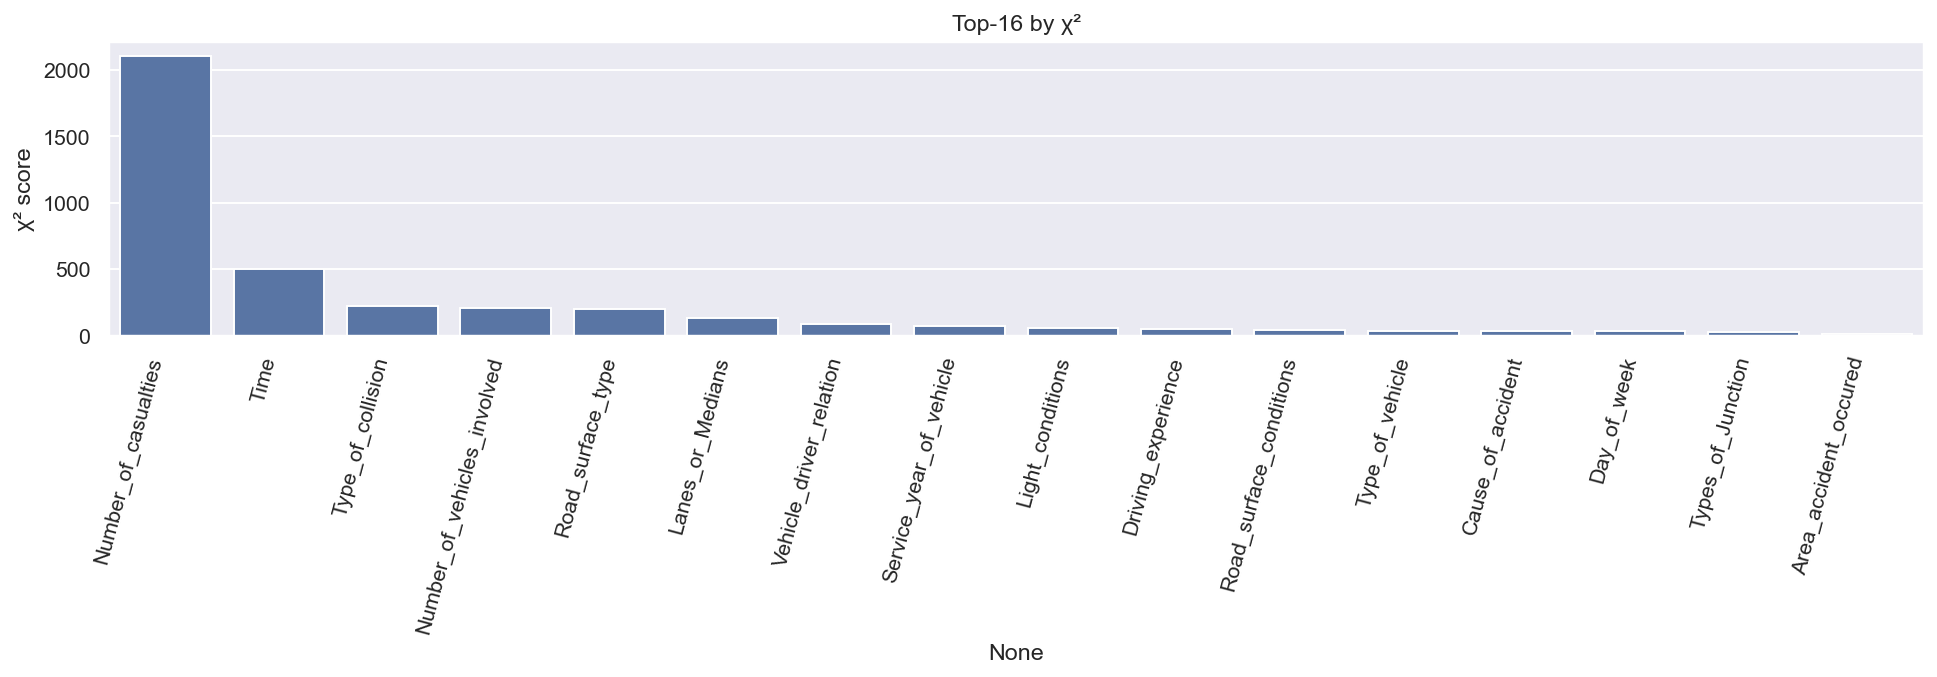

In [284]:
plt.figure(figsize=(14,5))
sns.barplot(x=chi_series.loc[top16_chi].index, y=chi_series.loc[top16_chi].values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("χ² score")
plt.title("Top-16 by χ²")
plt.tight_layout()
plt.show()

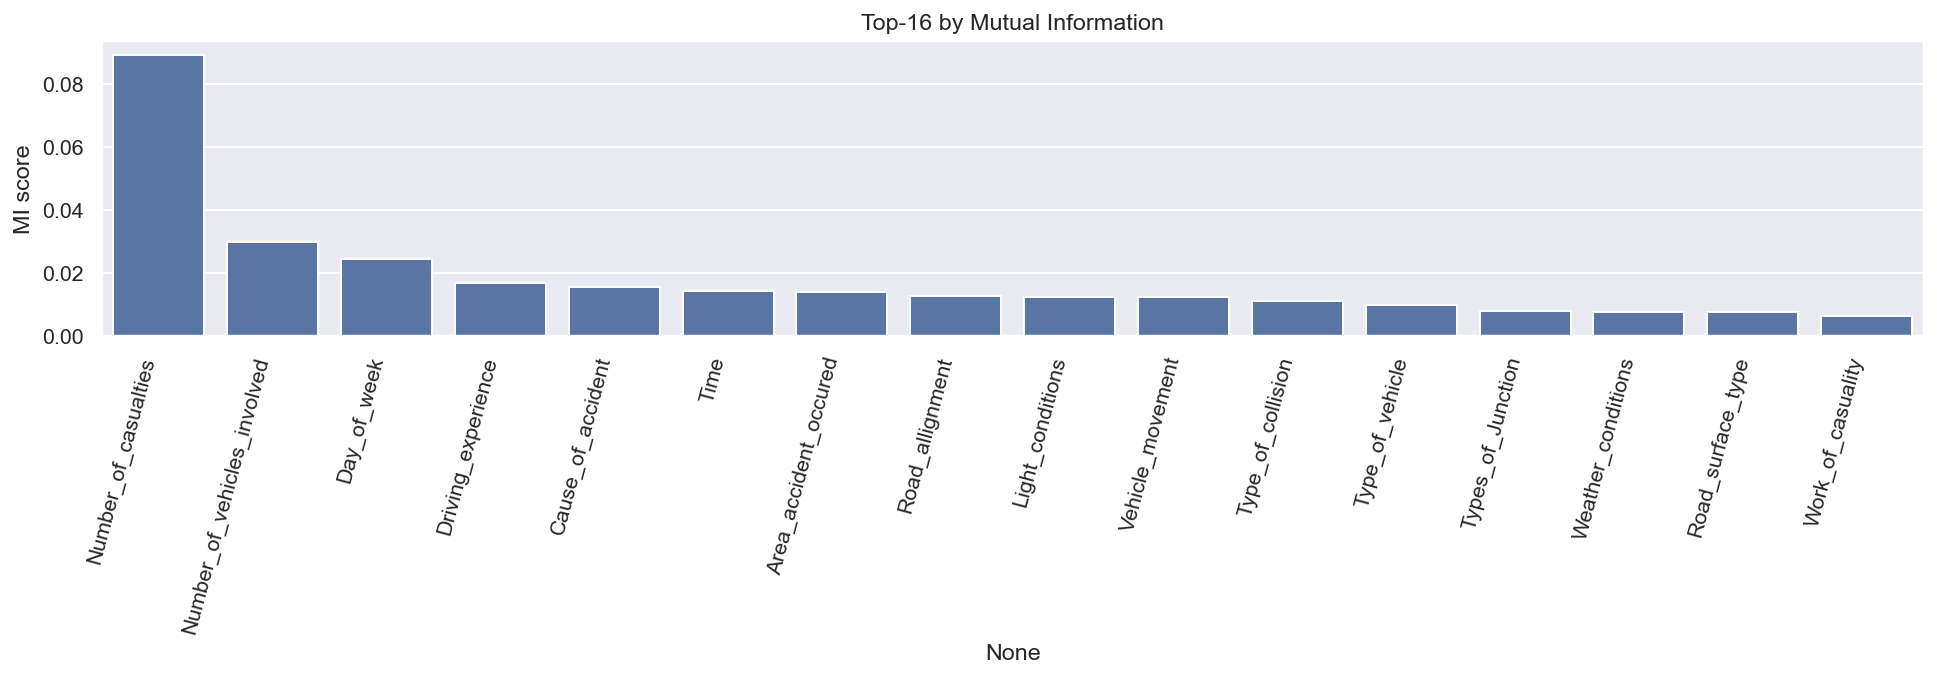

In [285]:
plt.figure(figsize=(14,5))
sns.barplot(x=mi_scores.loc[top16_mi].index, y=mi_scores.loc[top16_mi].values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("MI score")
plt.title("Top-16 by Mutual Information")
plt.tight_layout()
plt.show()

In [286]:
selected_cols = top16_chi
X_train_sel = X_all[selected_cols].copy()
X_test_sel  = X_test_chi_all[selected_cols].copy()

In [287]:
print("\nSelected features for modeling (χ² top-16):")
print(selected_cols)
print("Shapes -> X_train_sel:", X_train_sel.shape, "| X_test_sel:", X_test_sel.shape)



Selected features for modeling (χ² top-16):
['Number_of_casualties', 'Time', 'Type_of_collision', 'Number_of_vehicles_involved', 'Road_surface_type', 'Lanes_or_Medians', 'Vehicle_driver_relation', 'Service_year_of_vehicle', 'Light_conditions', 'Driving_experience', 'Road_surface_conditions', 'Type_of_vehicle', 'Cause_of_accident', 'Day_of_week', 'Types_of_Junction', 'Area_accident_occured']
Shapes -> X_train_sel: (24993, 16) | X_test_sel: (2464, 16)


In [290]:
X_train, X_test = X_train_sel, X_test_sel

We’ll lock the χ² top-16 feature list and ensure both train/test use exactly this column order going forward.


In [292]:
# Use the pre-selection feature matrices if they exist; otherwise fall back gracefully
SRC_TRAIN = X_all if 'X_all' in globals() else X_train
SRC_TEST  = X_test_chi_all if 'X_test_chi_all' in globals() else X_test

SELECTED_COLS = [
    'Vehicle_driver_relation', 'Road_surface_conditions',
    'Cause_of_accident', 'Service_year_of_vehicle', 'Light_conditions',
    'Road_surface_type', 'Day_of_week', 'Type_of_collision', 'Type_of_vehicle',
    'Age_band_of_driver', 'Types_of_Junction', 'Time',
    'Area_accident_occured', 'Lanes_or_Medians', 'Weather_conditions'
]

# Only keep columns that actually exist in the chosen source
have = [c for c in SELECTED_COLS if c in SRC_TRAIN.columns]
missing = [c for c in SELECTED_COLS if c not in SRC_TRAIN.columns]
print("Skipping missing columns:", missing)

X_train = SRC_TRAIN[have].copy()
X_test  = SRC_TEST[have].copy()

print("Locked feature set (len={}):".format(len(have)))
print(have)
print("Shapes -> X_train:", X_train.shape, "| X_test:", X_test.shape)


Skipping missing columns: []
Locked feature set (len=15):
['Vehicle_driver_relation', 'Road_surface_conditions', 'Cause_of_accident', 'Service_year_of_vehicle', 'Light_conditions', 'Road_surface_type', 'Day_of_week', 'Type_of_collision', 'Type_of_vehicle', 'Age_band_of_driver', 'Types_of_Junction', 'Time', 'Area_accident_occured', 'Lanes_or_Medians', 'Weather_conditions']
Shapes -> X_train: (24993, 15) | X_test: (2464, 15)


## 4. Baseline models

We’ll train a few tree-based baselines on the χ² top-16 features:

- Decision Tree
- Random Forest
- ExtraTrees
- XGBoost (multi-class)

For each, we report **weighted F1** and **macro F1** on the test set and show a confusion matrix
(using our encoded labels: 1=Slight, 2=Serious, 3=Fatal).


In [293]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report


In [294]:
CLASS_MAP = {1: "Slight", 2: "Serious", 3: "Fatal"}
CLASS_ORDER = [1, 2, 3]

In [295]:
def plot_conf_mat(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    df = pd.DataFrame(cm, index=[CLASS_MAP[i] for i in CLASS_ORDER],
                         columns=[CLASS_MAP[i] for i in CLASS_ORDER])
    plt.figure(figsize=(6.2, 5.2))
    sns.heatmap(df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

In [296]:
def eval_model(name, model, X_tr, y_tr, X_te, y_te, show_cm=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    f1_w = f1_score(y_te, y_pred, average="weighted")
    f1_m = f1_score(y_te, y_pred, average="macro")
    print(f"{name} — Weighted F1: {f1_w:.4f} | Macro F1: {f1_m:.4f}")
    if show_cm:
        plot_conf_mat(y_te, y_pred, title=f"{name} — confusion matrix")
    return {"Classifier": name, "F1_weighted": f1_w, "F1_macro": f1_m}

results = []


Decision Tree — Weighted F1: 0.7316 | Macro F1: 0.3344


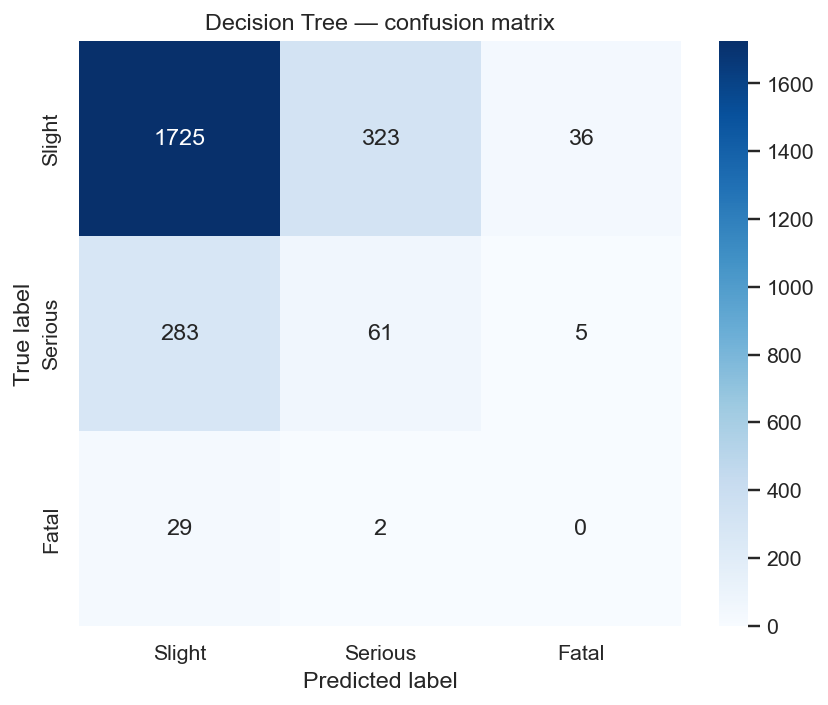

In [297]:
dt = DecisionTreeClassifier(random_state=42)
results.append(eval_model("Decision Tree", dt, X_train, y_train, X_test, y_test))

Random Forest — Weighted F1: 0.7781 | Macro F1: 0.3221


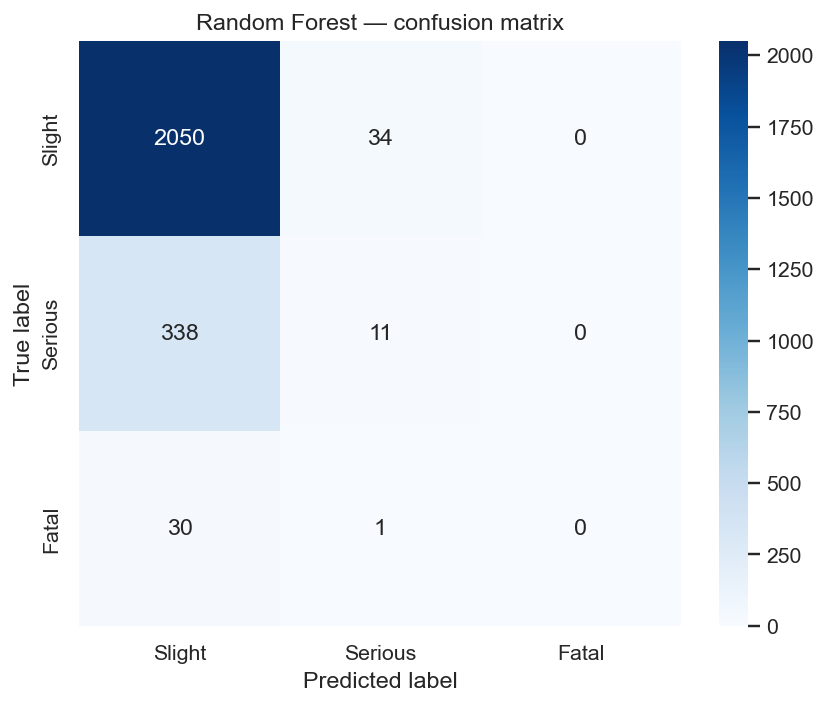

In [298]:
rf = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
results.append(eval_model("Random Forest", rf, X_train, y_train, X_test, y_test))

ExtraTrees — Weighted F1: 0.7751 | Macro F1: 0.3128


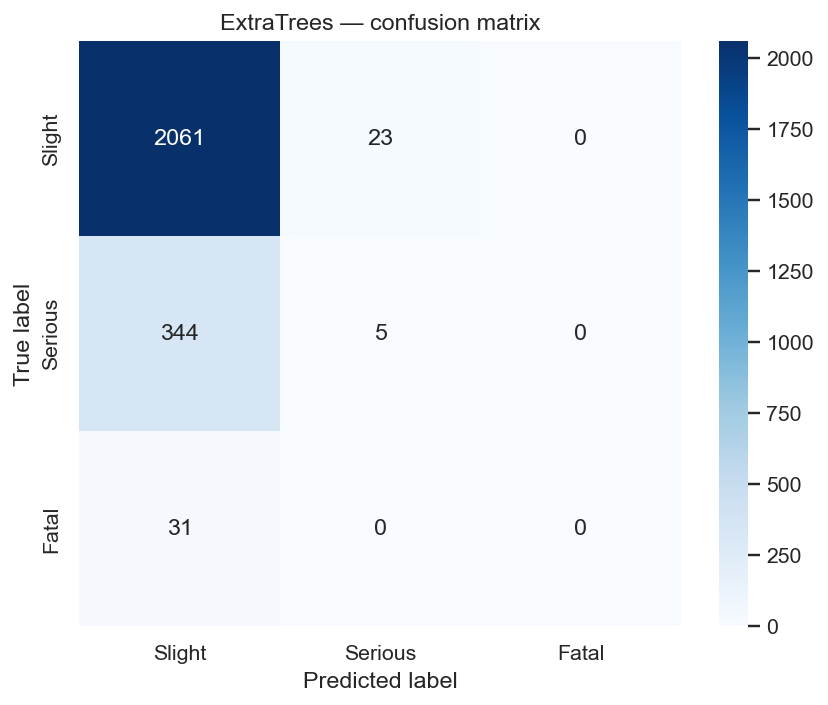

In [299]:
et = ExtraTreesClassifier(random_state=42, n_estimators=500, n_jobs=-1)
results.append(eval_model("ExtraTrees", et, X_train, y_train, X_test, y_test))


In [300]:
def eval_xgb_zero_index(name, model: XGBClassifier, X_tr, y_tr, X_te, y_te, show_cm=True):

    y_tr_min = int(y_tr.min())
    y_te_min = int(y_te.min())
    y_tr_0 = (y_tr - y_tr_min).astype(int)
    y_te_0 = (y_te - y_te_min).astype(int)

    model.fit(X_tr, y_tr_0)

    y_pred_0 = model.predict(X_te)
    y_pred   = (y_pred_0 + y_te_min).astype(int)

    f1_w = f1_score(y_te, y_pred, average="weighted")
    f1_m = f1_score(y_te, y_pred, average="macro")
    print(f"{name} — Weighted F1: {f1_w:.4f} | Macro F1: {f1_m:.4f}")

    if show_cm:
        plot_conf_mat(y_te, y_pred, title=f"{name} — confusion matrix")

    return {"Classifier": name, "F1_weighted": f1_w, "F1_macro": f1_m}

XGBoost — Weighted F1: 0.7343 | Macro F1: 0.3501


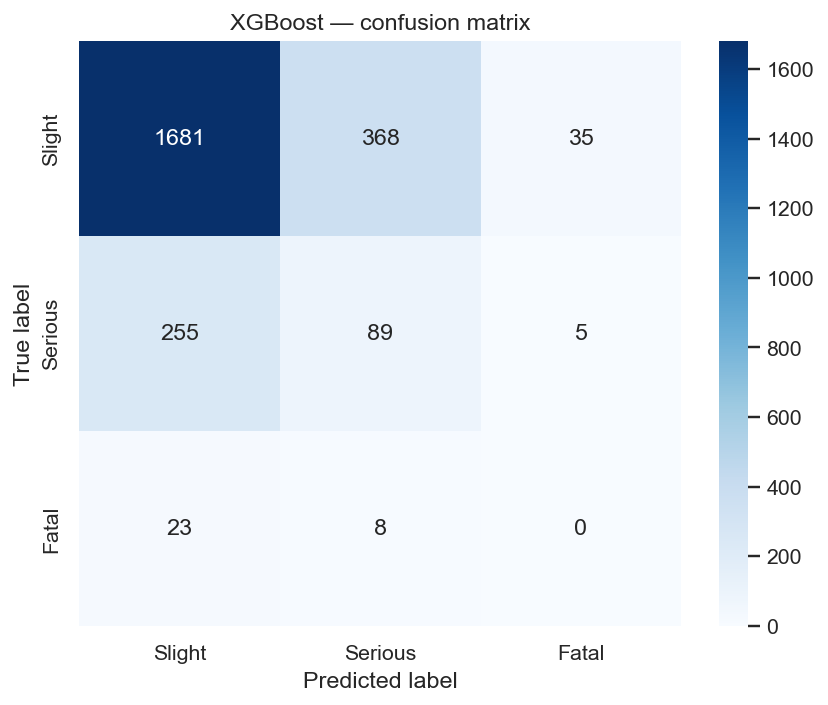

In [301]:
xgb = XGBClassifier(
    random_state=42,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)
results.append(eval_xgb_zero_index("XGBoost", xgb, X_train, y_train, X_test, y_test))

### XGBoost label fix
XGBoost requires classes to be 0-indexed. We’ll shift `y_train`/`y_test` to `{0,1,2}` for fitting, then map predictions back to `{1,2,3}` for metrics and the confusion matrix.


In [302]:
y_train_xgb = (y_train - 1).astype(int)
y_test_xgb  = (y_test  - 1).astype(int)

In [303]:
xgb = XGBClassifier(
    random_state=42,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [304]:
xgb.fit(X_train, y_train_xgb)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [305]:
y_pred_xgb_0 = xgb.predict(X_test)
y_pred_xgb   = (y_pred_xgb_0 + 1).astype(int)

In [306]:
f1_w = f1_score(y_test, y_pred_xgb, average="weighted")
f1_m = f1_score(y_test, y_pred_xgb, average="macro")
print(f"XGBoost — Weighted F1: {f1_w:.4f} | Macro F1: {f1_m:.4f}")

XGBoost — Weighted F1: 0.7343 | Macro F1: 0.3501


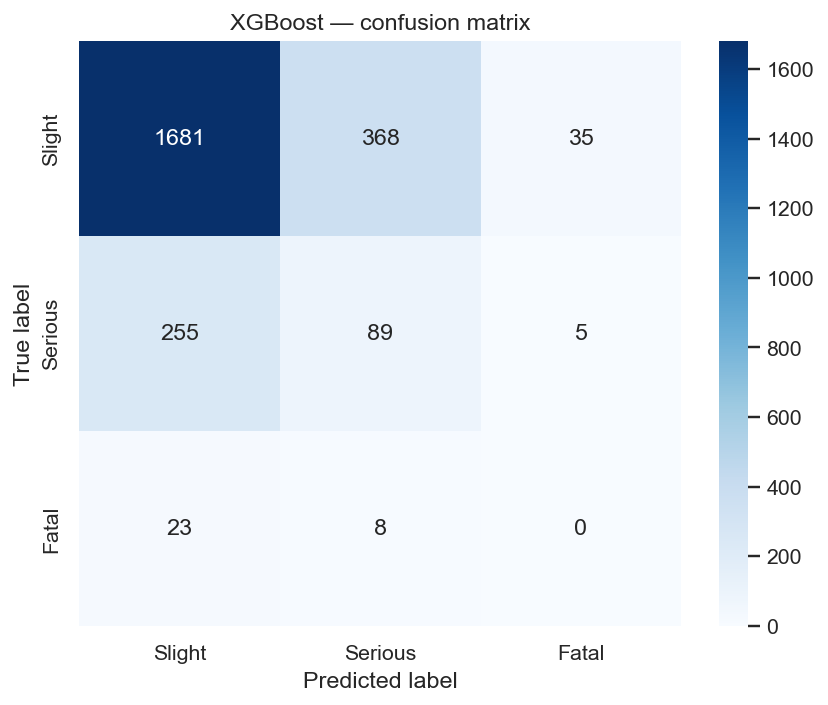

In [307]:
plot_conf_mat(y_test, y_pred_xgb, title="XGBoost — confusion matrix")

In [308]:
results.append({"Classifier": "XGBoost", "F1_weighted": f1_w, "F1_macro": f1_m})
f1_df = pd.DataFrame(results).sort_values("F1_weighted", ascending=False).reset_index(drop=True)
display(f1_df)

,Classifier,F1_weighted,F1_macro
0,Random Forest,0.778145,0.322134
1,ExtraTrees,0.775063,0.312824
2,XGBoost,0.734290,0.350078
3,XGBoost,0.734290,0.350078
4,Decision Tree,0.731576,0.334387


In [309]:
for name, model in [("Decision Tree", dt), ("Random Forest", rf), ("ExtraTrees", et)]:
    print(f"\n{name}")
    print(classification_report(y_test, model.predict(X_test), target_names=["Slight","Serious","Fatal"]))
print("\nXGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=["Slight","Serious","Fatal"]))



Decision Tree
              precision    recall  f1-score   support

      Slight       0.85      0.83      0.84      2084
     Serious       0.16      0.17      0.17       349
       Fatal       0.00      0.00      0.00        31

    accuracy                           0.72      2464
   macro avg       0.33      0.33      0.33      2464
weighted avg       0.74      0.72      0.73      2464


Random Forest
              precision    recall  f1-score   support

      Slight       0.85      0.98      0.91      2084
     Serious       0.24      0.03      0.06       349
       Fatal       0.00      0.00      0.00        31

    accuracy                           0.84      2464
   macro avg       0.36      0.34      0.32      2464
weighted avg       0.75      0.84      0.78      2464


ExtraTrees
              precision    recall  f1-score   support

      Slight       0.85      0.99      0.91      2084
     Serious       0.18      0.01      0.03       349
       Fatal       0.00      0.00

## 5. Hyperparameter tuning

We run 5-fold **Stratified** CV on the χ² top-16 features.

- **Random Forest**: tune n_estimators, criterion, max_features, and class_weight.
- **XGBoost**: tune depth/regularization and sampling; objective set to multi-class.

Notes
- RF’s `max_features='auto'` is deprecated; use `'sqrt'`.
- XGBoost requires class labels `0..K-1`; we shift labels for tuning and map predictions back.
- We report both **weighted F1** and **macro F1** on the held-out test set.


In [310]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV


In [311]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [312]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)


In [313]:
params_rf = {
    "n_estimators": [200, 400],
    "criterion": ["gini", "entropy"],
    "max_depth": [None],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", None],
}

In [314]:
gsearch_rf = GridSearchCV(
    estimator=rf,
    param_grid=params_rf,
    scoring="f1_weighted",
    n_jobs=-1,
    cv=cv,
    verbose=0,
)
gsearch_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', None], 'criterion': ['gini', 'entropy'], 'max_depth': [None], 'max_features': ['sqrt', 'log2'], ...}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [315]:
print("RF best params:", gsearch_rf.best_params_)
print("RF CV best weighted F1:", round(gsearch_rf.best_score_, 6))

RF best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
RF CV best weighted F1: 0.990592


RF test — weighted F1: 0.777022 | macro F1: 0.321498


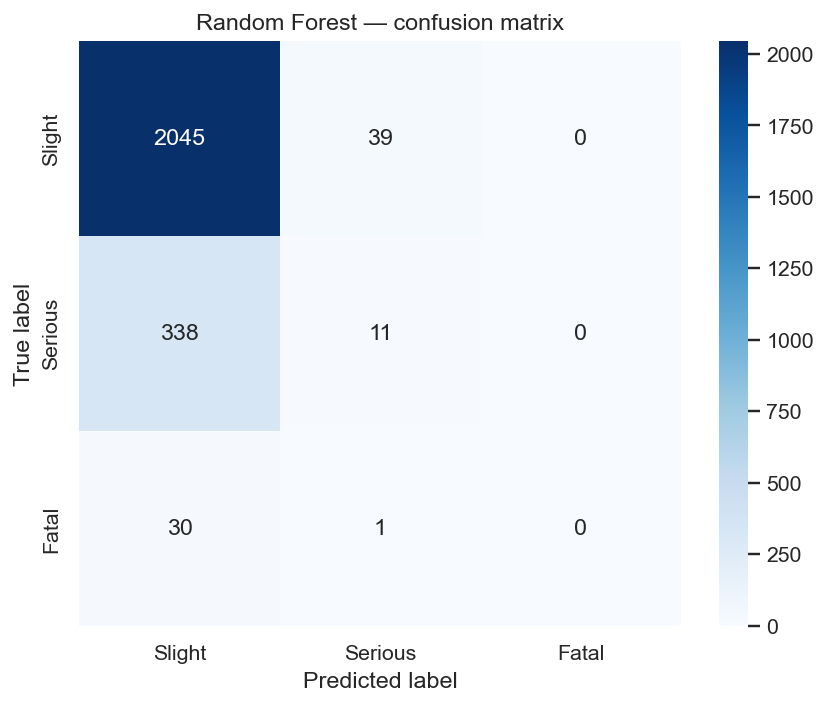

In [316]:
rf_best = gsearch_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
rf_f1_w = f1_score(y_test, y_pred_rf, average="weighted")
rf_f1_m = f1_score(y_test, y_pred_rf, average="macro")
print("RF test — weighted F1:", round(rf_f1_w, 6), "| macro F1:", round(rf_f1_m, 6))
plot_conf_mat(y_test, y_pred_rf, title="Random Forest — confusion matrix")

In [317]:
f1_dict_ht = {"Random Forest": rf_f1_w}

In [318]:
y_train_xgb = (y_train - 1).astype(int)
y_test_xgb  = (y_test  - 1).astype(int)

In [319]:
xgb = XGBClassifier(
    random_state=42,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    n_estimators=400,  # will be overridden if present in grid
    n_jobs=-1,
)

In [320]:
params_xgb = {
    "max_depth": [4, 5],
    "min_child_weight": [1, 5, 10],
    "gamma": [0.0, 0.5, 2.0],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
}

In [321]:

gsearch_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=params_xgb,
    scoring="f1_weighted",
    n_jobs=-1,
    cv=cv,
    verbose=0,
)
gsearch_xgb.fit(X_train, y_train_xgb)

,estimator,"XGBClassifier..._class=3, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.8], 'gamma': [0.0, 0.5, ...], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 5], ...}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [322]:
print("XGB best params:", gsearch_xgb.best_params_)
print("XGB CV best weighted F1:", round(gsearch_xgb.best_score_, 6))

XGB best params: {'colsample_bytree': 0.8, 'gamma': 0.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.6}
XGB CV best weighted F1: 0.887033


XGB test — weighted F1: 0.734929 | macro F1: 0.351315


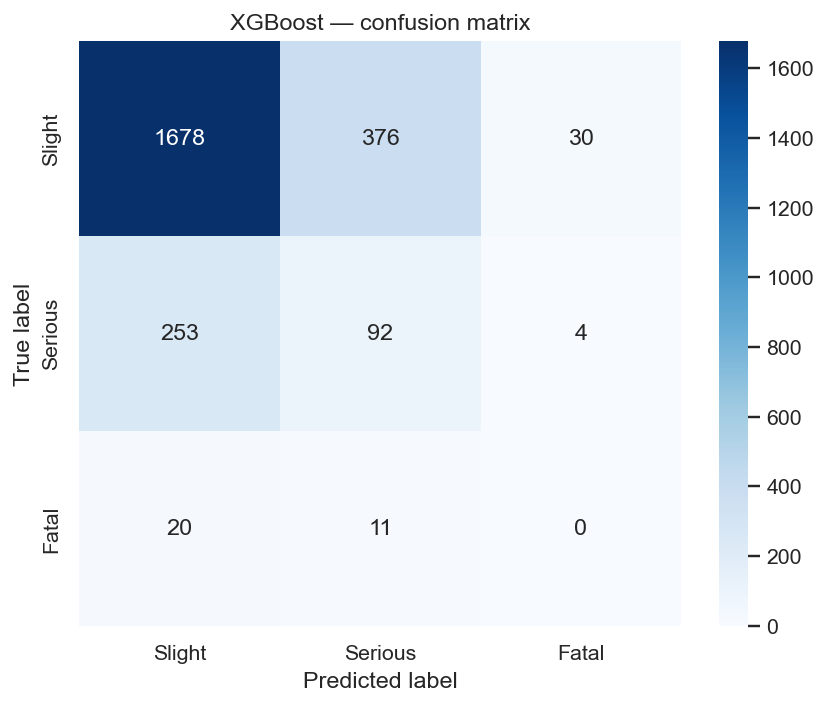

In [323]:
xgb_best = gsearch_xgb.best_estimator_
y_pred_xgb_0 = xgb_best.predict(X_test)
y_pred_xgb   = (y_pred_xgb_0 + 1).astype(int)
xgb_f1_w = f1_score(y_test, y_pred_xgb, average="weighted")
xgb_f1_m = f1_score(y_test, y_pred_xgb, average="macro")
print("XGB test — weighted F1:", round(xgb_f1_w, 6), "| macro F1:", round(xgb_f1_m, 6))
plot_conf_mat(y_test, y_pred_xgb, title="XGBoost — confusion matrix")

In [324]:
f1_dict_ht["XGBoost"] = xgb_f1_w

In [325]:
f1_df_ht = (
    pd.DataFrame([
        {"Classifier": "Random Forest", "F1-weighted": rf_f1_w, "F1-macro": rf_f1_m},
        {"Classifier": "XGBoost",       "F1-weighted": xgb_f1_w, "F1-macro": xgb_f1_m},
    ])
    .sort_values("F1-weighted", ascending=False)
    .reset_index(drop=True)
)
display(f1_df_ht)

,Classifier,F1-weighted,F1-macro
0,Random Forest,0.777022,0.321498
1,XGBoost,0.734929,0.351315


## 6) Save the final model + artifacts

We’ll ship **XGBoost** as the final model (lightweight at inference) and also persist:
- the label encoders for nominal features,
- the ordinal mappings,
- the exact feature list (top-16, in order),
- the class mapping (1=slight, 2=serious, 3=fatal).

That way, inference can rebuild the same preprocessing and column order.

## 7) Explainable AI (SHAP) for XGBoost

We’ll take a small sample from the test set, compute SHAP values with a `TreeExplainer`, and show a quick summary plot.


In [326]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, shap


In [327]:
os.makedirs("model", exist_ok=True)

In [328]:
ARTIFACTS = {
    "label_encoders": saved_dict,              
    "ordinal_maps": manual_encoder_dict,      
    "selected_cols": SELECTED_COLS,          
    "class_map": {"Slight Injury": 1, "Serious Injury": 2, "Fatal injury": 3},
    "notes": "SMOTE on train only; features are χ² top-16; labels 1/2/3; XGB fitted with 0-index labels internally.",
}

In [329]:
with open("model/preprocessing.pkl", "wb") as f:
    pickle.dump(ARTIFACTS, f)

xgb_best.save_model("model/model_xgb.bin")
print("Saved: model/model_xgb.bin  and  model/preprocessing.pkl")

Saved: model/model_xgb.bin  and  model/preprocessing.pkl


In [330]:
shap.initjs()

In [331]:

SAMPLE_SIZE = min(100, len(X_test))
X_test_sample = X_test.sample(SAMPLE_SIZE, random_state=42)

In [332]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sample)  


In [333]:
CLASS_NAMES = ["Slight Injury", "Serious Injury", "Fatal injury"]

In [334]:
def _trim_bias_cols(arr, n_features):
    return arr[:, :-1] if arr.shape[1] == n_features + 1 else arr

In [335]:
def normalize_shap(shap_vals, X):

    nfeat = X.shape[1]
    if isinstance(shap_vals, list):
        out = [_trim_bias_cols(sv, nfeat) for sv in shap_vals]
        return out, len(out)
    sv = np.asarray(shap_vals)
    if sv.ndim == 3:
        C = sv.shape[2]
        out = [_trim_bias_cols(sv[:, :, i], nfeat) for i in range(C)]
        return out, C
    if sv.ndim == 2:
        sv = _trim_bias_cols(sv, nfeat)
        return [sv], 1
    raise ValueError(f"Unexpected SHAP shape {sv.shape}")

shap_list, n_classes = normalize_shap(shap_values, X_test_sample)

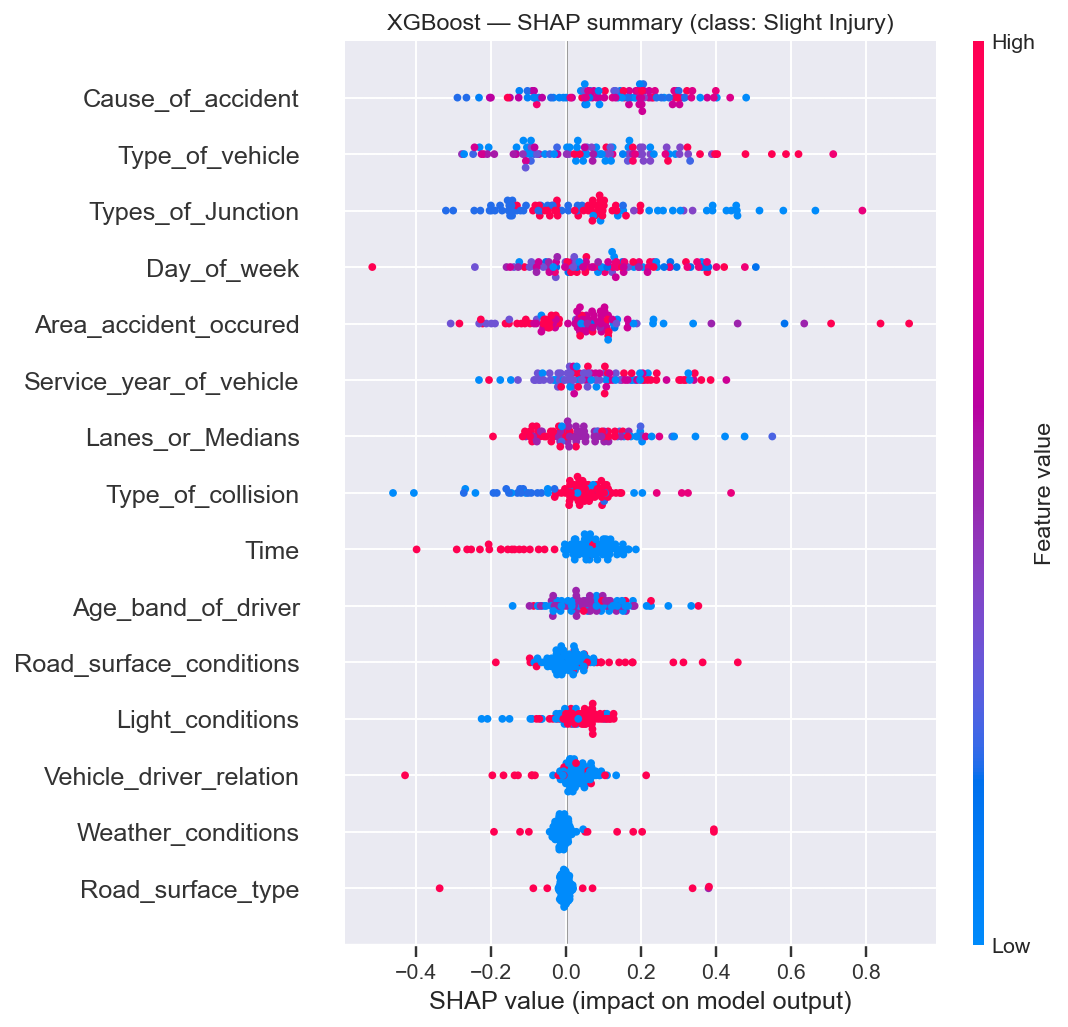

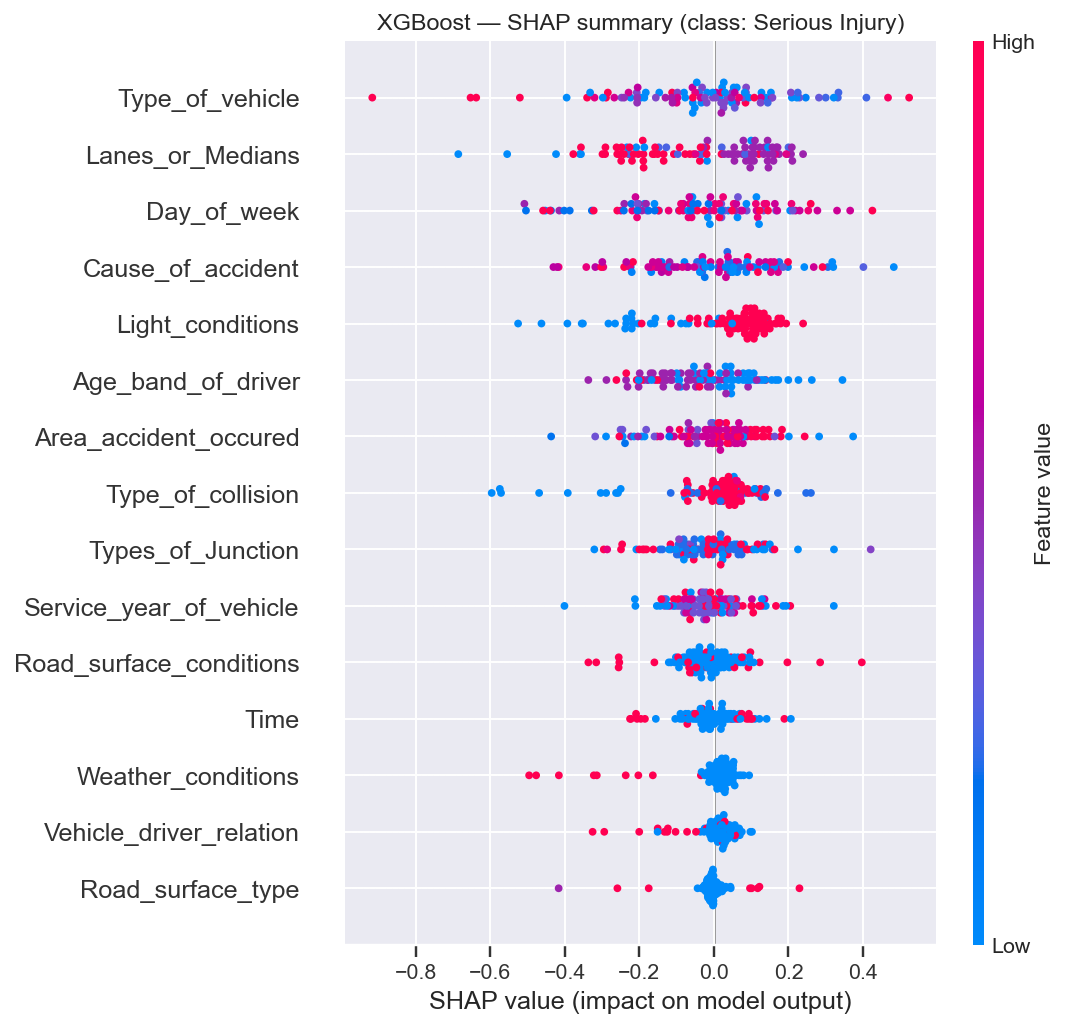

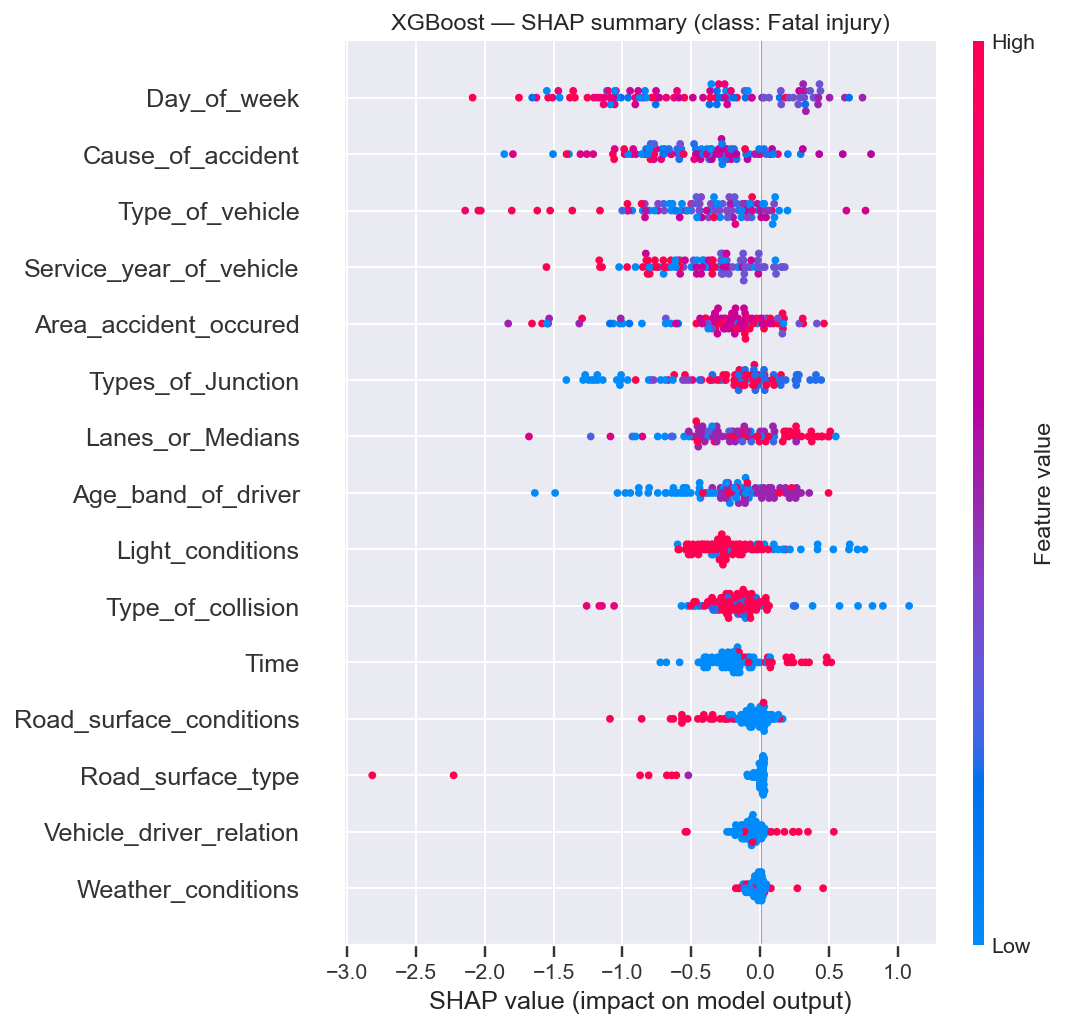

In [336]:
if n_classes > 1:
    for i, name in enumerate(CLASS_NAMES):
        plt.figure(figsize=(7,5))
        shap.summary_plot(shap_list[i], X_test_sample, show=False)
        plt.title(f"XGBoost — SHAP summary (class: {name})")
        plt.tight_layout(); plt.show()
else:
    plt.figure(figsize=(7,5))
    shap.summary_plot(shap_list[0], X_test_sample, show=False)
    plt.title("XGBoost — SHAP summary (all classes combined)")
    plt.tight_layout(); plt.show()

In [337]:
if n_classes > 1:
    stacked = np.stack(shap_list, axis=0)        # (C, N, F)
    mean_abs = np.abs(stacked).mean(axis=(0,1))  # -> (F,)
else:
    mean_abs = np.abs(shap_list[0]).mean(axis=0)

In [338]:
imp = pd.Series(mean_abs, index=X_test_sample.columns).sort_values(ascending=False)


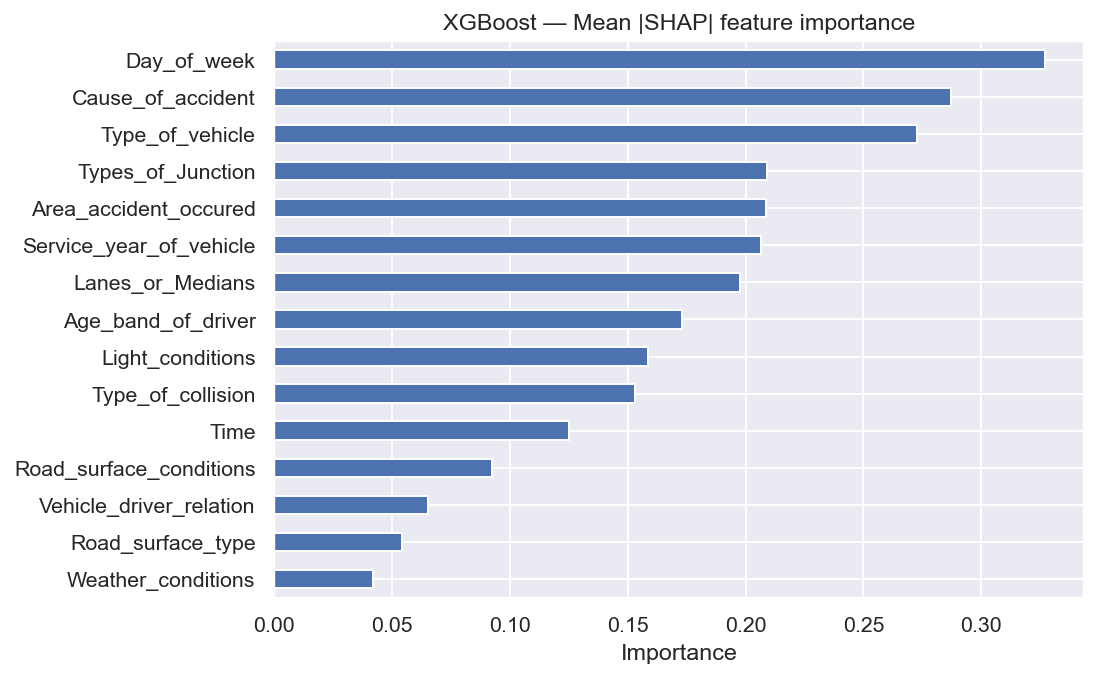

In [339]:
plt.figure(figsize=(8,5))
imp.head(16).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("XGBoost — Mean |SHAP| feature importance")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()


In [340]:
print("Top features by mean |SHAP|:")
display(imp.head(16).to_frame("mean|SHAP|"))

Top features by mean |SHAP|:


,mean|SHAP|
Day_of_week,0.327079
Cause_of_accident,0.287087
Type_of_vehicle,0.272838
Types_of_Junction,0.209280
Area_accident_occured,0.208688
Service_year_of_vehicle,0.206570
Lanes_or_Medians,0.197605
Age_band_of_driver,0.173043
Light_conditions,0.158444
Type_of_collision,0.153310


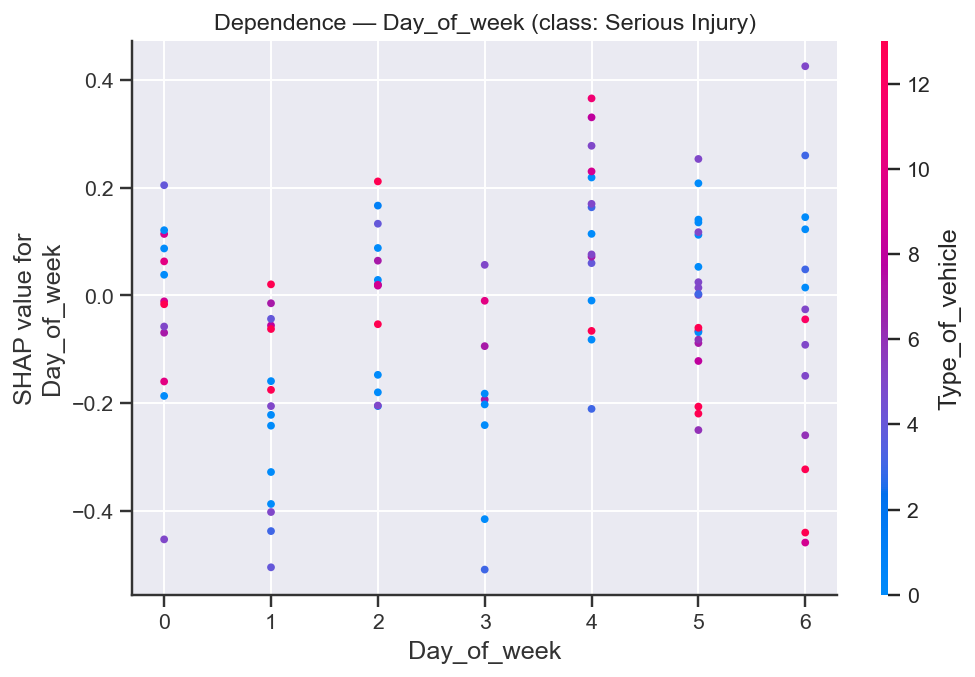

In [341]:
top_feat = imp.index[0]
cls_idx = 1 if n_classes > 1 else 0
shap.dependence_plot(top_feat, shap_list[cls_idx], X_test_sample, show=False)
plt.title(f"Dependence — {top_feat}" + (f" (class: {CLASS_NAMES[cls_idx]})" if n_classes>1 else ""))
plt.tight_layout(); plt.show()

In [342]:
with open("model/preprocessing.pkl", "rb") as f:
    ART = pickle.load(f)

In [343]:
xgb_loaded = XGBClassifier()
xgb_loaded.load_model("model/model_xgb.bin")

In [344]:
SELECTED_COLS_LOADED = ART["selected_cols"]

In [345]:
def predict_accident_severity(x_df: pd.DataFrame) -> pd.Series:

    X_infer = x_df[SELECTED_COLS_LOADED]
    pred_0idx = xgb_loaded.predict(X_infer)       # 0,1,2
    pred_1idx = (pred_0idx + 1).astype(int)       # 1,2,3
    inv = {1: "Slight Injury", 2: "Serious Injury", 3: "Fatal injury"}
    return pd.Series([inv[i] for i in pred_1idx], index=X_infer.index)